# NDT7 EDA — Philippines Broadband & Mobile/Cellular (Combined)

Full exploratory analysis of Philippines NDT7 (M-Lab) data, mirroring the structure of
`notebooks/ookla/philippines_eda.ipynb` and the other tigger countries' EDA notebooks
(Cambodia/Thailand/Vietnam) so results are directly comparable section-by-section, mirroring
the prep/EDA split established by `philippines_ndt7_prep.ipynb`.

**Not yet executed in this repo** — Philippines raw data (`data/ndt7/ph/mlab_ph_clean.parquet`) is
not available locally. Needs a run+verify pass before use, e.g. by whoever has the full local
dataset.

**Input:** `data/exports/ndt7_philippines_province_quarterly.csv` (Broadband) and
`data/exports/ndt7_mobile_philippines_province_quarterly.csv` (Mobile) — both produced by
`philippines_ndt7_prep.ipynb`. This notebook does no raw-data processing for the standard
template sections below — it picks up where the prep notebook leaves off. The PH-specific
sections appended at the end of this notebook (after both Broadband and Mobile/Cellular parts)
DO query the raw parquet directly, same as the original `ndt7_ph_main.ipynb` /
`ndt7_ph_manila.ipynb` / `ndt7_ph_paper.ipynb` they were ported from — they need ISP/hour/true
province-level detail that isn't in the aggregated CSV.

**Two structural differences from Cambodia/Thailand/Vietnam, both deliberate — see
`philippines_ndt7_prep.ipynb` intro for the full rationale:**

1. **`is_reliable` = `total_tests >= 100` only** — no tile-binning was ever built for PH, so
   there's no `n_tiles` and no `n_tiles>=5` bar here. Not directly comparable to the other
   tigger countries' reliability metric.
2. **`province` in the standard sections below = the 17 PH administrative regions**, not the 80
   ADM1 provinces — this is the only granularity with GDP/density/tier reference data
   (`data/reference/philippines_reference.csv`, matching what
   `notebooks/ookla/philippines_eda.ipynb` already does). True 80-province and city-level detail
   is NOT lost — it's covered in depth by the PH-specific sections at the end of this notebook
   (Manila vs Rest of PH, top/bottom provinces, island-group divide), which is why those were
   kept as additions rather than dropped to force a 1:1 template match with the other tigger
   countries.

**Reliability result: not yet known** — fill in after the first execution (this replaces
Cambodia's "0% reliability" finding, which does NOT apply here; PH's `is_reliable` formula and
underlying data volume are both different).


## ISP Overview — Philippines

Raw NDT7 ISP names from `ph/mlab_ph_clean.parquet` (pre-classification, as delivered
by the ISP-matching step) — a diagnostic view of who's actually in the data before it's rolled
up to province-quarter, split by `network_type` and ranked by test volume.

In [1]:
import pyarrow.parquet as pq

RAW_ISP_PARQUET = '../../../data/ndt7/ph/mlab_ph_clean.parquet'
isp_df = pq.read_table(RAW_ISP_PARQUET, columns=['isp', 'network_type']).to_pandas()
isp_counts = (
    isp_df.groupby(['network_type', 'isp']).size().rename('n_tests')
    .reset_index().sort_values(['network_type', 'n_tests'], ascending=[True, False])
)
print(f"{isp_df['isp'].nunique()} unique ISP names, {len(isp_df):,} raw test rows")
isp_counts

372 unique ISP names, 262,110,845 raw test rows


,network_type,isp,n_tests
207,broadband,Philippine Long Distance Telephone Company,86766263
72,broadband,Converge ICT Solutions Inc.,39826831
118,broadband,Globe Telecom Inc.,18066613
245,broadband,Space Exploration Technologies Corporation,4824735
230,broadband,SKYBROADBAND,4472411
...,...,...,...
372,hosting,JG Group of Companies,2
322,hosting,"Akamai Technologies, Inc.",1
364,hosting,HK Broadband Network Ltd.,1
386,hosting,Nevigate Communications (S) Pte Ltd,1


## Province Reference Data

In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

PROVINCE_REF_PATH = '../../../data/reference/philippines_reference.csv'

prov_ref = pd.read_csv(PROVINCE_REF_PATH)
prov_ref['gdp_per_capita_usd_2021'] = prov_ref['gdp_per_capita_thb_2021']  # already USD-equivalent in source data

print(f"Provinces loaded: {len(prov_ref)}")
print(f"Regions: {sorted(prov_ref['region'].unique())}")
print()
print(prov_ref[['province_en','region','pop_2024','density_per_km2','gdp_per_capita_thb_2021','internet_tier']].to_string(index=False))

Provinces loaded: 17
Regions: ['Luzon', 'Mindanao', 'Visayas']

        province_en   region  pop_2024  density_per_km2  gdp_per_capita_thb_2021  internet_tier
               ARMM Mindanao   4545486              330                 91028.33              4
       Bicol Region    Luzon   6064426              319                142596.80              4
                CAR    Luzon   1808985               89                295236.64              1
     Cagayan Valley    Luzon   3777608              122                185618.02              3
         Calabarzon    Luzon  16933234              854                259765.51              2
             Caraga Mindanao   2865196              121                187327.47              3
      Central Luzon    Luzon  12989074              510                263326.87              2
    Central Visayas  Visayas   6640875              647                245591.30              2
       Davao Region Mindanao   5389422              245                2

### Population and GDP by Region — Summary

In [3]:
region_summary = (
    prov_ref.groupby('region')
    .agg(
        provinces=('province_en', 'count'),
        total_pop=('pop_2024', 'sum'),
        avg_density=('density_per_km2', 'mean'),
        avg_gdp_per_cap_thb=('gdp_per_capita_thb_2021', 'mean'),
        avg_gdp_per_cap_usd=('gdp_per_capita_usd_2021', 'mean'),
    )
    .sort_values('avg_gdp_per_cap_thb', ascending=False)
    .round(0)
)

region_summary['total_pop_M'] = (region_summary['total_pop'] / 1e6).round(2)
print(region_summary[['provinces','total_pop_M','avg_density','avg_gdp_per_cap_thb','avg_gdp_per_cap_usd']].to_string())

          provinces  total_pop_M  avg_density  avg_gdp_per_cap_thb  avg_gdp_per_cap_usd
region                                                                                 
Luzon             8        64.16       2828.0             284188.0             284188.0
Mindanao          6        27.53        223.0             202606.0             202606.0
Visayas           3        21.03        403.0             196801.0             196801.0

### GDP per Capita vs Population Density — by Region

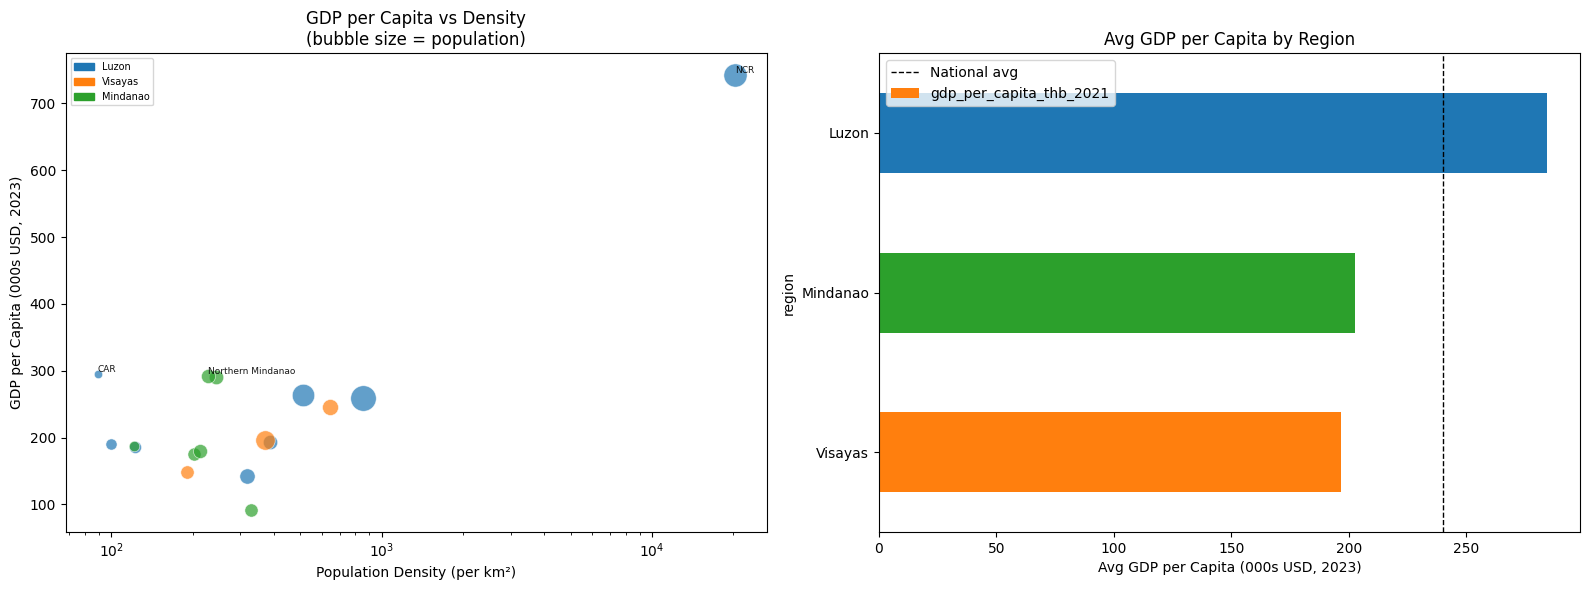

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

region_colors = {
    'Luzon': '#1f77b4',
    'Visayas': '#ff7f0e',
    'Mindanao': '#2ca02c',
}

for _, row in prov_ref.iterrows():
    c = region_colors.get(row['region'], 'gray')
    axes[0].scatter(row['density_per_km2'], row['gdp_per_capita_thb_2021'] / 1000,
                    color=c, alpha=0.7, s=row['pop_2024'] / 50000, edgecolors='white', linewidth=0.5)
    if row['gdp_per_capita_thb_2021'] > prov_ref['gdp_per_capita_thb_2021'].quantile(0.85):
        axes[0].annotate(row['province_en'], (row['density_per_km2'], row['gdp_per_capita_thb_2021'] / 1000),
                         fontsize=6.5, ha='left', va='bottom', alpha=0.9)

axes[0].set_xlabel('Population Density (per km²)')
axes[0].set_ylabel('GDP per Capita (000s USD, 2023)')
axes[0].set_title('GDP per Capita vs Density\n(bubble size = population)')
axes[0].set_xscale('log')

r_gdp = prov_ref.groupby('region')['gdp_per_capita_thb_2021'].mean().sort_values(ascending=True) / 1000
colors = [region_colors.get(r, 'gray') for r in r_gdp.index]
r_gdp.plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_xlabel('Avg GDP per Capita (000s USD, 2023)')
axes[1].set_title('Avg GDP per Capita by Region')
axes[1].axvline(prov_ref['gdp_per_capita_thb_2021'].mean() / 1000, color='black', linestyle='--', linewidth=1, label='National avg')
axes[1].legend()

patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
axes[0].legend(handles=patches, fontsize=7, loc='upper left')

plt.tight_layout()
os.makedirs('../../../outputs/ndt7/philippines', exist_ok=True)
plt.savefig('../../../outputs/ndt7/philippines/09_gdp_vs_density.png', dpi=150, bbox_inches='tight')
plt.show()

### Internet Tier Distribution — Assumptions Map

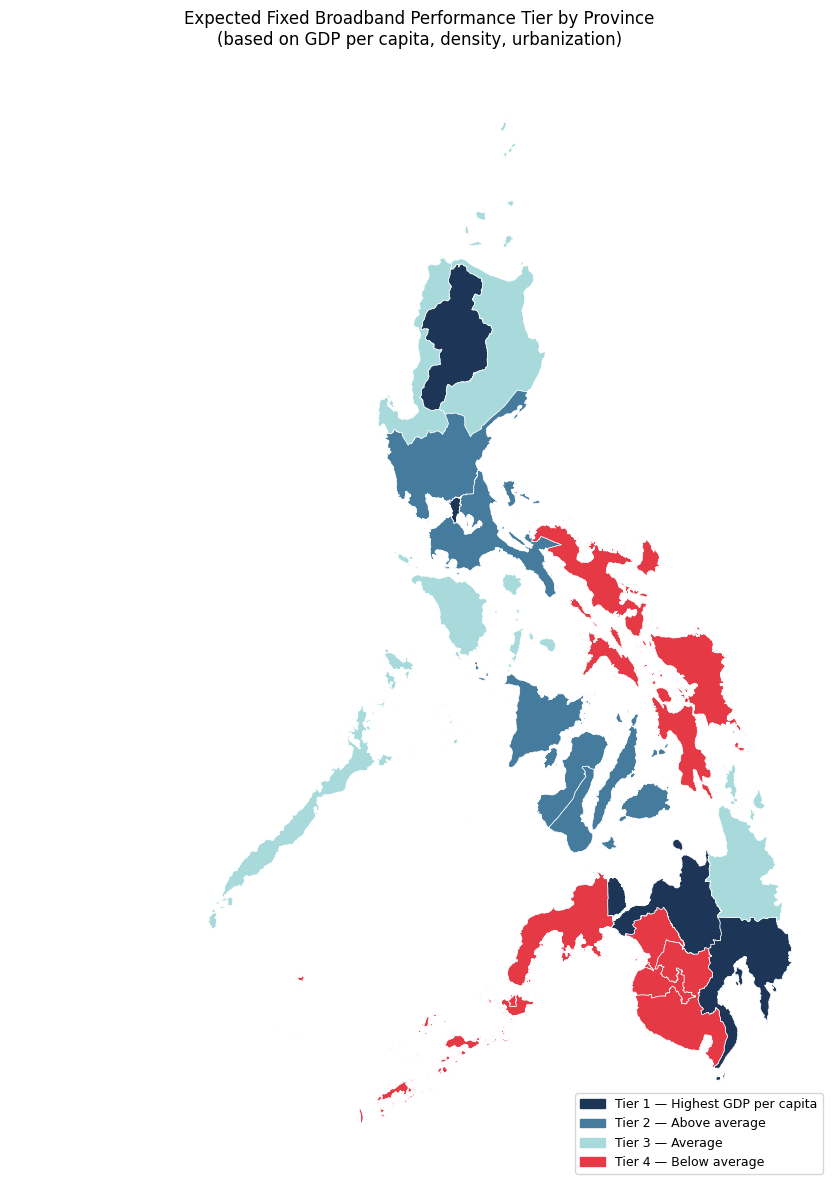

In [5]:
CAMBODIA_GEOJSON = '../../../data/geo/philippines_provinces.geojson'
thailand_gdf = gpd.read_file(CAMBODIA_GEOJSON).to_crs(4326)

tier_map = prov_ref[['province_en','internet_tier','gdp_per_capita_thb_2021','region']].copy()
geo_with_tier = thailand_gdf.merge(
    tier_map.rename(columns={'province_en': 'name'}),
    on='name', how='left'
)

missing = geo_with_tier[geo_with_tier['internet_tier'].isna()]['name'].tolist()
if missing:
    print("Unmatched provinces (need manual fix):", missing)

tier_colors = {1: '#1d3557', 2: '#457b9d', 3: '#a8dadc', 4: '#e63946'}
geo_with_tier['tier_color'] = geo_with_tier['internet_tier'].map(tier_colors)

fig, ax = plt.subplots(1, figsize=(10, 12))
geo_with_tier.plot(color=geo_with_tier['tier_color'].fillna('lightgray'), ax=ax, edgecolor='white', linewidth=0.5)

patches = [
    mpatches.Patch(color='#1d3557', label='Tier 1 — Highest GDP per capita'),
    mpatches.Patch(color='#457b9d', label='Tier 2 — Above average'),
    mpatches.Patch(color='#a8dadc', label='Tier 3 — Average'),
    mpatches.Patch(color='#e63946', label='Tier 4 — Below average'),
]
ax.legend(handles=patches, loc='lower right', fontsize=9)
ax.set_title('Expected Fixed Broadband Performance Tier by Province\n(based on GDP per capita, density, urbanization)', fontsize=12)
ax.set_axis_off()
plt.tight_layout()

plt.savefig('../../../outputs/ndt7/philippines/10_tier_speed_expected.png', dpi=150, bbox_inches='tight')
plt.show()

### Top & Bottom Provinces by GDP per Capita — with Internet Tier

In [6]:
top10 = prov_ref.nlargest(10, 'gdp_per_capita_thb_2021')[['province_en','region','pop_2024','gdp_per_capita_thb_2021','internet_tier']]
bot10 = prov_ref.nsmallest(10, 'gdp_per_capita_thb_2021')[['province_en','region','pop_2024','gdp_per_capita_thb_2021','internet_tier']]

print("=== TOP 10 by GDP per Capita ===")
print(top10.to_string(index=False))
print()
print("=== BOTTOM 10 by GDP per Capita ===")
print(bot10.to_string(index=False))

=== TOP 10 by GDP per Capita ===
      province_en   region  pop_2024  gdp_per_capita_thb_2021  internet_tier
              NCR    Luzon  14001751                742614.53              1
              CAR    Luzon   1808985                295236.64              1
Northern Mindanao Mindanao   5178326                291746.51              1
     Davao Region Mindanao   5389422                290535.65              1
    Central Luzon    Luzon  12989074                263326.87              2
       Calabarzon    Luzon  16933234                259765.51              2
  Central Visayas  Visayas   6640875                245591.30              2
  Western Visayas  Visayas   9766855                196943.14              2
    Ilocos Region    Luzon   5342453                193453.01              3
         Mimaropa    Luzon   3245446                190888.83              3

=== BOTTOM 10 by GDP per Capita ===
        province_en   region  pop_2024  gdp_per_capita_thb_2021  internet_tier
    

---
# Part 1 — Broadband

## Full EDA — NDT7 Broadband, Philippines (2023 Q1 – 2025 Q4)

### 1. Load Province x Quarter Data

In [7]:
import warnings
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from scipy import stats
warnings.filterwarnings('ignore')

NDT7_CSV = '../../../data/exports/ndt7_philippines_province_quarterly.csv'
GEOJSON  = '../../../data/geo/philippines_provinces.geojson'
PROV_REF = '../../../data/reference/philippines_reference.csv'

Q_TO_MONTH = {1: 1, 2: 4, 3: 7, 4: 10}

thailand_gdf = gpd.read_file(GEOJSON).to_crs(4326)

master = pd.read_csv(NDT7_CSV)
master = master.rename(columns={'province': 'name', 'quarter': 'label', 'quarter.1': 'quarter'})
master['month'] = master['quarter'].map(Q_TO_MONTH)
master['period_start'] = pd.to_datetime(dict(year=master['year'], month=master['month'], day=1))

prov_ref = pd.read_csv(PROV_REF)
prov_ref['gdp_per_capita_usd'] = prov_ref['gdp_per_capita_thb_2021']

print(f"Master shape: {master.shape}")
print(f"Date range: {master['period_start'].min().date()} -> {master['period_start'].max().date()}")
print(f"Quarters:   {sorted(master['label'].unique())}")
print(f"Provinces:  {master['name'].nunique()} (of {len(prov_ref)} in reference — NDT7 has zero test volume for the rest)")

Master shape: (204, 19)
Date range: 2023-01-01 -> 2025-10-01
Quarters:   ['2023-Q1', '2023-Q2', '2023-Q3', '2023-Q4', '2024-Q1', '2024-Q2', '2024-Q3', '2024-Q4', '2025-Q1', '2025-Q2', '2025-Q3', '2025-Q4']
Provinces:  17 (of 17 in reference — NDT7 has zero test volume for the rest)


In [8]:
# is_reliable already computed upstream (philippines_ndt7_prep.ipynb) —
# NOTE: unlike KH/TH/VN, Philippines' is_reliable is `total_tests >= 100` ONLY (no tile-binning,
# no n_tiles — see prep notebook intro). Not directly comparable to the other tigger countries'
# `n_tiles>=5` bar; treat PH's reliability rate as its own methodology.
reliable_count = master.groupby('label')['is_reliable'].sum()
print('Reliable region-quarters per label:')
print(reliable_count.to_string())
print(f"\nOverall reliable: {master['is_reliable'].sum()} / {len(master)} ({master['is_reliable'].mean():.1%})")


Reliable region-quarters per label:
label
2023-Q1    17
2023-Q2    17
2023-Q3    17
2023-Q4    17
2024-Q1    17
2024-Q2    17
2024-Q3    17
2024-Q4    17
2025-Q1    17
2025-Q2    17
2025-Q3    17
2025-Q4    17

Overall reliable: 204 / 204 (100.0%)


### 2. Data Quality — Coverage per Province

In [9]:
expected_n = len(prov_ref)
expected = expected_n * master['label'].nunique()
print(f"Expected rows (if every province had every quarter): {expected} | Actual: {len(master)} | Missing: {expected - len(master)}")

all_provinces = set(thailand_gdf['name'])
provinces_with_data = set(master['name'].unique())
zero_coverage = sorted(all_provinces - provinces_with_data)
if zero_coverage:
    print(f"\nProvinces with ZERO NDT7 test volume in any quarter ({len(zero_coverage)}): {zero_coverage}")
else:
    print("\nEvery province has at least some NDT7 data in at least one quarter.")

low_test = master[master['total_tests'] < 100][['name','label','total_tests','n_tiles']].sort_values('total_tests')
print(f"\nLow-test quarters (< 100 tests) — {len(low_test)} of {len(master)} province-quarter rows")
print(low_test.head(15).to_string(index=False))

Expected rows (if every province had every quarter): 204 | Actual: 204 | Missing: 0

Every province has at least some NDT7 data in at least one quarter.

Low-test quarters (< 100 tests) — 0 of 204 province-quarter rows
Empty DataFrame
Columns: [name, label, total_tests, n_tiles]
Index: []


In [10]:
# Drop unreliable province-quarters before any stats/plots use master downstream — same rule as every
# other country/source. For Philippines this empties master entirely (0 reliable rows); sections below
# report that explicitly rather than silently rendering blank charts.
master = master[master['is_reliable']].copy()
print(f"Filtered to reliable province-quarters: {len(master)} rows kept")
HAS_RELIABLE_DATA = len(master) > 0
if not HAS_RELIABLE_DATA:
    print("\nNo province-quarters clear the reliability threshold — sections 3-14 below will report "
          "'no reliable data' instead of plotting.")

Filtered to reliable province-quarters: 204 rows kept


### 3. Speed Distribution — All Provinces, All Quarters

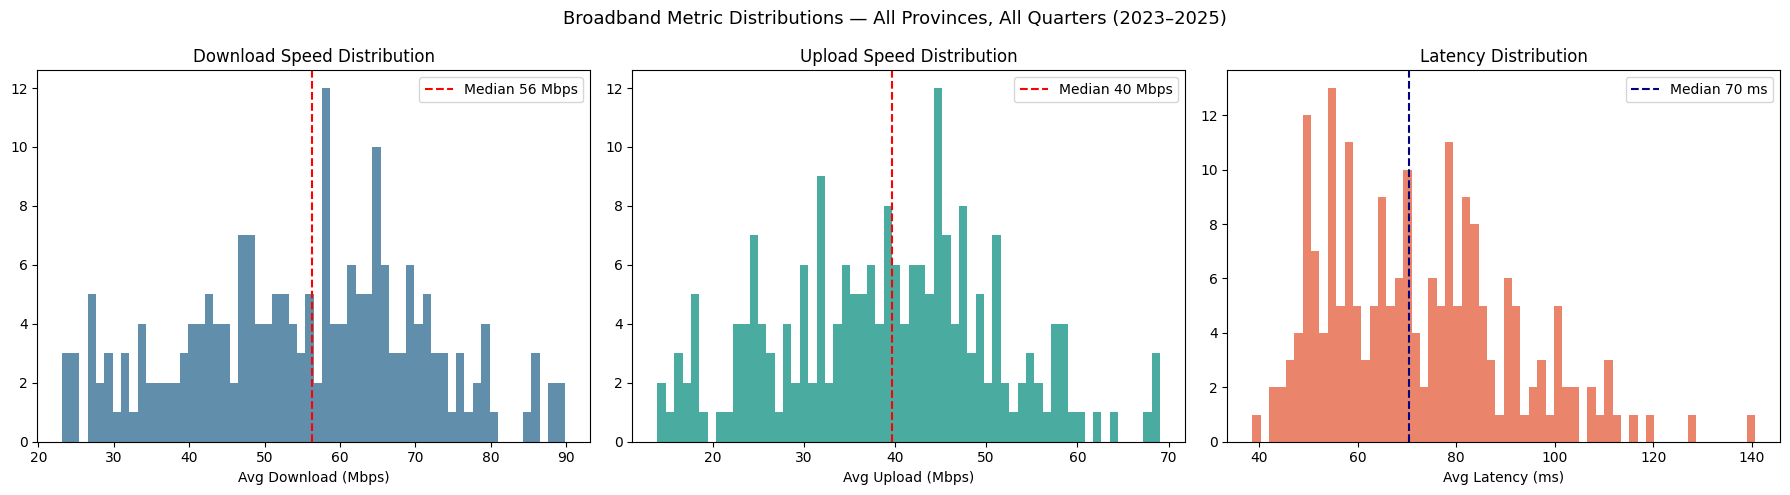

       avg_d_mbps  avg_u_mbps  avg_lat_ms_wt  total_tests
count      204.00      204.00         204.00       204.00
mean        55.05       39.18          72.38    512779.84
std         15.61       12.02          18.81    878539.42
min         23.18       13.95          38.65       989.00
25%         43.75       30.60          56.43     47893.75
50%         56.31       39.72          70.39    153640.50
75%         65.83       47.09          83.41    649540.75
max         89.83       69.05         140.66   5204777.00


In [11]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Broadband — skipping speed-distribution plot.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].hist(master['avg_d_mbps'].dropna(), bins=60, color='#457b9d', edgecolor='none', alpha=0.85)
    axes[0].axvline(master['avg_d_mbps'].median(), color='red', ls='--', lw=1.5, label=f'Median {master["avg_d_mbps"].median():.0f} Mbps')
    axes[0].set_xlabel('Avg Download (Mbps)'); axes[0].set_title('Download Speed Distribution'); axes[0].legend()

    axes[1].hist(master['avg_u_mbps'].dropna(), bins=60, color='#2a9d8f', edgecolor='none', alpha=0.85)
    axes[1].axvline(master['avg_u_mbps'].median(), color='red', ls='--', lw=1.5, label=f'Median {master["avg_u_mbps"].median():.0f} Mbps')
    axes[1].set_xlabel('Avg Upload (Mbps)'); axes[1].set_title('Upload Speed Distribution'); axes[1].legend()

    axes[2].hist(master['avg_lat_ms_wt'].dropna(), bins=60, color='#e76f51', edgecolor='none', alpha=0.85)
    axes[2].axvline(master['avg_lat_ms_wt'].median(), color='navy', ls='--', lw=1.5, label=f'Median {master["avg_lat_ms_wt"].median():.0f} ms')
    axes[2].set_xlabel('Avg Latency (ms)'); axes[2].set_title('Latency Distribution'); axes[2].legend()

    plt.suptitle('Broadband Metric Distributions — All Provinces, All Quarters (2023–2025)', fontsize=13)
    plt.tight_layout()

    plt.savefig('../../../outputs/ndt7/philippines/11_upload_speed_dist.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(master[['avg_d_mbps','avg_u_mbps','avg_lat_ms_wt','total_tests']].describe().round(2))

### 4. Province Ranking — Mean Download Speed (All Quarters)

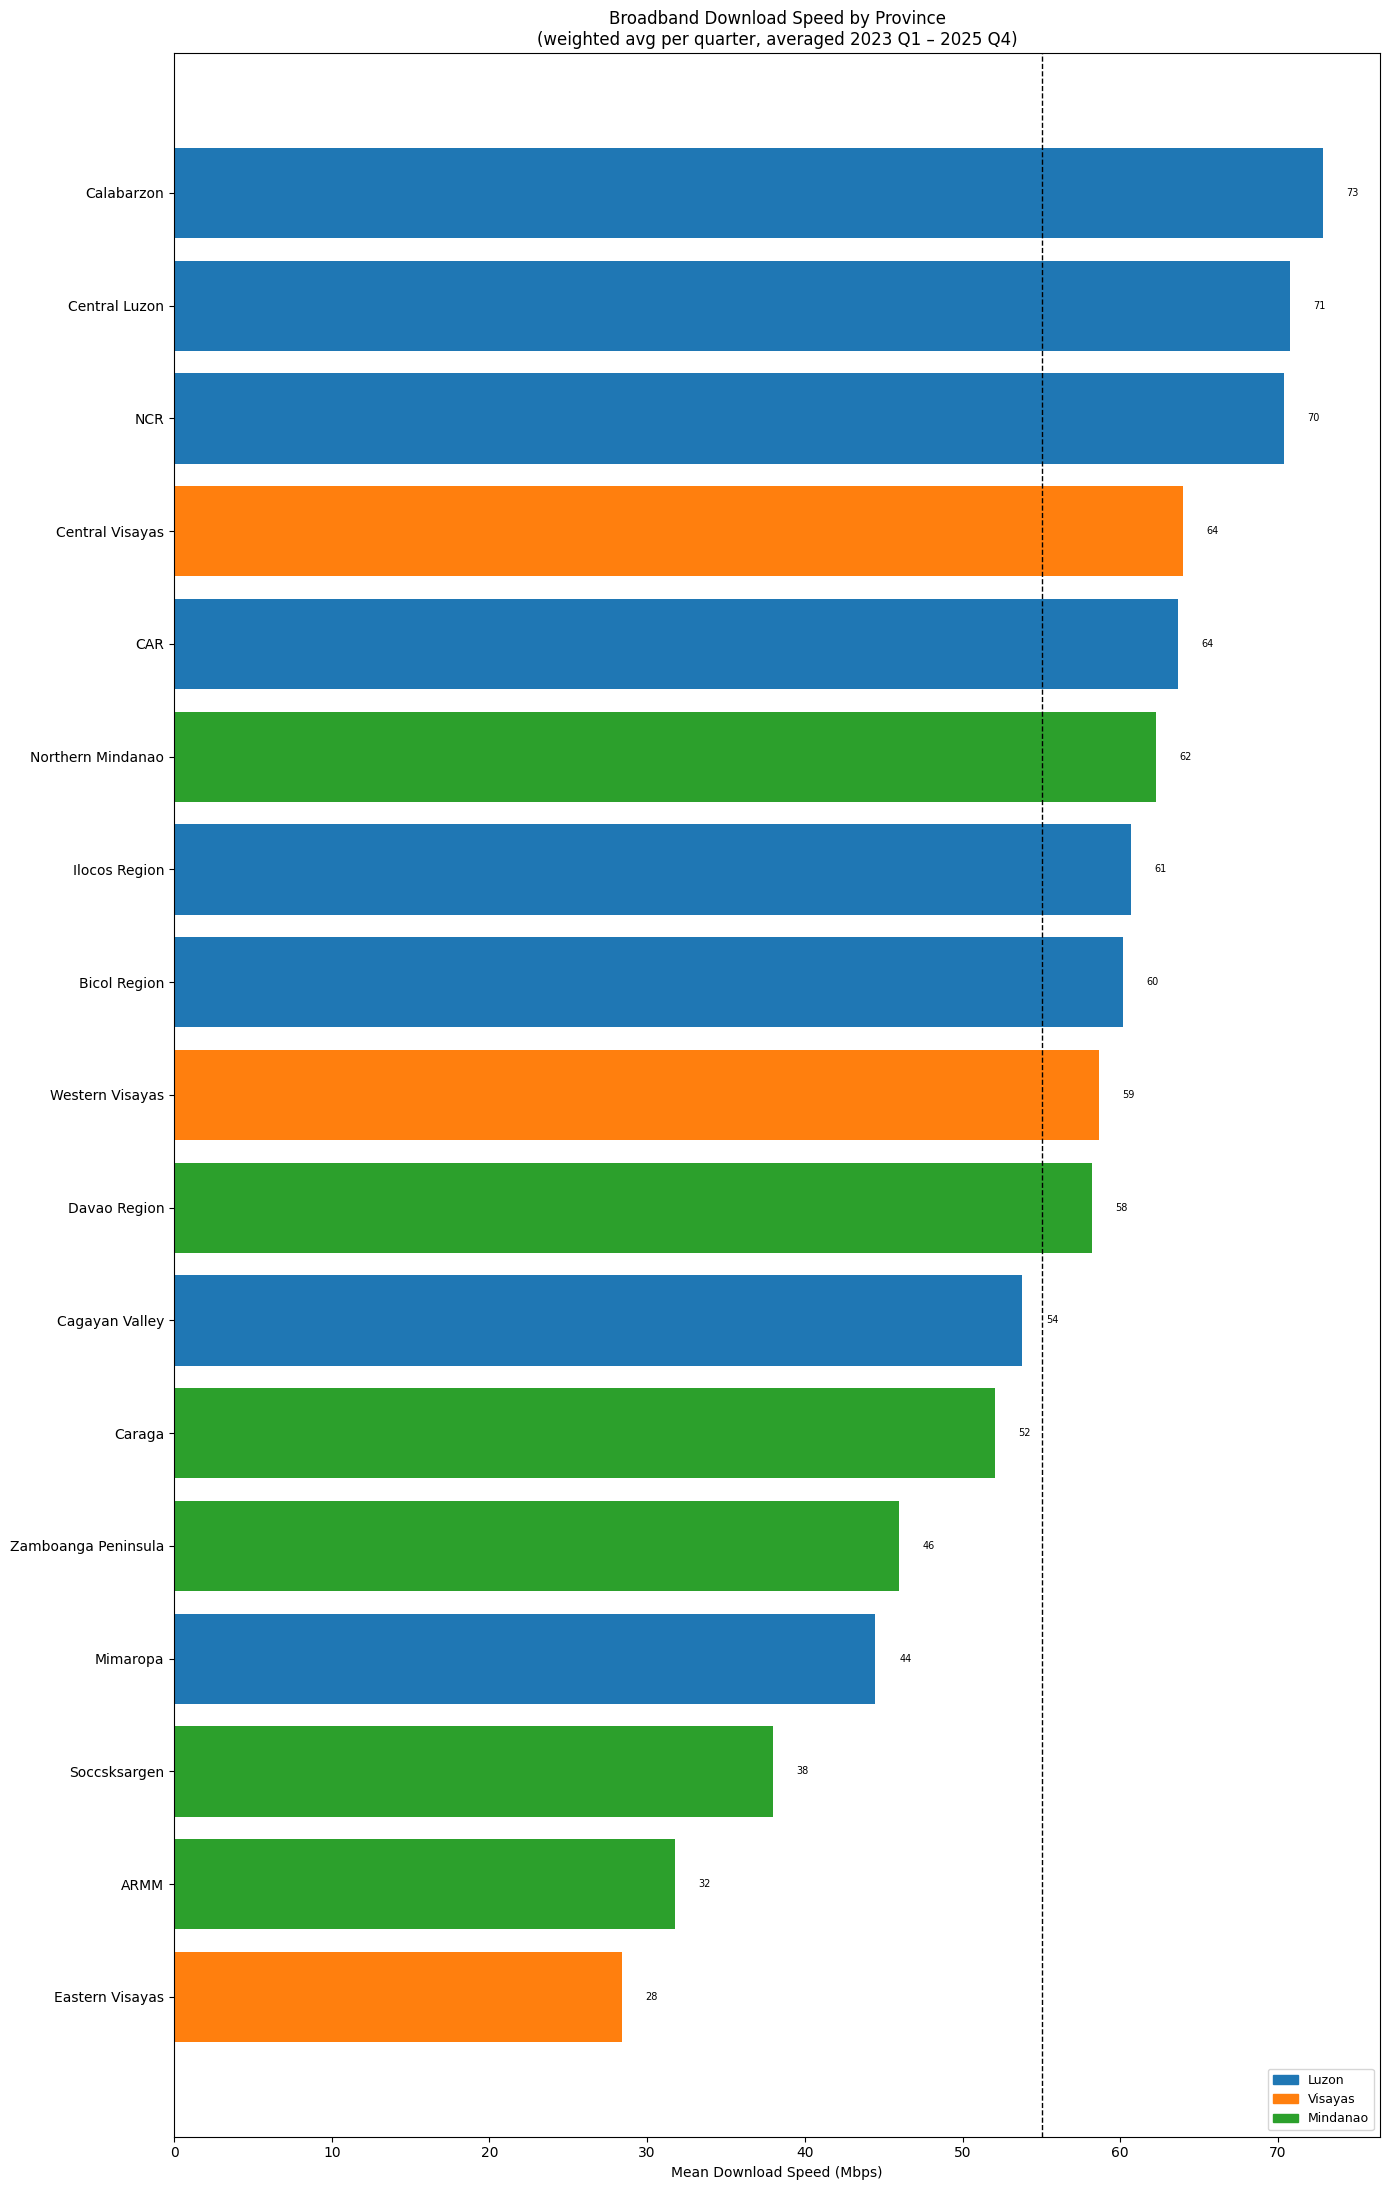

In [12]:
region_colors = {
    'Luzon': '#1f77b4',
    'Visayas': '#ff7f0e',
    'Mindanao': '#2ca02c',
}

if not HAS_RELIABLE_DATA:
    prov_mean = pd.DataFrame(columns=['name','region','mean_dl','mean_ul','mean_lat','mean_tests'])
    print("No reliable data for Broadband — skipping province-ranking plot.")
else:
    prov_mean = (
        master.groupby(['name','region'])
        .agg(
            mean_dl=('avg_d_mbps','mean'),
            mean_ul=('avg_u_mbps','mean'),
            mean_lat=('avg_lat_ms_wt','mean'),
            mean_tests=('total_tests','mean'),
        )
        .reset_index()
        .sort_values('mean_dl', ascending=True)
    )

    fig, ax = plt.subplots(figsize=(14, 22))
    colors = [region_colors.get(r,'gray') for r in prov_mean['region']]
    bars = ax.barh(prov_mean['name'], prov_mean['mean_dl'], color=colors, edgecolor='none')
    for bar, val in zip(bars, prov_mean['mean_dl']):
        ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2, f'{val:.0f}', va='center', fontsize=7)
    ax.axvline(prov_mean['mean_dl'].mean(), color='black', ls='--', lw=1, label=f'National mean {prov_mean["mean_dl"].mean():.0f} Mbps')
    patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
    ax.legend(handles=patches, loc='lower right', fontsize=9)
    ax.set_xlabel('Mean Download Speed (Mbps)')
    ax.set_title('Broadband Download Speed by Province\n(weighted avg per quarter, averaged 2023 Q1 – 2025 Q4)', fontsize=12)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/philippines/12_province_ranking_mean.png', dpi=150, bbox_inches='tight')
    plt.show()

### 5. Time Series — Download Speed Heatmap (Province × Quarter)

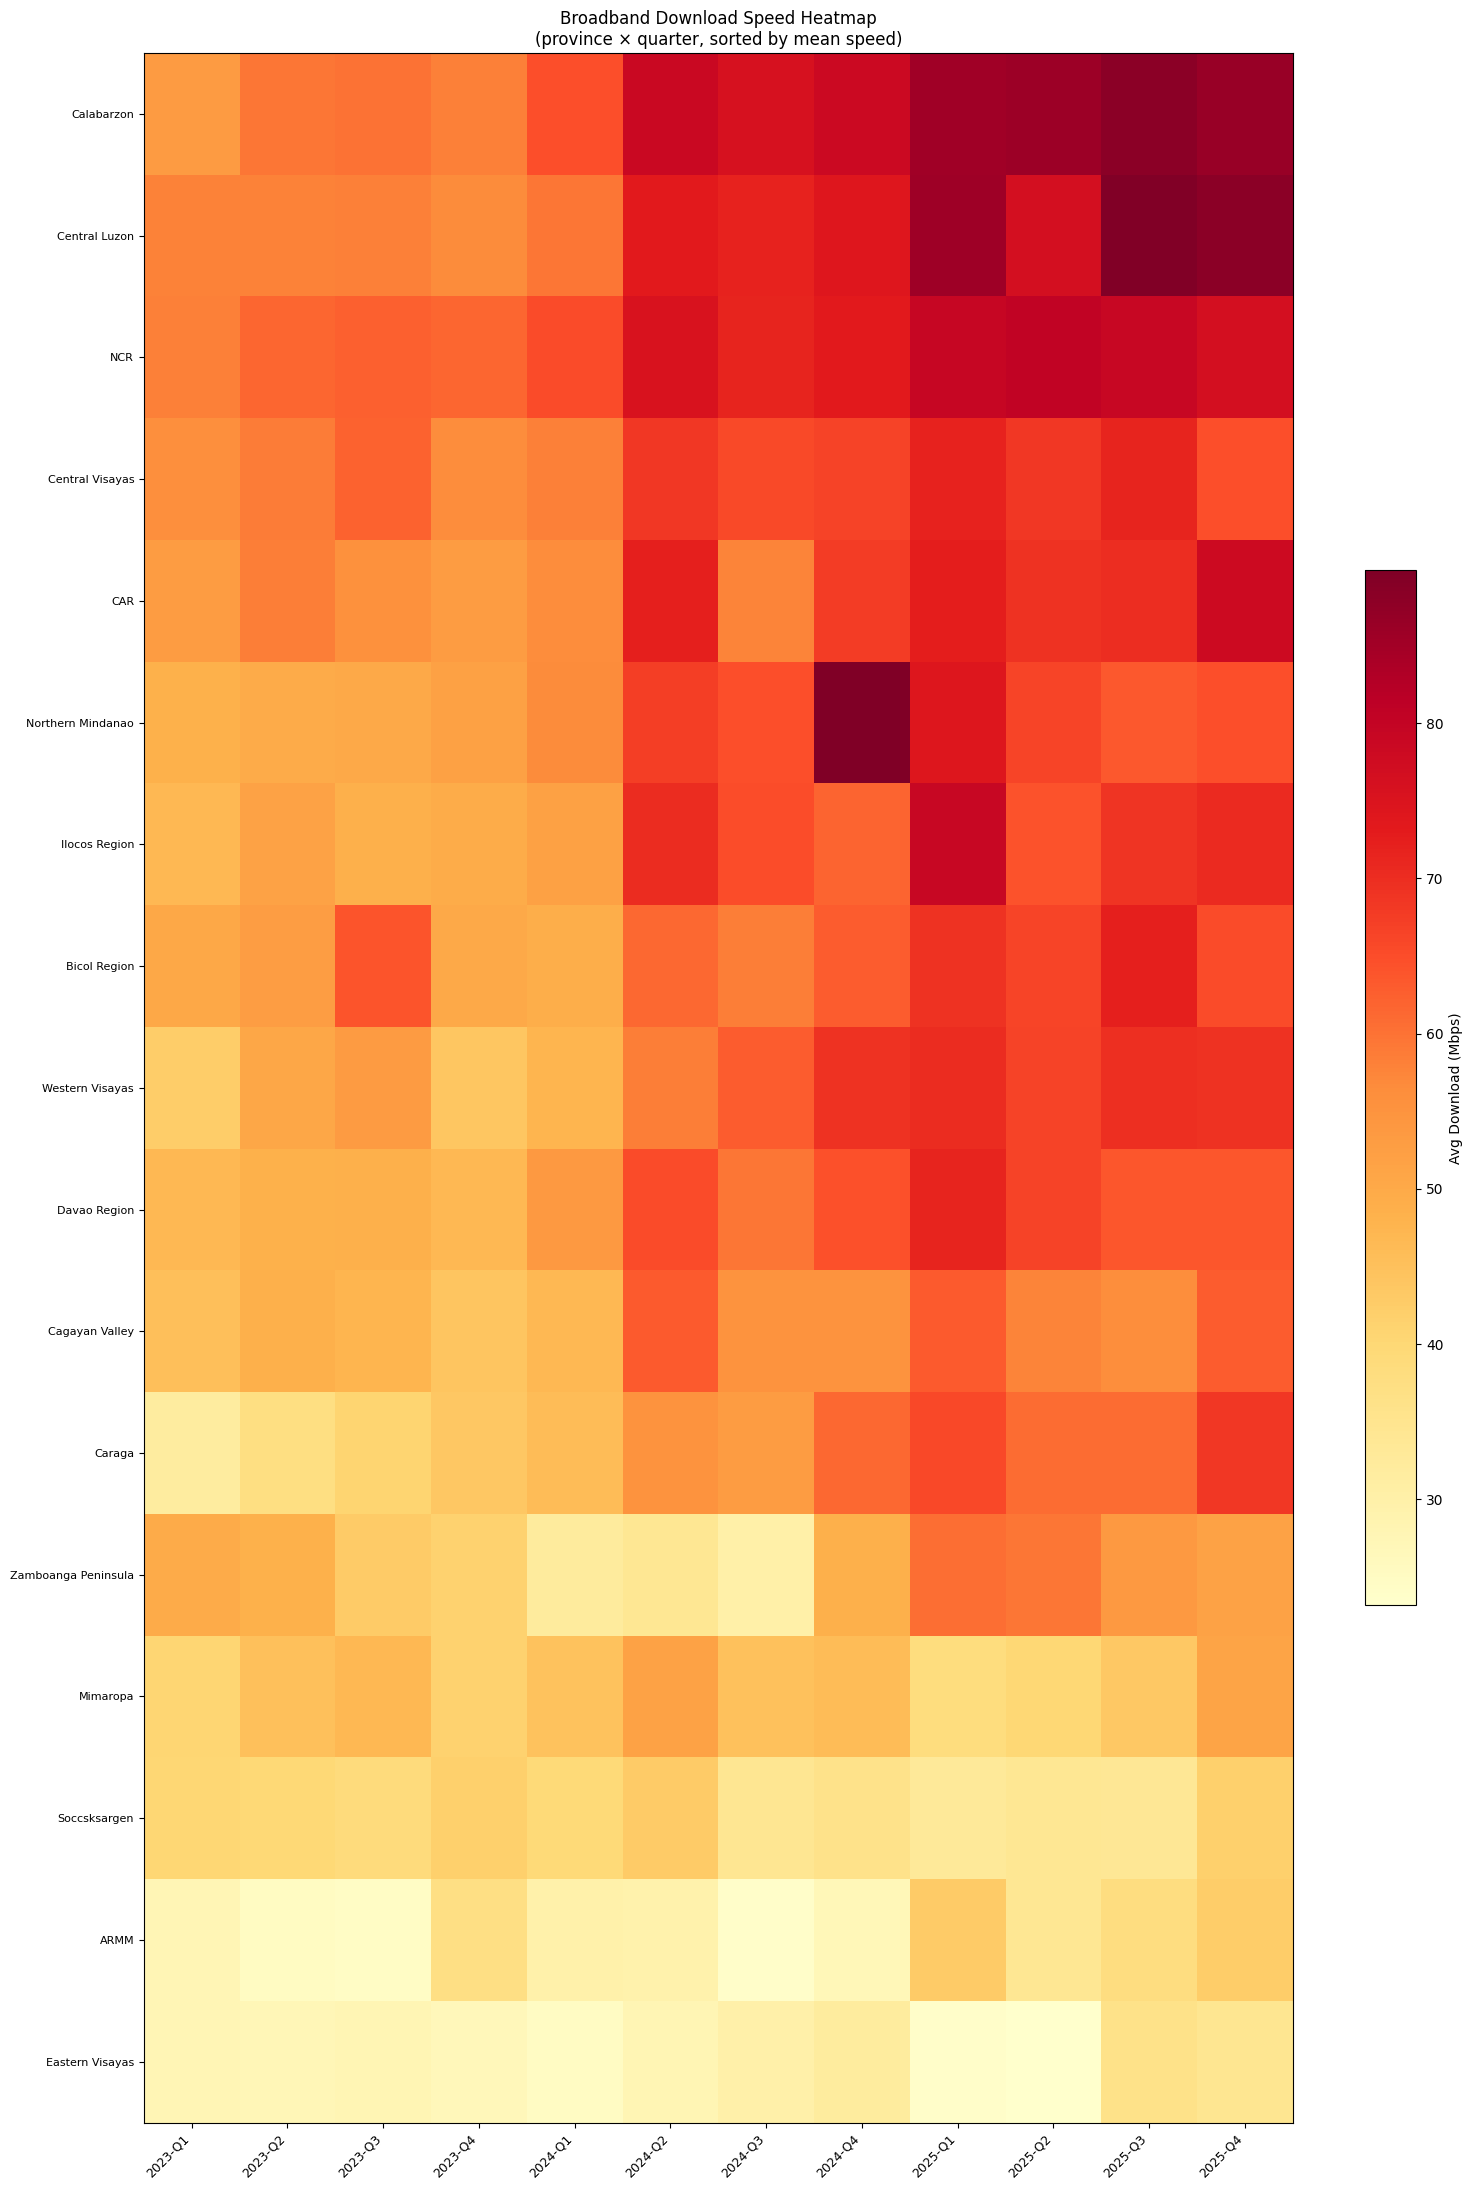

In [13]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Broadband — skipping heatmap.")
else:
    pivot_dl = master.pivot_table(index='name', columns='period_start', values='avg_d_mbps')
    pivot_dl.columns = [pd.Timestamp(c).strftime('%Y-Q') + str((pd.Timestamp(c).month-1)//3+1) for c in pivot_dl.columns]
    pivot_dl = pivot_dl.loc[prov_mean.sort_values('mean_dl', ascending=False)['name']]

    fig, ax = plt.subplots(figsize=(16, 22))
    im = ax.imshow(pivot_dl.values, aspect='auto', cmap='YlOrRd', interpolation='nearest')
    plt.colorbar(im, ax=ax, label='Avg Download (Mbps)', shrink=0.5)
    ax.set_xticks(range(len(pivot_dl.columns)))
    ax.set_xticklabels(pivot_dl.columns, rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(len(pivot_dl.index)))
    ax.set_yticklabels(pivot_dl.index, fontsize=8)
    ax.set_title('Broadband Download Speed Heatmap\n(province × quarter, sorted by mean speed)', fontsize=12)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/philippines/13_heatmap_quarterly.png', dpi=150, bbox_inches='tight')
    plt.show()

### 6. Regional Comparison — Download, Upload, Latency

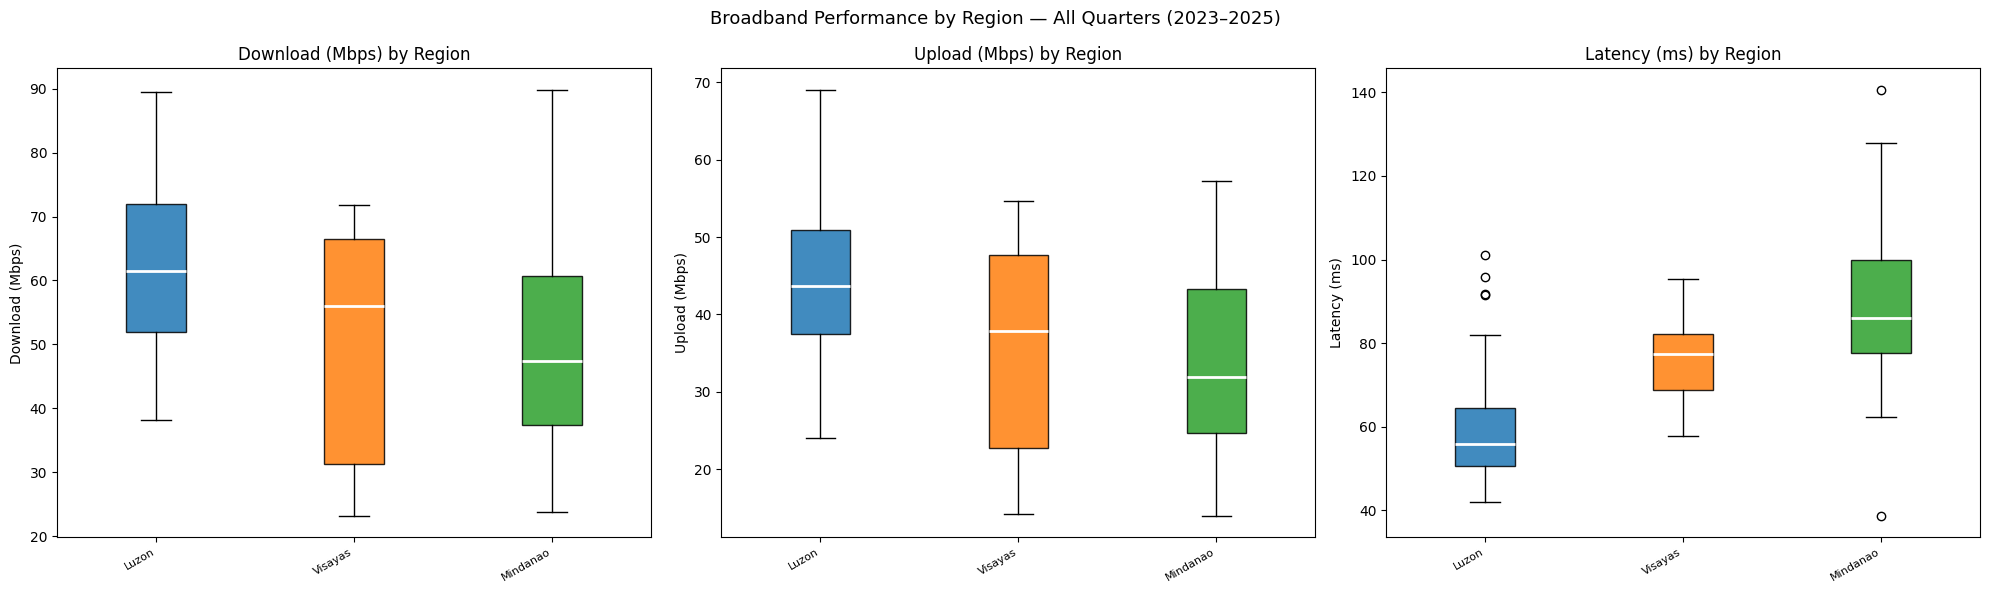

In [14]:
region_order = ['Luzon', 'Visayas', 'Mindanao']

if not HAS_RELIABLE_DATA:
    print("No reliable data for Broadband — skipping regional boxplot.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    for ax, metric, label, color_key in [
        (axes[0], 'avg_d_mbps',   'Download (Mbps)', '#457b9d'),
        (axes[1], 'avg_u_mbps',   'Upload (Mbps)',   '#2a9d8f'),
        (axes[2], 'avg_lat_ms_wt','Latency (ms)',    '#e76f51'),
    ]:
        data = [master[master['region']==r][metric].dropna().values for r in region_order]
        bp = ax.boxplot(data, patch_artist=True, notch=False, medianprops=dict(color='white', linewidth=2))
        for patch, region in zip(bp['boxes'], region_order):
            patch.set_facecolor(region_colors[region])
            patch.set_alpha(0.85)
        ax.set_xticklabels(region_order, rotation=30, ha='right', fontsize=8)
        ax.set_ylabel(label)
        ax.set_title(f'{label} by Region')
    plt.suptitle('Broadband Performance by Region — All Quarters (2023–2025)', fontsize=13)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/philippines/14_regional_boxplot.png', dpi=150, bbox_inches='tight')
    plt.show()

### 7. Download Speed Trend — Top, Bottom & Interesting Provinces

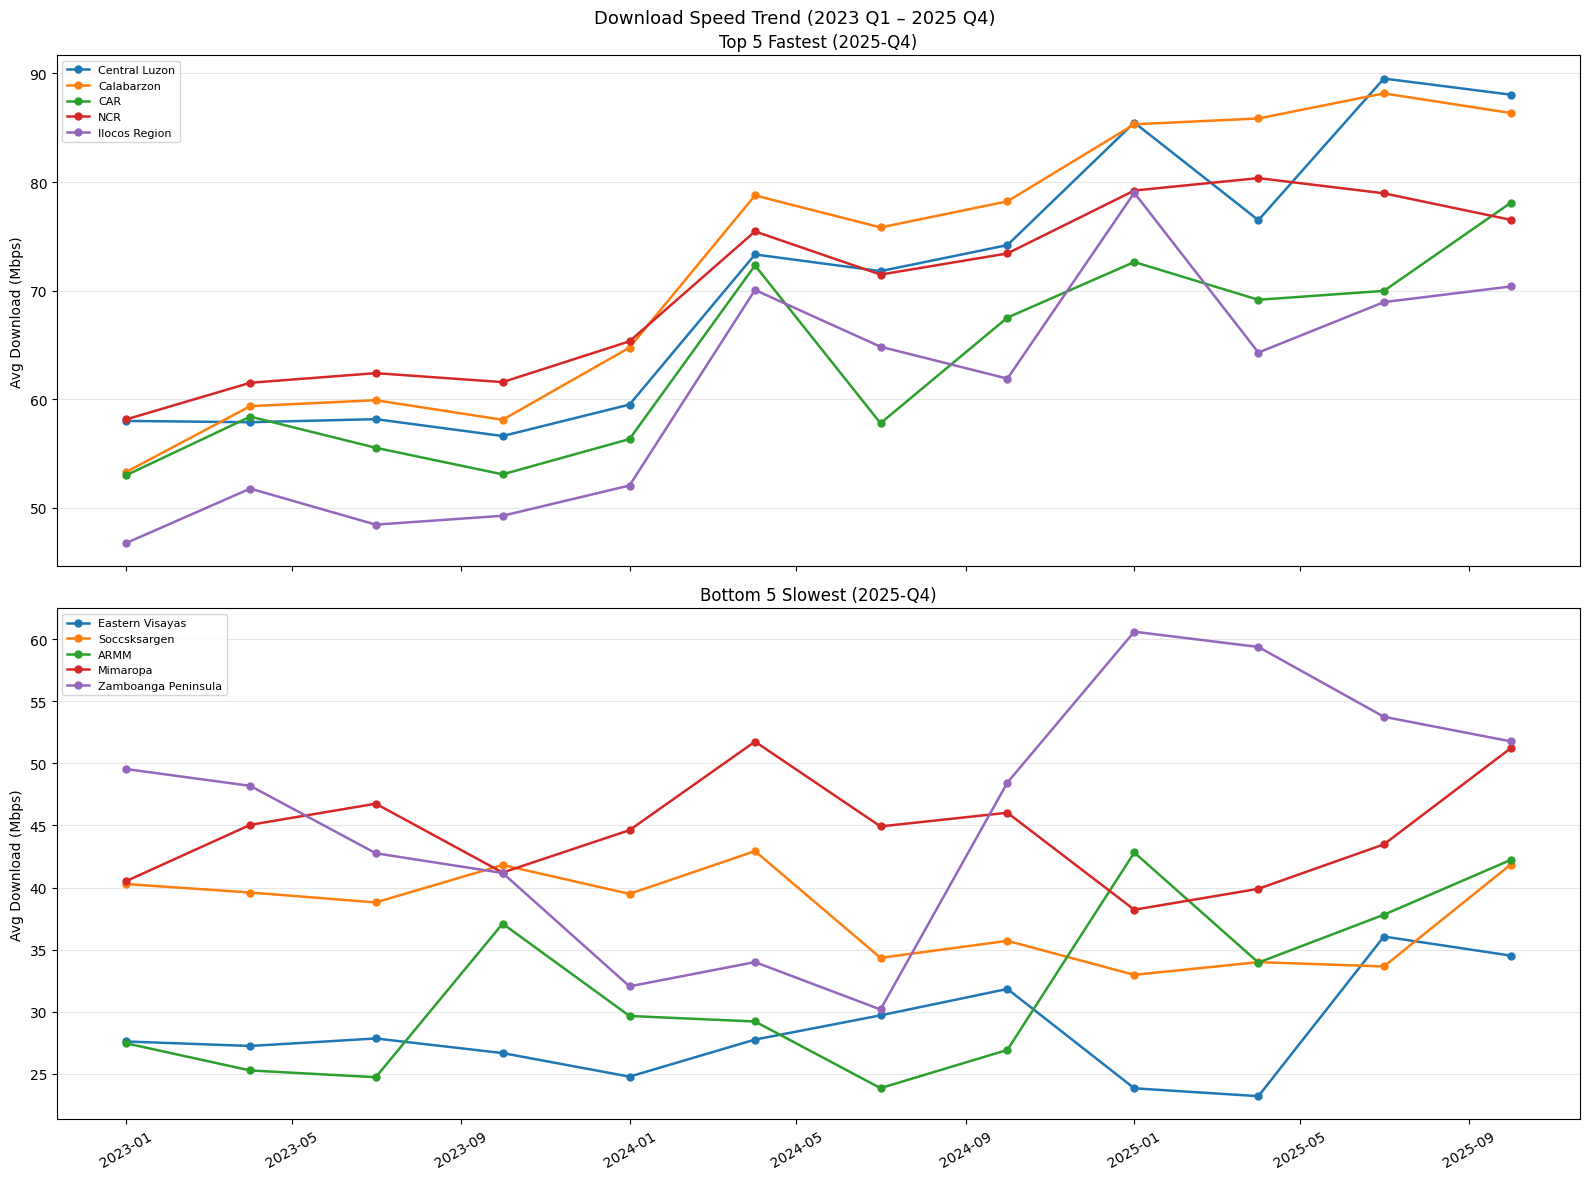

In [15]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Broadband — skipping time-series trend plot.")
else:
    latest_q = master['label'].max()
    latest = master[master['label'] == latest_q]
    top5 = latest.nlargest(5, 'avg_d_mbps')['name'].tolist()
    bot5 = latest.nsmallest(5, 'avg_d_mbps')['name'].tolist()

    fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)
    groups = [
        (f'Top 5 Fastest ({latest_q})', top5, '#e63946'),
        (f'Bottom 5 Slowest ({latest_q})', bot5, '#6d6875'),
    ]
    for ax, (title, provinces, base_color) in zip(axes, groups):
        for prov in provinces:
            df_p = master[master['name']==prov].sort_values('label')
            if df_p.empty: continue
            ax.plot(df_p['period_start'], df_p['avg_d_mbps'], marker='o', markersize=5, label=prov, linewidth=1.8)
        ax.set_ylabel('Avg Download (Mbps)')
        ax.set_title(title)
        ax.legend(fontsize=8, loc='upper left')
        ax.grid(axis='y', alpha=0.3)
        ax.tick_params(axis='x', rotation=30)
    plt.suptitle('Download Speed Trend (2023 Q1 – 2025 Q4)', fontsize=13)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/philippines/15_time_series.png', dpi=150, bbox_inches='tight')
    plt.show()

### 8. GDP per Capita vs Download Speed — Does Money = Speed?

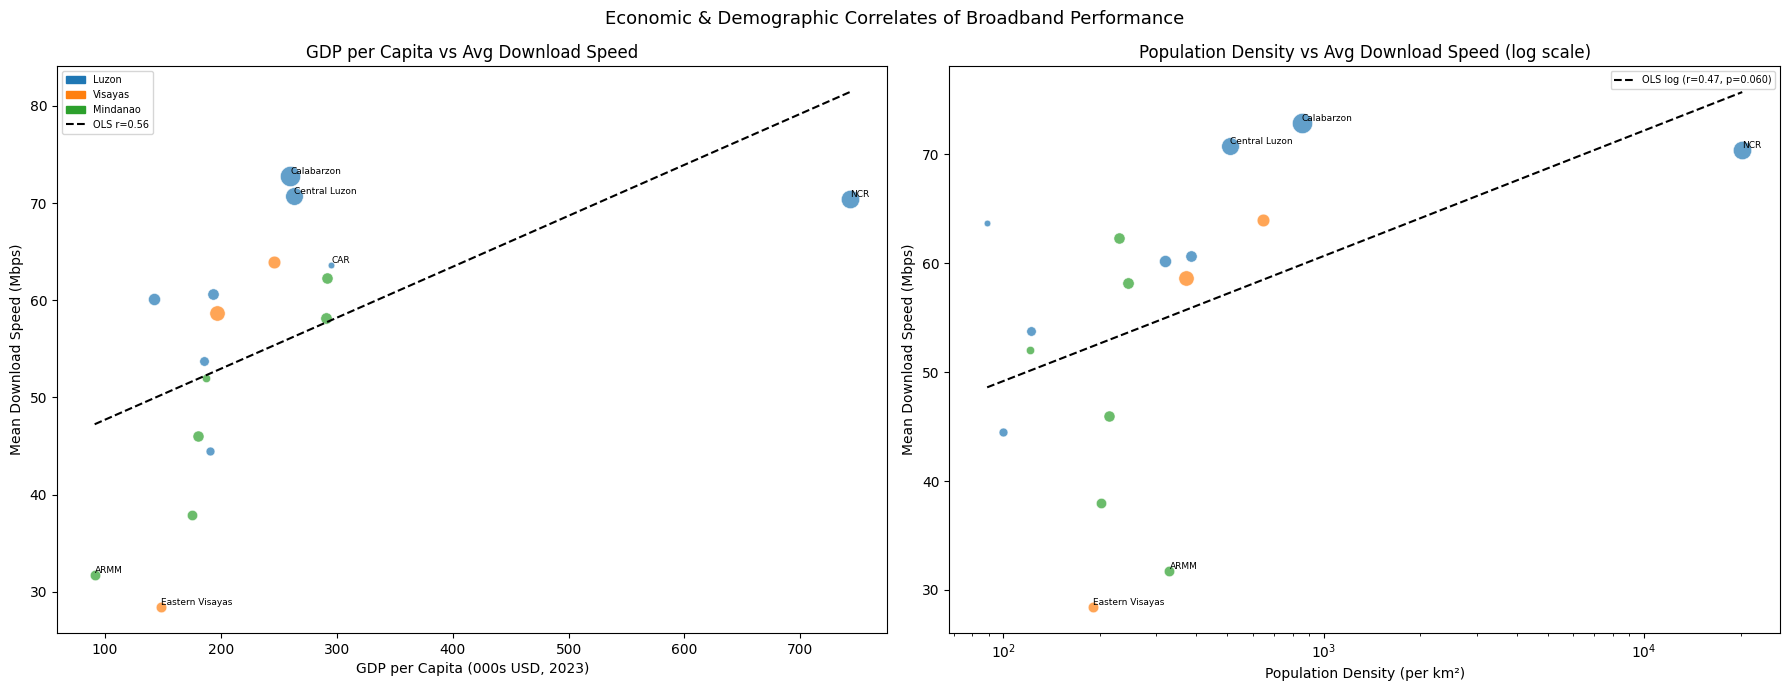

Pearson r (GDP vs download):     0.559  p=0.0197
Pearson r (log density vs download): 0.465  p=0.0598


In [16]:
if not HAS_RELIABLE_DATA:
    corr_df = pd.DataFrame(columns=['name','region','mean_dl','gdp_per_capita_thb_2021','internet_tier','pop_2024','density_per_km2'])
    r, p, r2, p2 = float('nan'), float('nan'), float('nan'), float('nan')
    print("No reliable data for Broadband — skipping GDP/density correlation plot.")
else:
    corr_df = prov_mean.merge(
        prov_ref[['province_en','gdp_per_capita_thb_2021','internet_tier','pop_2024','density_per_km2']].rename(columns={'province_en':'name'}),
        on='name', how='left'
    )

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    for _, row in corr_df.iterrows():
        c = region_colors.get(row['region'], 'gray')
        axes[0].scatter(row['gdp_per_capita_thb_2021']/1000, row['mean_dl'],
                        color=c, s=row['pop_2024']/80000, alpha=0.7, edgecolors='white', lw=0.5)
        if row['gdp_per_capita_thb_2021'] > corr_df['gdp_per_capita_thb_2021'].quantile(0.9) or row['mean_dl'] > corr_df['mean_dl'].quantile(0.9) or row['mean_dl'] < corr_df['mean_dl'].quantile(0.1):
            axes[0].annotate(row['name'], (row['gdp_per_capita_thb_2021']/1000, row['mean_dl']), fontsize=6.5, ha='left', va='bottom')

    x = corr_df['gdp_per_capita_thb_2021'].dropna()/1000
    y = corr_df.loc[x.index,'mean_dl']
    if x.nunique() > 1:
        slope, intercept, r, p, _ = stats.linregress(x, y)
        xline = np.linspace(x.min(), x.max(), 100)
        axes[0].plot(xline, slope*xline+intercept, 'k--', lw=1.5, label=f'OLS (r={r:.2f}, p={p:.3f})')
        ols_handle = [plt.Line2D([0],[0],color='k',ls='--',label=f'OLS r={r:.2f}')]
    else:
        r, p = float('nan'), float('nan')
        axes[0].text(0.5, 0.05, 'GDP per capita uniform across regions — no regression', transform=axes[0].transAxes, ha='center', fontsize=8, style='italic')
        ols_handle = []
    axes[0].set_xlabel('GDP per Capita (000s USD, 2023)')
    axes[0].set_ylabel('Mean Download Speed (Mbps)')
    axes[0].set_title('GDP per Capita vs Avg Download Speed')
    patches = [mpatches.Patch(color=v, label=k) for k,v in region_colors.items()]
    axes[0].legend(handles=patches+ols_handle, fontsize=7)

    for _, row in corr_df.iterrows():
        c = region_colors.get(row['region'],'gray')
        axes[1].scatter(row['density_per_km2'], row['mean_dl'], color=c, s=row['pop_2024']/80000, alpha=0.7, edgecolors='white', lw=0.5)
        if row['density_per_km2'] > corr_df['density_per_km2'].quantile(0.9) or row['mean_dl'] > corr_df['mean_dl'].quantile(0.9) or row['mean_dl'] < corr_df['mean_dl'].quantile(0.1):
            axes[1].annotate(row['name'], (row['density_per_km2'], row['mean_dl']), fontsize=6.5, ha='left', va='bottom')

    x2 = corr_df['density_per_km2'].dropna()
    y2 = corr_df.loc[x2.index,'mean_dl']
    if x2.nunique() > 1:
        s2,i2,r2,p2,_ = stats.linregress(np.log1p(x2), y2)
        xline2 = np.linspace(x2.min(), x2.max(), 200)
        axes[1].plot(xline2, s2*np.log1p(xline2)+i2, 'k--', lw=1.5, label=f'OLS log (r={r2:.2f}, p={p2:.3f})')
    else:
        r2, p2 = float('nan'), float('nan')
    axes[1].set_xlabel('Population Density (per km²)')
    axes[1].set_xscale('log')
    axes[1].set_ylabel('Mean Download Speed (Mbps)')
    axes[1].set_title('Population Density vs Avg Download Speed (log scale)')
    axes[1].legend(fontsize=7)

    plt.suptitle('Economic & Demographic Correlates of Broadband Performance', fontsize=13)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/philippines/16_gdp_speed_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Pearson r (GDP vs download):     {r:.3f}  p={p:.4f}")
    print(f"Pearson r (log density vs download): {r2:.3f}  p={p2:.4f}")

### 8.5 Multivariate Model — GDP + Density + Tier + Region Together

In [17]:
import statsmodels.formula.api as smf

if not HAS_RELIABLE_DATA or len(corr_df.dropna(subset=['mean_dl'])) < 5:
    print("No reliable data for Broadband — skipping multivariate model (need >=5 observations to fit).")
else:
    model_df = corr_df.dropna(subset=['mean_dl', 'gdp_per_capita_thb_2021', 'density_per_km2', 'region', 'internet_tier']).copy()
    model_df['log_gdp'] = np.log(model_df['gdp_per_capita_thb_2021'])
    model_df['log_density'] = np.log1p(model_df['density_per_km2'])

    terms = []
    if model_df['log_gdp'].nunique() > 1:
        terms.append('log_gdp')
    if model_df['log_density'].nunique() > 1:
        terms.append('log_density')
    if model_df['internet_tier'].nunique() > 1:
        terms.append("C(internet_tier)")
    if model_df['region'].nunique() > 1:
        terms.append('C(region)')

    if not terms:
        print("No varying predictors — skipping multivariate model.")
    else:
        formula = 'mean_dl ~ ' + ' + '.join(terms)
        mv_model = smf.ols(formula, data=model_df).fit()
        print(mv_model.summary())
        print(f"\nMultivariate R\u00b2 = {mv_model.rsquared:.3f}  (bivariate GDP-only r\u00b2 = {r**2:.3f})")
        print(f"Adjusted R\u00b2 = {mv_model.rsquared_adj:.3f}")

                            OLS Regression Results                            
Dep. Variable:                mean_dl   R-squared:                       0.838
Model:                            OLS   Adj. R-squared:                  0.713
Method:                 Least Squares   F-statistic:                     6.665
Date:                Wed, 29 Jul 2026   Prob (F-statistic):            0.00560
Time:                        19:41:37   Log-Likelihood:                -52.123
No. Observations:                  17   AIC:                             120.2
Df Residuals:                       9   BIC:                             126.9
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept               -11.02

### 9. Upload/Download Ratio — Symmetry Check

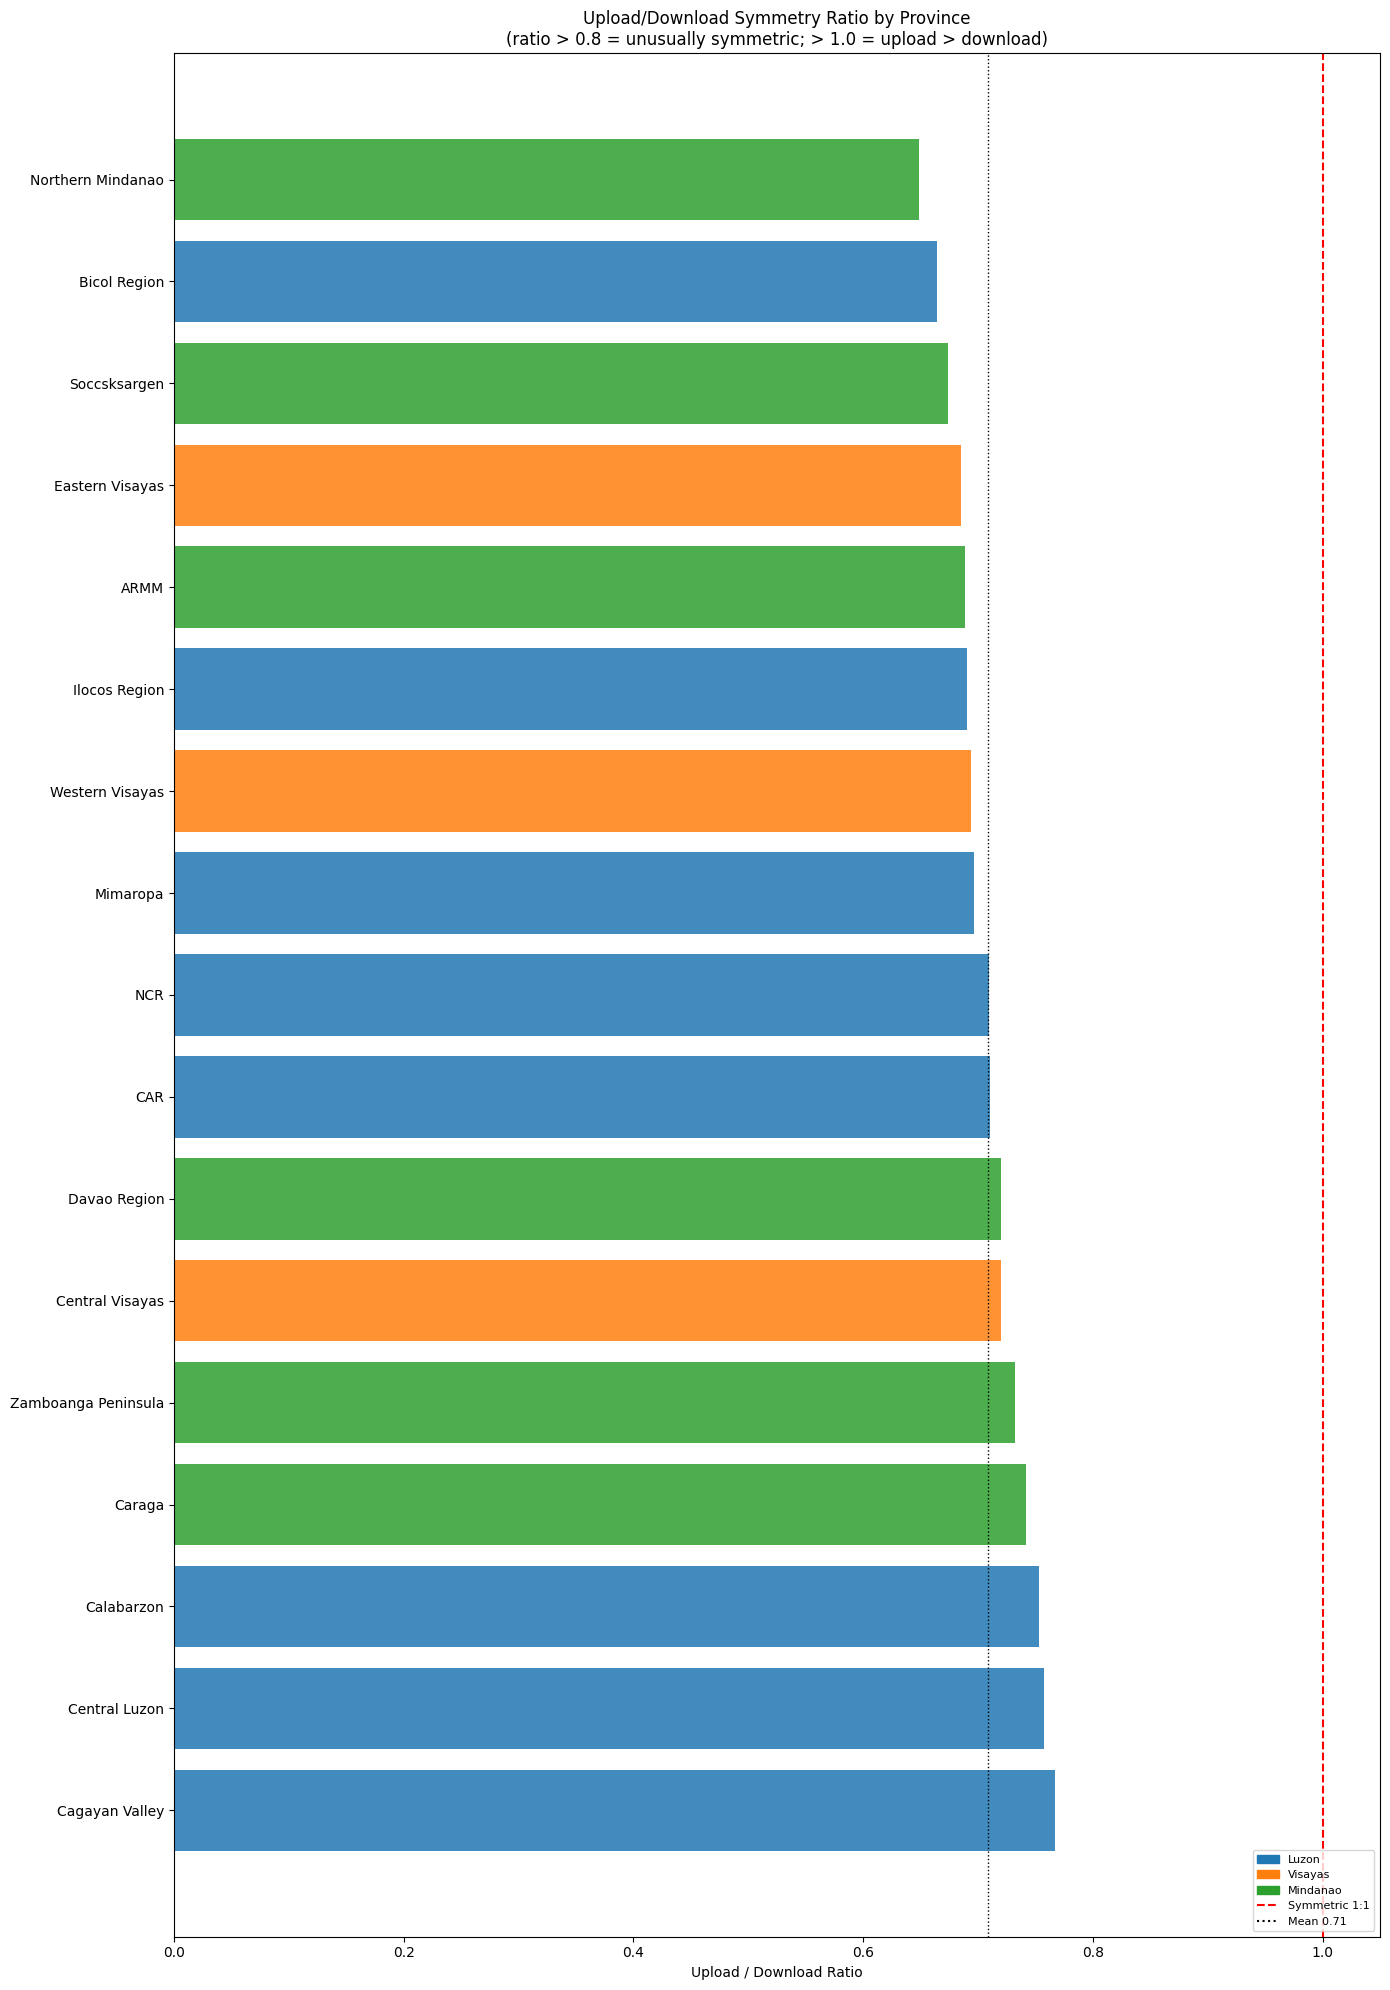

Provinces with UL/DL ratio > 0.8 (0):
Empty DataFrame
Columns: [name, region, ul_dl_ratio]
Index: []


In [18]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Broadband — skipping UL/DL ratio plot.")
else:
    master['ul_dl_ratio'] = master['avg_u_mbps'] / master['avg_d_mbps']
    ratio_mean = master.groupby('name')['ul_dl_ratio'].mean().sort_values(ascending=False).reset_index()
    ratio_mean = ratio_mean.merge(prov_ref[['province_en','region']].rename(columns={'province_en':'name'}), on='name', how='left')

    fig, ax = plt.subplots(figsize=(14, 20))
    colors = [region_colors.get(r,'gray') for r in ratio_mean['region']]
    ax.barh(ratio_mean['name'], ratio_mean['ul_dl_ratio'], color=colors, alpha=0.85)
    ax.axvline(1.0, color='red', ls='--', lw=1.5, label='Symmetric (1:1)')
    ax.axvline(ratio_mean['ul_dl_ratio'].mean(), color='black', ls=':', lw=1, label=f'Mean ratio {ratio_mean["ul_dl_ratio"].mean():.2f}')
    ax.set_xlabel('Upload / Download Ratio')
    ax.set_title('Upload/Download Symmetry Ratio by Province\n(ratio > 0.8 = unusually symmetric; > 1.0 = upload > download)')
    patches = [mpatches.Patch(color=v, label=k) for k,v in region_colors.items()]
    ax.legend(handles=patches+[
        plt.Line2D([0],[0],color='red',ls='--',label='Symmetric 1:1'),
        plt.Line2D([0],[0],color='black',ls=':',label=f'Mean {ratio_mean["ul_dl_ratio"].mean():.2f}')
    ], fontsize=8, loc='lower right')
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/philippines/17_uldl_ratio_bar.png', dpi=150, bbox_inches='tight')
    plt.show()

    divergent_ratio = ratio_mean[ratio_mean['ul_dl_ratio'] > 0.8]
    print(f"Provinces with UL/DL ratio > 0.8 ({len(divergent_ratio)}):")
    print(divergent_ratio[['name','region','ul_dl_ratio']].to_string(index=False))

### 10. Province Summary — Tier & UL/DL Ratio

In [19]:
from scipy import stats
import numpy as np

if not HAS_RELIABLE_DATA:
    high_ratio = pd.Series(dtype=float)
    prov_mean = pd.DataFrame(columns=['name','region','mean_dl','mean_ul','mean_lat','mean_tests','mean_ratio','tier'])
    print("No reliable data for Broadband — skipping province summary.")
else:
    master['ul_dl_ratio'] = master['avg_u_mbps'] / master['avg_d_mbps']
    high_ratio = master.groupby('name')['ul_dl_ratio'].mean()

    prov_mean = (
        master.groupby(['name','region'])
        .agg(
            mean_dl=('avg_d_mbps','mean'),
            mean_ul=('avg_u_mbps','mean'),
            mean_lat=('avg_lat_ms_wt','mean'),
            mean_tests=('total_tests','mean'),
            mean_ratio=('ul_dl_ratio','mean'),
        )
        .reset_index()
        .sort_values('mean_dl', ascending=False)
    )
    prov_mean['tier'] = prov_mean['name'].map(prov_ref.set_index('province_en')['internet_tier'].to_dict())

### 12. Full Province Summary Table

In [20]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Broadband — nothing to summarize.")
else:
    summary = prov_mean.merge(
        prov_ref[['province_en','pop_2024','gdp_per_capita_thb_2021','internet_tier']].rename(columns={'province_en':'name'}),
        on='name', how='left'
    ).copy()
    summary['ul_dl_ratio'] = summary['name'].map(high_ratio).round(3)
    summary = summary.sort_values('mean_dl', ascending=False).round(2)
    print(summary[[
        'name','region','internet_tier','mean_dl','mean_ul','mean_lat','ul_dl_ratio','mean_tests','gdp_per_capita_thb_2021'
    ]].to_string(index=False))

               name   region  internet_tier  mean_dl  mean_ul  mean_lat  ul_dl_ratio  mean_tests  gdp_per_capita_thb_2021
         Calabarzon    Luzon              2    72.83    54.88     63.07         0.75  1452114.25                259765.51
      Central Luzon    Luzon              2    70.75    53.56     49.51         0.76   858891.58                263326.87
                NCR    Luzon              1    70.37    50.00     56.71         0.71  3551588.25                742614.53
    Central Visayas  Visayas              2    63.97    46.18     80.09         0.72   898813.33                245591.30
                CAR    Luzon              1    63.66    44.99     77.51         0.71   207492.25                295236.64
  Northern Mindanao Mindanao              1    62.27    39.97     78.81         0.65   345850.17                291746.51
      Ilocos Region    Luzon              3    60.65    41.71     59.92         0.69   109171.17                193453.01
       Bicol Region    L

### 13. UL/DL Symmetry — Fiber Penetration Evidence

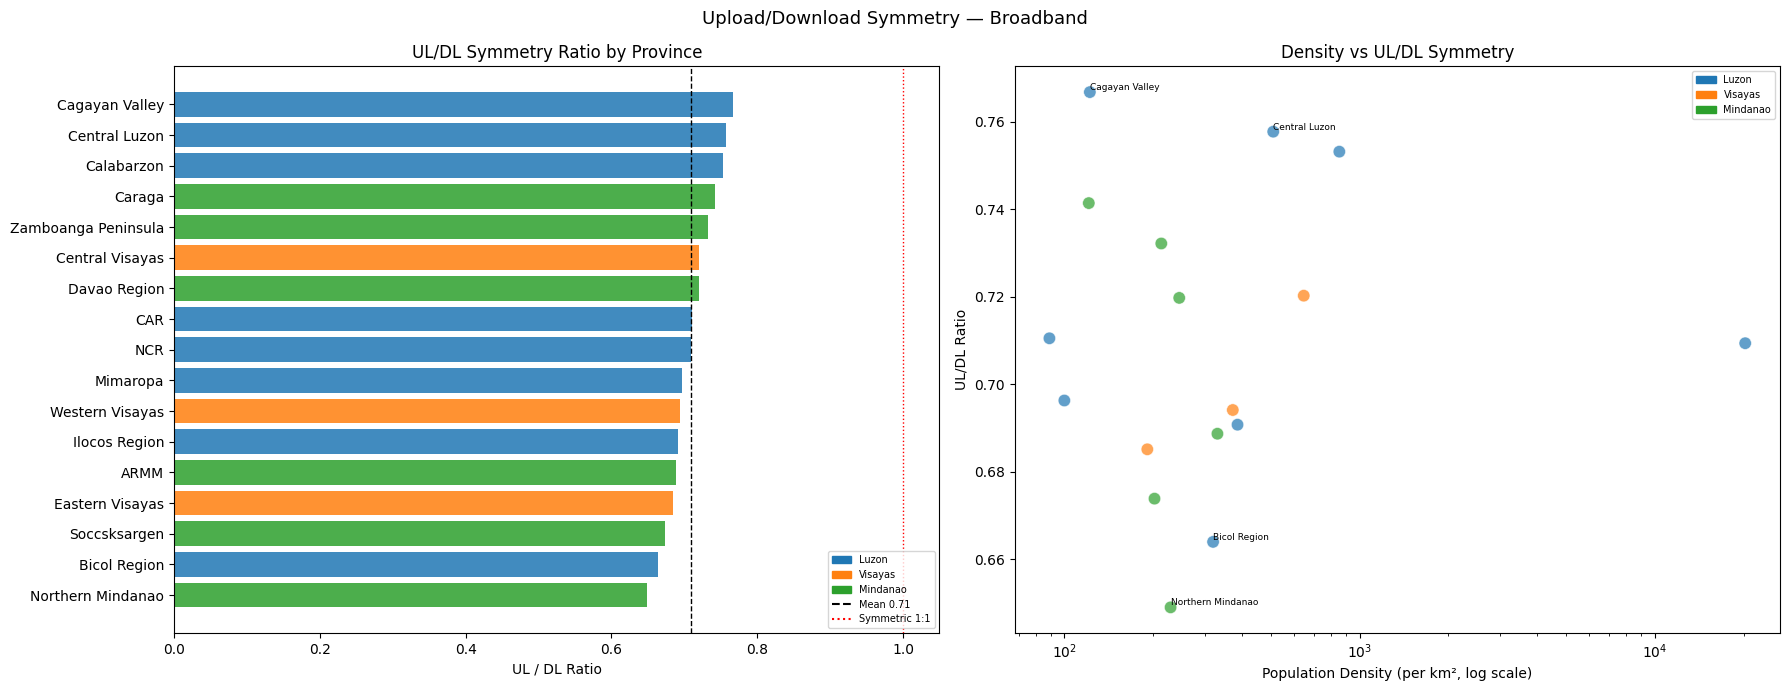

In [21]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Broadband — skipping UL/DL symmetry deep-dive.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    ratio_sorted = prov_mean.sort_values('mean_ratio', ascending=True)
    colors = [region_colors.get(r,'gray') for r in ratio_sorted['region']]
    axes[0].barh(ratio_sorted['name'], ratio_sorted['mean_ratio'], color=colors, alpha=0.85)
    axes[0].axvline(prov_mean['mean_ratio'].mean(), color='black', ls='--', lw=1, label=f"National mean {prov_mean['mean_ratio'].mean():.2f}")
    axes[0].axvline(1.0, color='red', ls=':', lw=1, label='Symmetric 1:1')
    axes[0].set_xlabel('UL / DL Ratio')
    axes[0].set_title('UL/DL Symmetry Ratio by Province')
    patches = [mpatches.Patch(color=v,label=k) for k,v in region_colors.items()]
    axes[0].legend(handles=patches + [
        plt.Line2D([0],[0],color='black',ls='--',label=f"Mean {prov_mean['mean_ratio'].mean():.2f}"),
        plt.Line2D([0],[0],color='red',ls=':',label='Symmetric 1:1'),
    ], fontsize=7, loc='lower right')

    axes[1].scatter(prov_ref.set_index('province_en').loc[prov_mean['name'],'density_per_km2'].values,
                    prov_mean['mean_ratio'].values,
                    c=[region_colors.get(r,'gray') for r in prov_mean['region']],
                    s=80, alpha=0.7, edgecolors='white', lw=0.5)
    for _, row in prov_mean.iterrows():
        if row['mean_ratio'] > prov_mean['mean_ratio'].quantile(0.9) or row['mean_ratio'] < prov_mean['mean_ratio'].quantile(0.1):
            density = prov_ref.loc[prov_ref['province_en']==row['name'],'density_per_km2'].values
            if len(density):
                axes[1].annotate(row['name'], (density[0], row['mean_ratio']), fontsize=6.5, ha='left', va='bottom')
    axes[1].set_xscale('log')
    axes[1].set_xlabel('Population Density (per km², log scale)')
    axes[1].set_ylabel('UL/DL Ratio')
    axes[1].set_title('Density vs UL/DL Symmetry')
    axes[1].legend(handles=patches, fontsize=7)

    plt.suptitle('Upload/Download Symmetry — Broadband', fontsize=13)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/philippines/19_uldl_symmetry_ratio.png', dpi=150, bbox_inches='tight')
    plt.show()

### 14. Temporal: Speed Growth 2023 Q1 → 2025 Q4

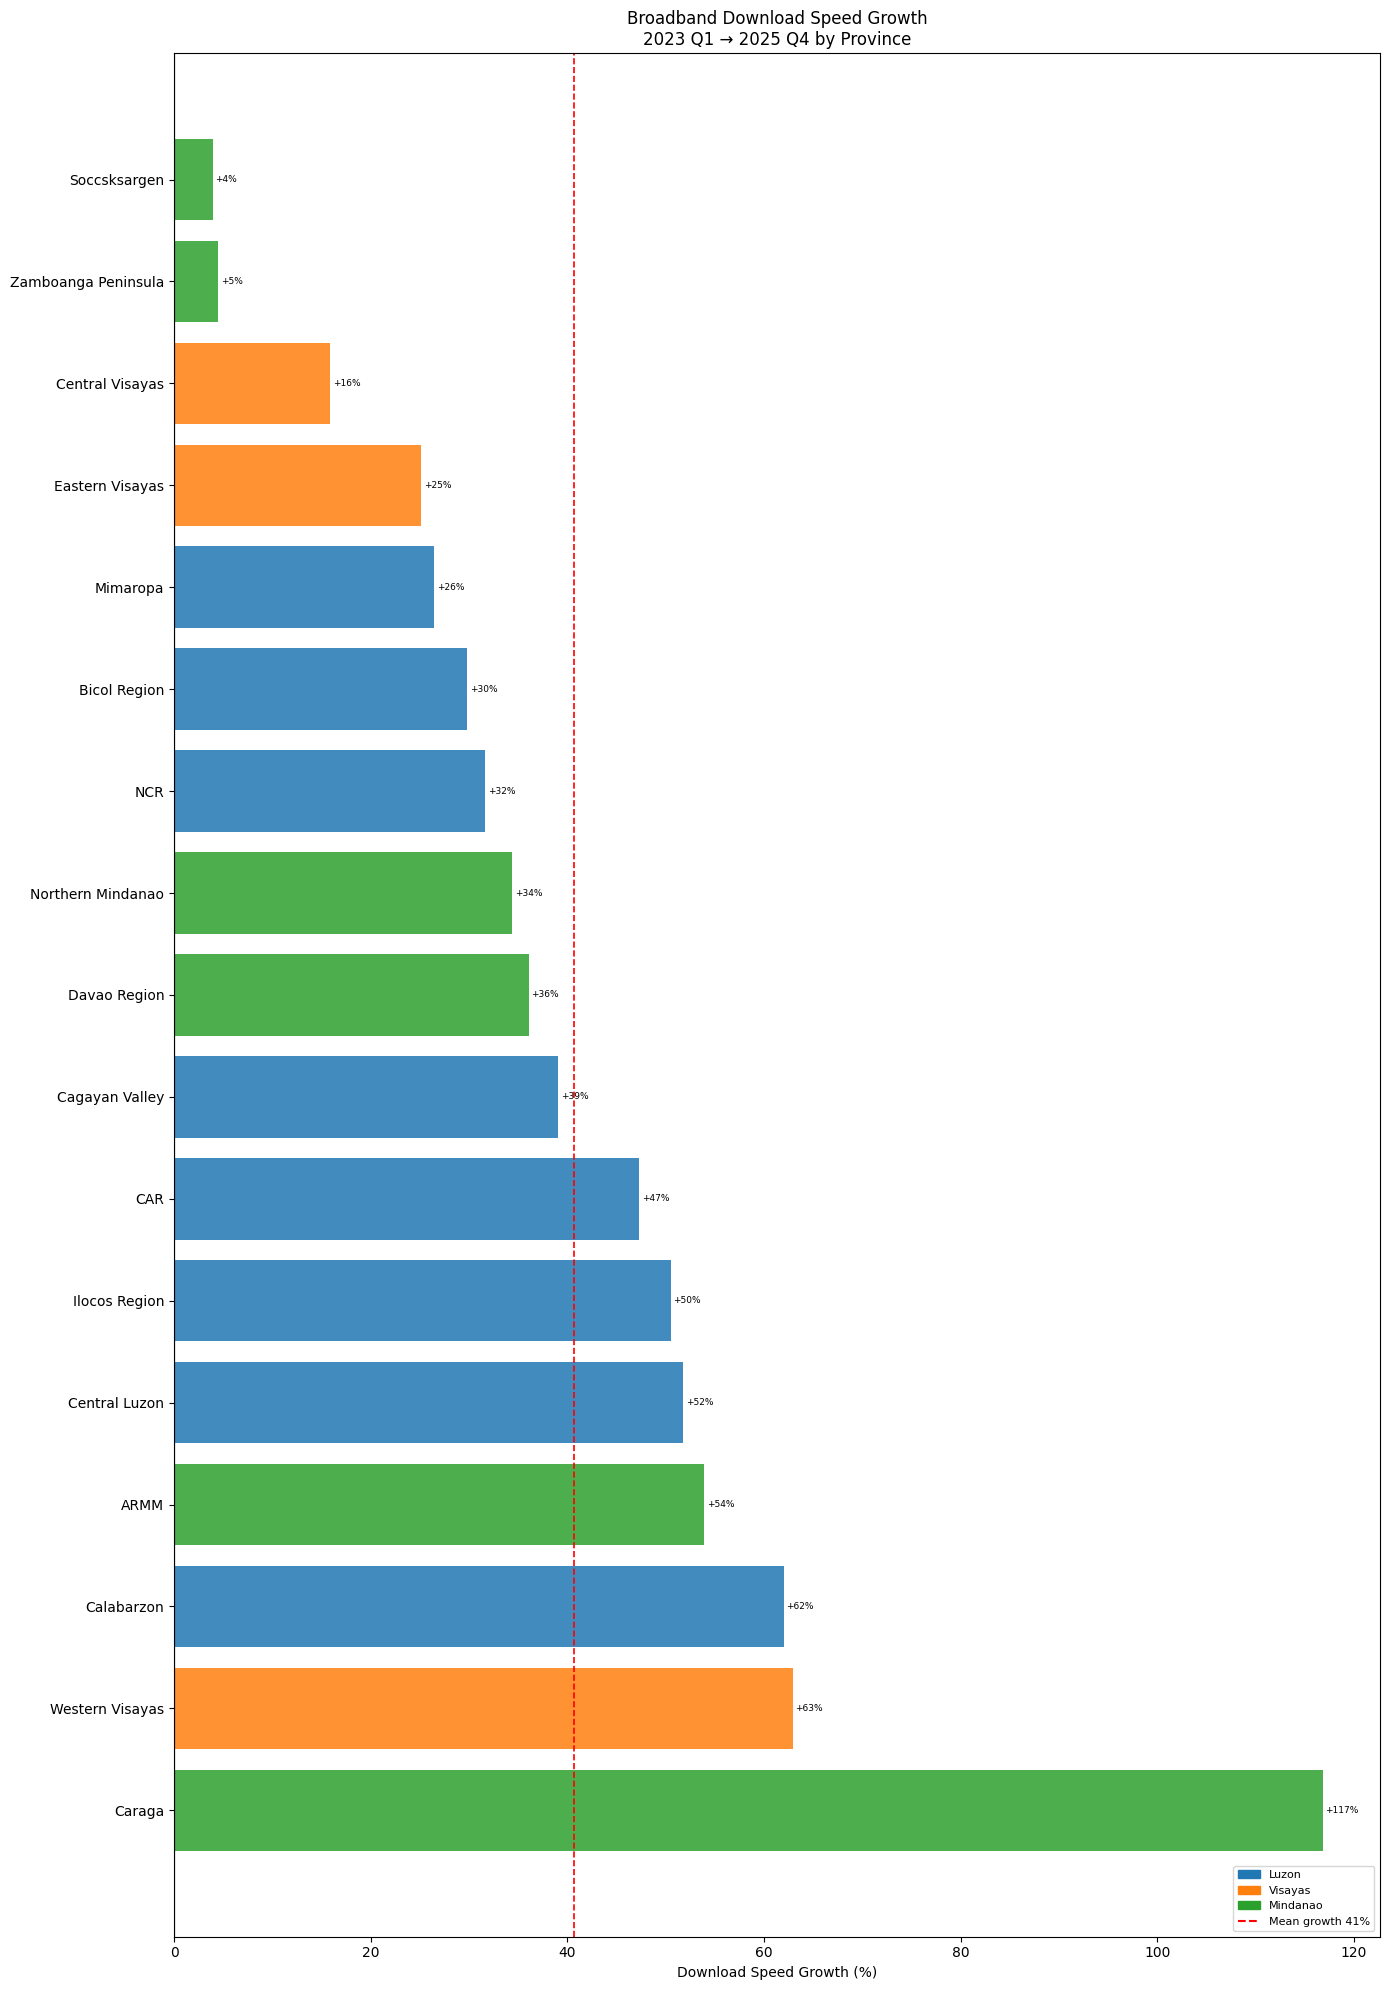

In [22]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Broadband — skipping temporal growth plot.")
else:
    first = master[master['label']=='2023-Q1'].set_index('name')['avg_d_mbps']
    last  = master[master['label']=='2025-Q4'].set_index('name')['avg_d_mbps']
    growth = ((last - first) / first * 100).dropna().sort_values(ascending=False)

    if growth.empty:
        print("No province has both a 2023-Q1 and 2025-Q4 reliable observation — skipping growth plot.")
    else:
        growth_df = growth.reset_index()
        growth_df.columns = ['name','pct_growth']
        growth_df = growth_df.merge(prov_ref[['province_en','region','internet_tier']].rename(columns={'province_en':'name'}), on='name', how='left')

        fig, ax = plt.subplots(figsize=(14, 20))
        colors = [region_colors.get(r,'gray') for r in growth_df['region']]
        bars = ax.barh(growth_df['name'], growth_df['pct_growth'], color=colors, alpha=0.85)
        ax.axvline(0, color='black', lw=0.8)
        ax.axvline(growth_df['pct_growth'].mean(), color='red', ls='--', lw=1.2, label=f"Mean growth {growth_df['pct_growth'].mean():.0f}%")
        for bar, val in zip(bars, growth_df['pct_growth']):
            ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, f'{val:+.0f}%', va='center', fontsize=6.5)
        patches = [mpatches.Patch(color=v,label=k) for k,v in region_colors.items()]
        ax.legend(handles=patches+[plt.Line2D([0],[0],color='red',ls='--',label=f"Mean growth {growth_df['pct_growth'].mean():.0f}%")], fontsize=8, loc='lower right')
        ax.set_xlabel('Download Speed Growth (%)')
        ax.set_title('Broadband Download Speed Growth\n2023 Q1 → 2025 Q4 by Province', fontsize=12)
        plt.tight_layout()
        plt.savefig('../../../outputs/ndt7/philippines/20_growth.png', dpi=150, bbox_inches='tight')
        plt.show()

### 15. Regional Growth Index — Trajectory Shape (Normalized to First Reliable Quarter = 100)
Complements the endpoint-only growth chart above (Q1 &#8594; Q4 % change) by showing the full trajectory per region, each region's own first valid quarter rebased to 100. Regions need at least half the available quarters with reliable data to be plotted, so noisy short-history regions are dropped instead of shown misleadingly. Rolled up from province to region level — adapted from the Myanmar/Laos NDT7 notebooks' growth-index cell, which plots at province level directly since those countries have far fewer top-level admin units than the province counts tracked here.


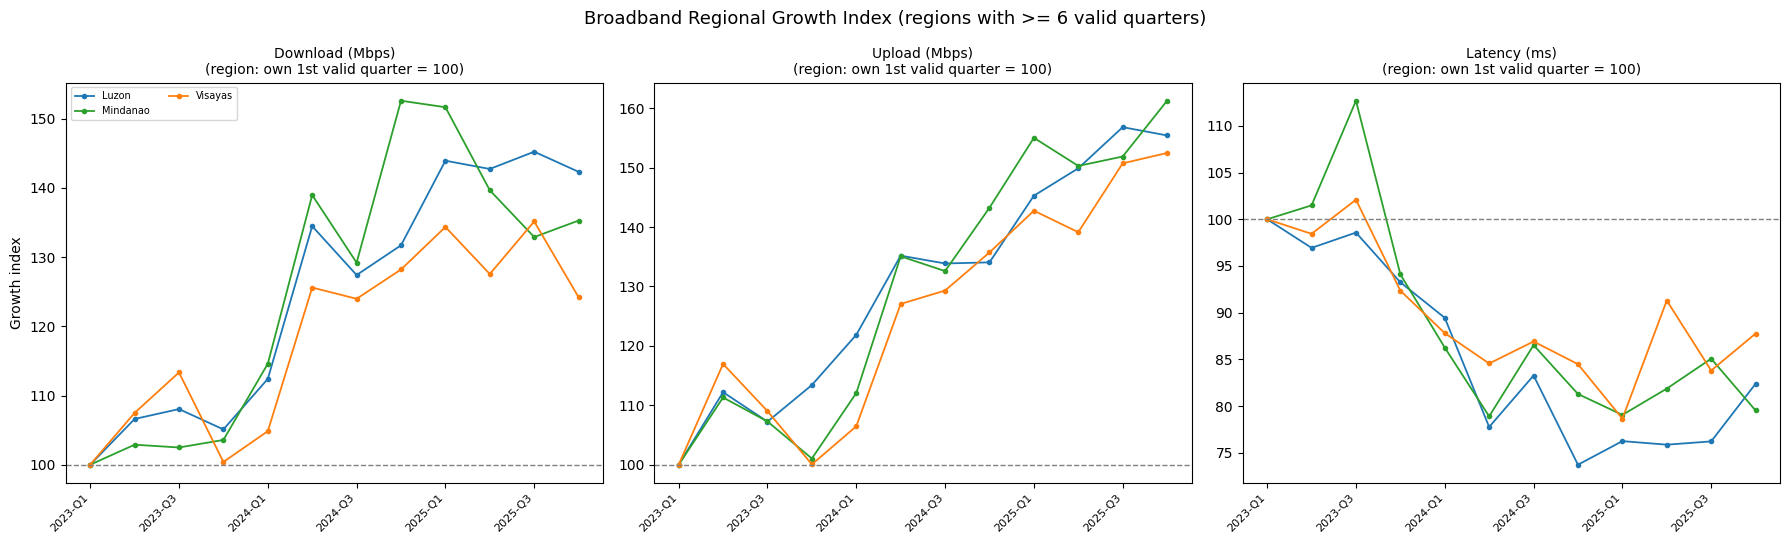

In [23]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Broadband — skipping regional growth-index plot.")
else:
    quarter_order = sorted(master['label'].unique())
    MIN_Q = max(3, len(quarter_order) // 2)

    region_q = (
        master.groupby(['region', 'label'])
        .apply(lambda g: pd.Series({
            'avg_d_mbps': np.average(g['avg_d_mbps'], weights=g['total_tests']),
            'avg_u_mbps': np.average(g['avg_u_mbps'], weights=g['total_tests']),
            'avg_lat_ms_wt': np.average(g['avg_lat_ms_wt'], weights=g['total_tests']),
        }), include_groups=False)
        .reset_index()
    )

    metrics = [('avg_d_mbps', 'Download (Mbps)'), ('avg_u_mbps', 'Upload (Mbps)'), ('avg_lat_ms_wt', 'Latency (ms)')]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
    any_plotted = False
    for ax, (col, label) in zip(axes, metrics):
        piv = region_q.pivot(index='region', columns='label', values=col).reindex(columns=quarter_order)
        valid = piv.notna().sum(axis=1)
        keep = valid[valid >= MIN_Q].index.tolist()
        if not keep:
            ax.text(0.5, 0.5, 'not enough data', transform=ax.transAxes, ha='center')
            continue
        for reg in keep:
            s = piv.loc[reg].dropna()
            xs = [quarter_order.index(q) for q in s.index]
            ax.plot(xs, s.values / s.iloc[0] * 100, marker='o', ms=3, lw=1.3,
                    color=region_colors.get(reg, 'gray'), label=reg)
            any_plotted = True
        ax.axhline(100, color='grey', ls='--', lw=1)
        step = max(1, len(quarter_order) // 6)
        ax.set_xticks(range(0, len(quarter_order), step))
        ax.set_xticklabels([quarter_order[i] for i in range(0, len(quarter_order), step)], rotation=45, ha='right', fontsize=8)
        ax.set_title(f'{label}\n(region: own 1st valid quarter = 100)', fontsize=10)
    axes[0].set_ylabel('Growth index')
    if any_plotted:
        axes[0].legend(fontsize=7, ncol=2, loc='upper left')
    plt.suptitle(f'Broadband Regional Growth Index (regions with >= {MIN_Q} valid quarters)', fontsize=13)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/philippines/21_growth_index_regional.png', dpi=150, bbox_inches='tight')
    plt.show()


### 15.5 Measured Speed Choropleth — Actual NDT7 Download Speed by Province
The "Internet Tier" map earlier in this notebook is a GDP-based *expectation*. This map is the actual measured NDT7 average, on the same province geometry, so the two can be compared directly. Adapted from the Myanmar/Laos NDT7 notebooks' choropleth cell (re-based here on `master`'s aggregated province averages instead of a live DuckDB query, since this pipeline works off the pre-aggregated CSV export, not the raw parquet).


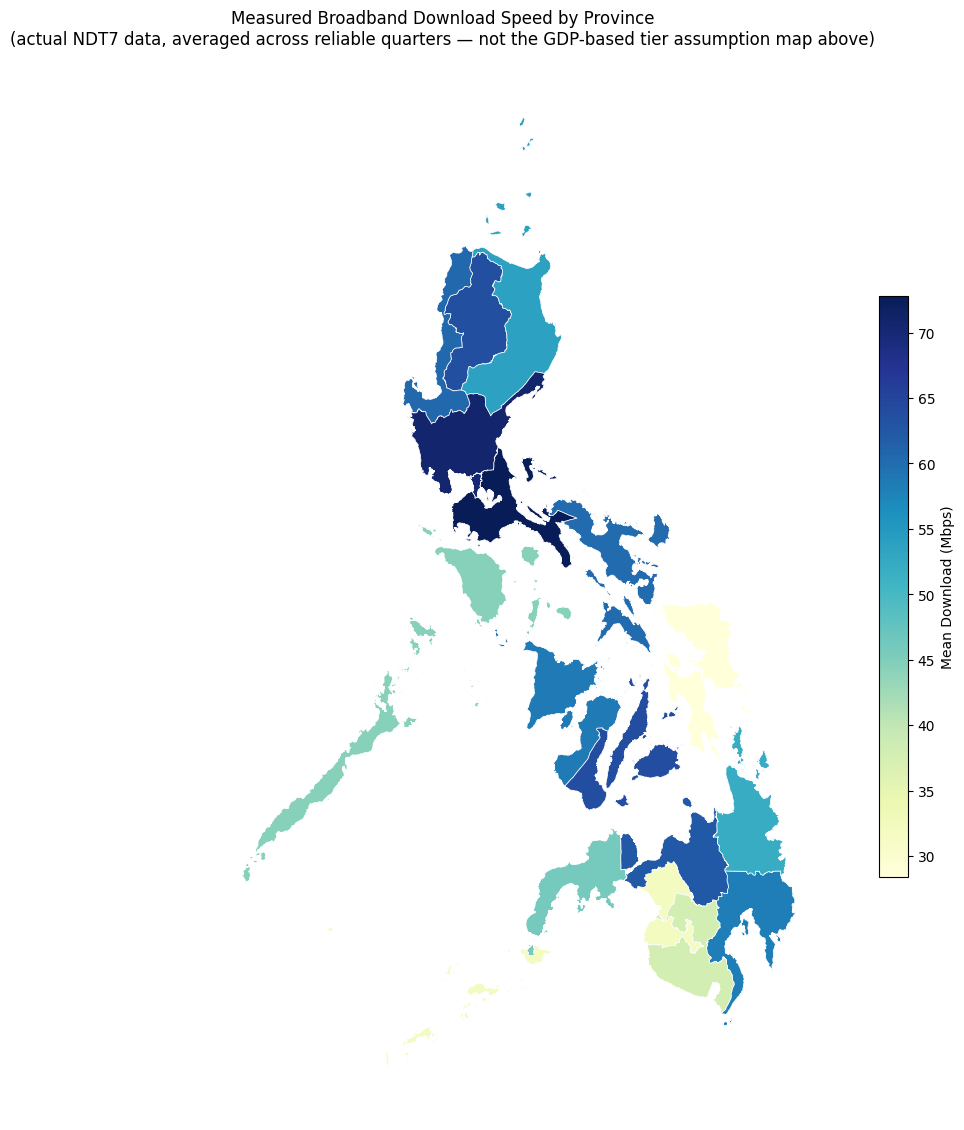

In [24]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Broadband — skipping measured-speed choropleth.")
else:
    prov_speed = (
        master.groupby('name')
        .agg(avg_d_mbps=('avg_d_mbps', 'mean'), total_tests=('total_tests', 'sum'))
        .reset_index()
    )
    geo_speed = thailand_gdf.merge(prov_speed, on='name', how='left')

    fig, ax = plt.subplots(figsize=(10, 12))
    geo_speed.plot(
        column='avg_d_mbps', ax=ax, cmap='YlGnBu', legend=True,
        edgecolor='white', linewidth=0.5,
        legend_kwds={'shrink': 0.5, 'label': 'Mean Download (Mbps)'},
        missing_kwds={'color': 'lightgrey', 'label': 'no reliable data'},
    )
    ax.set_title('Measured Broadband Download Speed by Province\n(actual NDT7 data, averaged across reliable quarters — not the GDP-based tier assumption map above)', fontsize=12)
    ax.set_axis_off()
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/philippines/22_speed_choropleth.png', dpi=150, bbox_inches='tight')
    plt.show()


### 16. City Focus — Capital + Top Cities by Test Volume (Broadband)
**Skipped for Philippines** — the raw NDT7 parquet has no `city` column (unlike Cambodia/Myanmar/Laos),
so this section cannot be built the same way. The capital-vs-rest-of-country comparison is
covered in much greater depth by the PH-specific **"Manila vs Rest of PH"** section appended at
the end of this notebook (national/regional split, top-10/bottom-10 provinces, mean AND median).


In [25]:
import duckdb
# ต้องมี _con ไว้ให้หัวข้อ 17/18 (ISP ranking + market share) ใช้ต่อ
# เดิมเซลล์นี้ลบบรรทัดสร้าง connection ไปพร้อมกับโค้ด city-focus ทำให้ทั้งเล่มพังที่หัวข้อ 17
_con = duckdb.connect()

print("City Focus skipped for Philippines — no `city` column in the raw NDT7 data. "
      "See the PH-specific \'Manila vs Rest of PH\' section at the end of this notebook instead.")


City Focus skipped for Philippines — no `city` column in the raw NDT7 data. See the PH-specific 'Manila vs Rest of PH' section at the end of this notebook instead.


### 17. Per-ISP Ranking — Top ISPs by Test Volume (Broadband)
Top 15 ISPs (min 100 tests) ranked by average download speed, bar length shows speed and
label shows test volume — adapted from the Myanmar/Laos NDT7 notebooks' per-ISP section.

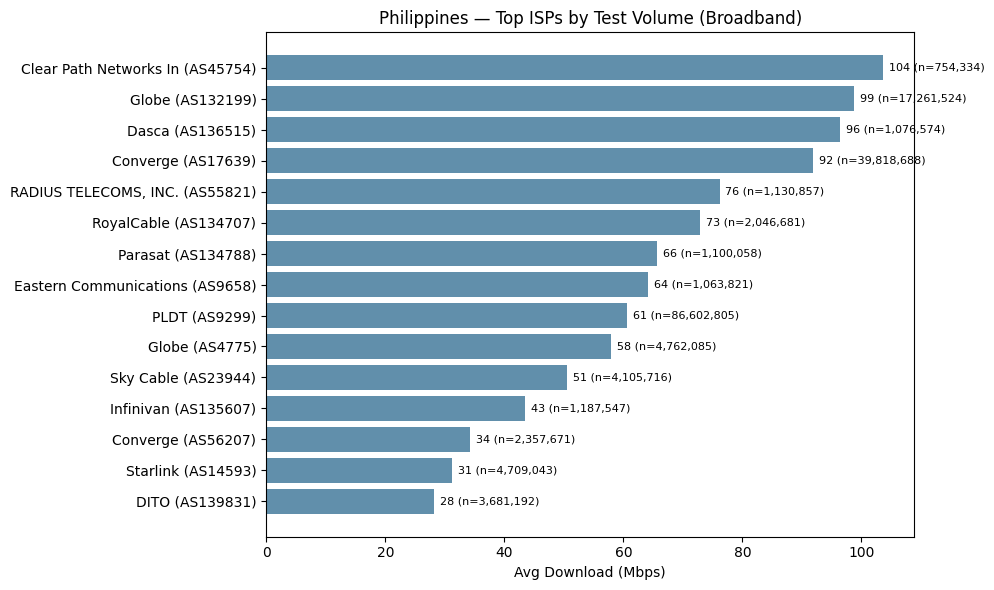

In [26]:
_isp_tbl = _con.execute(f"""
    -- จัดกลุ่มด้วย asn เท่านั้น (HANDOFF ข้อ 1): ip-api คืนชื่อองค์กรลูกค้าสำหรับ leased line
    -- เช่น AS4750 มีชื่อ isp ถึง 420 ชื่อ และชื่อเดียวกันก็กินหลาย ASN (TRUE INTERNET = 9 ASN)
    -- operator/as_name ใช้เป็นป้ายแสดงผลเท่านั้น
    WITH g AS (
        SELECT COALESCE(CAST(asn AS VARCHAR), '(unknown)') AS a,
               mode(operator) FILTER (WHERE operator IS NOT NULL) AS op,
               mode(as_name)  FILTER (WHERE as_name  IS NOT NULL) AS an,
               COUNT(*) AS n,
               AVG(mean_throughput_mbps) FILTER (WHERE type='download') AS avg_d_mbps
        FROM read_parquet('{RAW_ISP_PARQUET}')
        WHERE network_type = 'broadband'
        GROUP BY 1
    )
    -- ต่อรหัส ASN ท้ายป้าย: 1 แบรนด์มีได้หลาย ASN (ไทย True=2, AIS=3, NT=3, 3BB=2)
    -- ถ้าป้ายซ้ำ แกน categorical ของ matplotlib จะยุบแท่งทับกัน
    SELECT CASE WHEN a = '(unknown)' THEN '(unknown ASN)'
                ELSE substr(COALESCE(op, an, 'AS' || a), 1, 22) || ' (AS' || a || ')' END AS isp,
           n, avg_d_mbps
    FROM g
    WHERE n >= 100
    ORDER BY n DESC
    LIMIT 15
""").df()

if _isp_tbl.empty:
    print("No ISP meets the n>=100 test threshold for Broadband — skipping per-ISP ranking.")
else:
    _isp_tbl = _isp_tbl.sort_values('avg_d_mbps', ascending=True)
    fig, ax = plt.subplots(figsize=(10, max(4, 0.4*len(_isp_tbl))))
    ax.barh(_isp_tbl['isp'].str.slice(0, 40), _isp_tbl['avg_d_mbps'], color='#457b9d', alpha=0.85)
    for yi, (_, row) in enumerate(_isp_tbl.iterrows()):
        ax.text(row['avg_d_mbps'] + 1, yi, f"{row['avg_d_mbps']:.0f} (n={row['n']:,})", va='center', fontsize=8)
    ax.set_xlabel('Avg Download (Mbps)')
    ax.set_title('Philippines — Top ISPs by Test Volume (Broadband)')
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/philippines/24_per_isp.png', dpi=150, bbox_inches='tight')
    plt.show()

### 18. Market Share / HHI — ISP Concentration (Broadband)
Top 8 ISPs + "Others" + "(unknown ISP)" by share of tests. HHI (Herfindahl-Hirschman Index):
<1500 = competitive, 1500-2500 = moderate concentration, >2500 = highly concentrated —
adapted from the Myanmar/Laos NDT7 notebooks' market-share section.

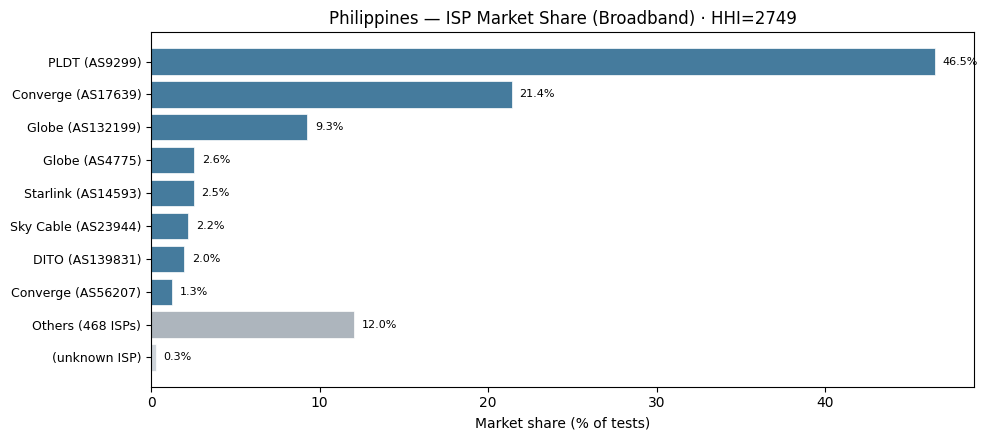

HHI=2749 (highly concentrated) | Top5 share=82.3% | unknown=0.3%


In [27]:
_mkt = _con.execute(f"""
    -- จัดกลุ่มด้วย asn เหมือน §17 (ดูเหตุผลข้างบน) — HHI อ่อนไหวกับการแตกชื่อมาก
    WITH g AS (
        SELECT COALESCE(CAST(asn AS VARCHAR), '(unknown)') AS a,
               mode(operator) FILTER (WHERE operator IS NOT NULL) AS op,
               mode(as_name)  FILTER (WHERE as_name  IS NOT NULL) AS an,
               COUNT(*) AS n
        FROM read_parquet('{RAW_ISP_PARQUET}')
        WHERE network_type = 'broadband'
        GROUP BY 1
    )
    SELECT CASE WHEN a = '(unknown)' THEN '(unknown)'
                ELSE substr(COALESCE(op, an, 'AS' || a), 1, 22) || ' (AS' || a || ')' END AS isp,
           n
    FROM g ORDER BY n DESC
""").df()

if _mkt.empty:
    print("No Broadband data — skipping market share.")
else:
    _total = _mkt['n'].sum()
    _mkt['share'] = 100 * _mkt['n'] / _total
    _named = _mkt[_mkt['isp'] != '(unknown)'].reset_index(drop=True)
    _unknown_share = float(_mkt.loc[_mkt['isp'] == '(unknown)', 'share'].sum())
    TOPN = 8
    _top = _named.head(TOPN)
    _others_share = float(_named['share'].iloc[TOPN:].sum())
    # HHI ต้องคิดบนฐานที่มีชื่อเท่านั้น — เดิมหารด้วย _total ที่รวม (unknown) ทำให้ HHI ต่ำกว่าจริง
    _named_share = 100.0 * _named['n'] / _named['n'].sum()
    _hhi = float((_named_share ** 2).sum())

    _rows = list(zip(_top['isp'].str.slice(0, 44), _top['share']))
    if _others_share > 0:
        _rows.append((f"Others ({len(_named) - len(_top)} ISPs)", _others_share))
    if _unknown_share > 0:
        _rows.append(("(unknown ISP)", _unknown_share))
    _labels = [r[0] for r in _rows][::-1]
    _vals = [r[1] for r in _rows][::-1]
    _colors = ['#adb5bd' if l.startswith('Others') else '#ced4da' if l.startswith('(unknown') else '#457b9d' for l in _labels]

    fig, ax = plt.subplots(figsize=(10, max(4, 0.45 * len(_vals))))
    y = list(range(len(_vals)))
    ax.barh(y, _vals, color=_colors, edgecolor='white', linewidth=0.5)
    ax.set_yticks(y)
    ax.set_yticklabels(_labels, fontsize=9)
    for yi, v in zip(y, _vals):
        ax.text(v + max(_vals) * 0.01, yi, f"{v:.1f}%", va='center', fontsize=8)
    ax.set_xlabel('Market share (% of tests)')
    ax.set_title(f"Philippines — ISP Market Share (Broadband) \u00b7 HHI={_hhi:.0f}")
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/philippines/25_market_share.png', dpi=150, bbox_inches='tight')
    plt.show()

    _hhi_note = 'competitive' if _hhi < 1500 else ('moderate' if _hhi < 2500 else 'highly concentrated')
    print(f"HHI={_hhi:.0f} ({_hhi_note}) | Top5 share={_named['share'].head(5).sum():.1f}% | unknown={_unknown_share:.1f}%")

### 19. EDA Key Findings Summary

## Key Findings from EDA

**Pending first execution** — this notebook has not been run against
`data/ndt7/ph/mlab_ph_clean.parquet` yet (not available locally in this repo). Once run, replace this
placeholder with: overall `is_reliable` rate (total_tests>=100 basis, not tile-based), which
regions clear/miss the bar, GDP-vs-speed correlation strength (if enough reliable regions),
top/bottom regions by download speed, and how the region-level picture here compares to the
richer province/island-level findings in the PH-specific sections below.


## Export for Comparison Notebook
*Saves province × quarter data to CSV.*

In [28]:
import os
os.makedirs("../../../data/exports", exist_ok=True)

EXPORT_COLS = [
    "name", "label", "year", "quarter",
    "avg_d_mbps", "avg_u_mbps", "avg_lat_ms_wt",
    "total_tests", "n_tiles", "is_reliable",
    "region", "internet_tier", "pop_2024",
    "gdp_per_capita_thb_2021", "density_per_km2",
]
existing_cols = [c for c in EXPORT_COLS if c in master.columns]
out = master[existing_cols].copy()
out = out.rename(columns={"name": "province", "label": "quarter"})

PATH = "../../../data/exports/ndt7_broadband_philippines_reliable_province_quarterly.csv"
out.to_csv(PATH, index=False)
print(f"Exported {len(out)} rows (reliable-only) -> {PATH}")
if len(out):
    print(out.head(3).to_string())
else:
    print("(0 rows — reliable-only export is empty; use the un-filtered prep-notebook output "
          "'ndt7_philippines_province_quarterly.csv' for any downstream use that needs raw coverage instead of the reliable subset.)")

Exported 204 rows (reliable-only) -> ../../../data/exports/ndt7_broadband_philippines_reliable_province_quarterly.csv
       province  quarter  year  quarter  avg_d_mbps  avg_u_mbps  avg_lat_ms_wt  total_tests  n_tiles  is_reliable    region  internet_tier  pop_2024  gdp_per_capita_thb_2021  density_per_km2
0          ARMM  2023-Q1  2023        1   27.442635   18.258656      88.570443        10775        5         True  Mindanao              4   4545486                 91028.33              330
1  Bicol Region  2023-Q1  2023        1   50.355003   37.493946      54.695450       172604       82         True     Luzon              4   6064426                142596.80              319
2           CAR  2023-Q1  2023        1   53.006888   36.954029      81.664147       154317       18         True     Luzon              1   1808985                295236.64               89


---
# Part 2 — Mobile/Cellular

## Full EDA — NDT7 Mobile/Cellular, Philippines (2023 Q1 – 2025 Q4)

### 1. Load Province x Quarter Data

In [29]:
import warnings
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from scipy import stats
warnings.filterwarnings('ignore')

NDT7_CSV = '../../../data/exports/ndt7_mobile_philippines_province_quarterly.csv'
GEOJSON  = '../../../data/geo/philippines_provinces.geojson'
PROV_REF = '../../../data/reference/philippines_reference.csv'

Q_TO_MONTH = {1: 1, 2: 4, 3: 7, 4: 10}

thailand_gdf = gpd.read_file(GEOJSON).to_crs(4326)

master = pd.read_csv(NDT7_CSV)
master = master.rename(columns={'province': 'name', 'quarter': 'label', 'quarter.1': 'quarter'})
master['month'] = master['quarter'].map(Q_TO_MONTH)
master['period_start'] = pd.to_datetime(dict(year=master['year'], month=master['month'], day=1))

prov_ref = pd.read_csv(PROV_REF)
prov_ref['gdp_per_capita_usd'] = prov_ref['gdp_per_capita_thb_2021']

print(f"Master shape: {master.shape}")
print(f"Date range: {master['period_start'].min().date()} -> {master['period_start'].max().date()}")
print(f"Quarters:   {sorted(master['label'].unique())}")
print(f"Provinces:  {master['name'].nunique()} (of {len(prov_ref)} in reference — NDT7 has zero test volume for the rest)")

Master shape: (159, 19)
Date range: 2023-01-01 -> 2025-10-01
Quarters:   ['2023-Q1', '2023-Q2', '2023-Q3', '2023-Q4', '2024-Q1', '2024-Q2', '2024-Q3', '2024-Q4', '2025-Q1', '2025-Q2', '2025-Q3', '2025-Q4']
Provinces:  17 (of 17 in reference — NDT7 has zero test volume for the rest)


In [30]:
# is_reliable already computed upstream (philippines_ndt7_prep.ipynb) —
# NOTE: unlike KH/TH/VN, Philippines' is_reliable is `total_tests >= 100` ONLY (no tile-binning,
# no n_tiles — see prep notebook intro). Not directly comparable to the other tigger countries'
# `n_tiles>=5` bar; treat PH's reliability rate as its own methodology.
reliable_count = master.groupby('label')['is_reliable'].sum()
print('Reliable region-quarters per label:')
print(reliable_count.to_string())
print(f"\nOverall reliable: {master['is_reliable'].sum()} / {len(master)} ({master['is_reliable'].mean():.1%})")


Reliable region-quarters per label:
label
2023-Q1    15
2023-Q2    14
2023-Q3    13
2023-Q4    15
2024-Q1    15
2024-Q2    10
2024-Q3    10
2024-Q4    10
2025-Q1    12
2025-Q2    12
2025-Q3    12
2025-Q4    13

Overall reliable: 151 / 159 (95.0%)


### 2. Data Quality — Coverage per Province

In [31]:
expected_n = len(prov_ref)
expected = expected_n * master['label'].nunique()
print(f"Expected rows (if every province had every quarter): {expected} | Actual: {len(master)} | Missing: {expected - len(master)}")

all_provinces = set(thailand_gdf['name'])
provinces_with_data = set(master['name'].unique())
zero_coverage = sorted(all_provinces - provinces_with_data)
if zero_coverage:
    print(f"\nProvinces with ZERO NDT7 test volume in any quarter ({len(zero_coverage)}): {zero_coverage}")
else:
    print("\nEvery province has at least some NDT7 data in at least one quarter.")

low_test = master[master['total_tests'] < 100][['name','label','total_tests','n_tiles']].sort_values('total_tests')
print(f"\nLow-test quarters (< 100 tests) — {len(low_test)} of {len(master)} province-quarter rows")
print(low_test.head(15).to_string(index=False))

Expected rows (if every province had every quarter): 204 | Actual: 159 | Missing: 45

Every province has at least some NDT7 data in at least one quarter.

Low-test quarters (< 100 tests) — 8 of 159 province-quarter rows
               name   label  total_tests  n_tiles
Zamboanga Peninsula 2025-Q2            1        1
    Eastern Visayas 2024-Q4            2        1
           Mimaropa 2023-Q2           23        1
           Mimaropa 2023-Q3           33        1
       Soccsksargen 2024-Q1           39        2
Zamboanga Peninsula 2023-Q2           60        2
       Soccsksargen 2024-Q4           75        1
       Soccsksargen 2023-Q1           96        1


In [32]:
# Drop unreliable province-quarters before any stats/plots use master downstream — same rule as every
# other country/source. For Philippines this empties master entirely (0 reliable rows); sections below
# report that explicitly rather than silently rendering blank charts.
master = master[master['is_reliable']].copy()
print(f"Filtered to reliable province-quarters: {len(master)} rows kept")
HAS_RELIABLE_DATA = len(master) > 0
if not HAS_RELIABLE_DATA:
    print("\nNo province-quarters clear the reliability threshold — sections 3-14 below will report "
          "'no reliable data' instead of plotting.")

Filtered to reliable province-quarters: 151 rows kept


### 3. Speed Distribution — All Provinces, All Quarters

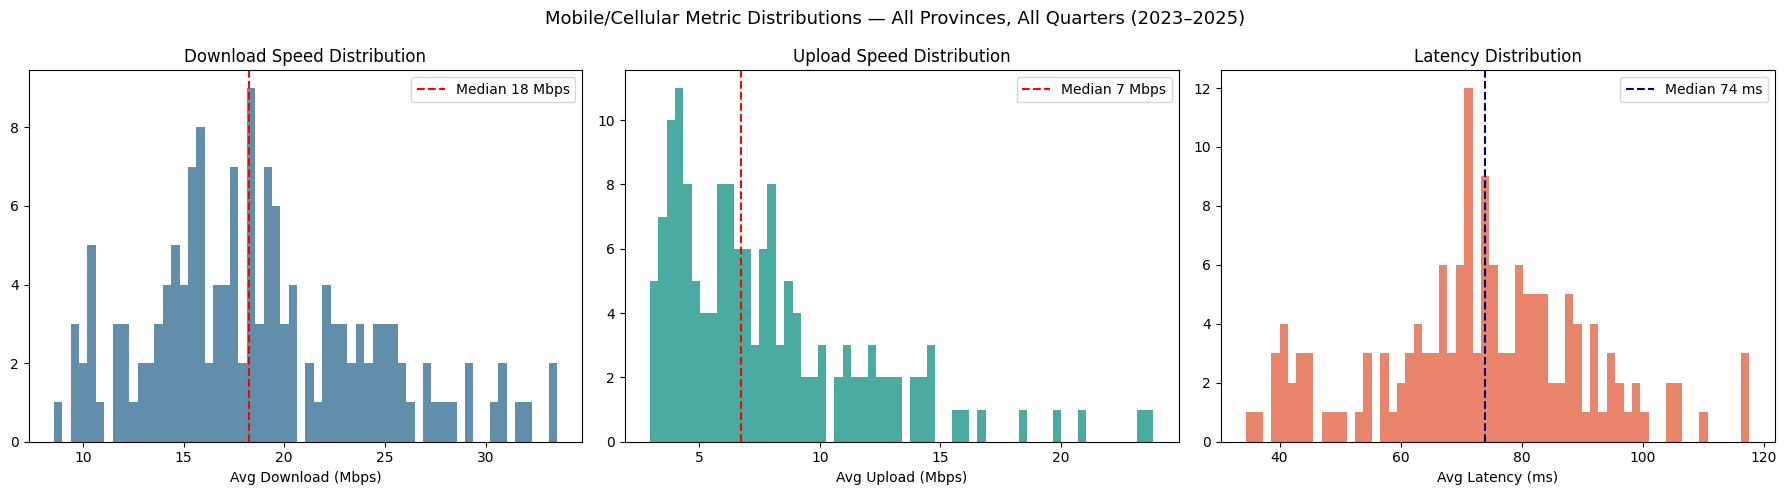

       avg_d_mbps  avg_u_mbps  avg_lat_ms_wt  total_tests
count      151.00      151.00         151.00       151.00
mean        18.82        7.84          73.38    269706.27
std          5.51        4.14          17.61    432366.32
min          8.55        2.96          34.47       120.00
25%         15.10        4.53          64.32     21654.00
50%         18.25        6.73          73.85    175867.00
75%         22.46        9.52          83.56    309560.00
max         33.56       23.83         117.59   2444704.00


In [33]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Mobile/Cellular — skipping speed-distribution plot.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].hist(master['avg_d_mbps'].dropna(), bins=60, color='#457b9d', edgecolor='none', alpha=0.85)
    axes[0].axvline(master['avg_d_mbps'].median(), color='red', ls='--', lw=1.5, label=f'Median {master["avg_d_mbps"].median():.0f} Mbps')
    axes[0].set_xlabel('Avg Download (Mbps)'); axes[0].set_title('Download Speed Distribution'); axes[0].legend()

    axes[1].hist(master['avg_u_mbps'].dropna(), bins=60, color='#2a9d8f', edgecolor='none', alpha=0.85)
    axes[1].axvline(master['avg_u_mbps'].median(), color='red', ls='--', lw=1.5, label=f'Median {master["avg_u_mbps"].median():.0f} Mbps')
    axes[1].set_xlabel('Avg Upload (Mbps)'); axes[1].set_title('Upload Speed Distribution'); axes[1].legend()

    axes[2].hist(master['avg_lat_ms_wt'].dropna(), bins=60, color='#e76f51', edgecolor='none', alpha=0.85)
    axes[2].axvline(master['avg_lat_ms_wt'].median(), color='navy', ls='--', lw=1.5, label=f'Median {master["avg_lat_ms_wt"].median():.0f} ms')
    axes[2].set_xlabel('Avg Latency (ms)'); axes[2].set_title('Latency Distribution'); axes[2].legend()

    plt.suptitle('Mobile/Cellular Metric Distributions — All Provinces, All Quarters (2023–2025)', fontsize=13)
    plt.tight_layout()

    plt.savefig('../../../outputs/ndt7/philippines/mobile/11_upload_speed_dist.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(master[['avg_d_mbps','avg_u_mbps','avg_lat_ms_wt','total_tests']].describe().round(2))

### 4. Province Ranking — Mean Download Speed (All Quarters)

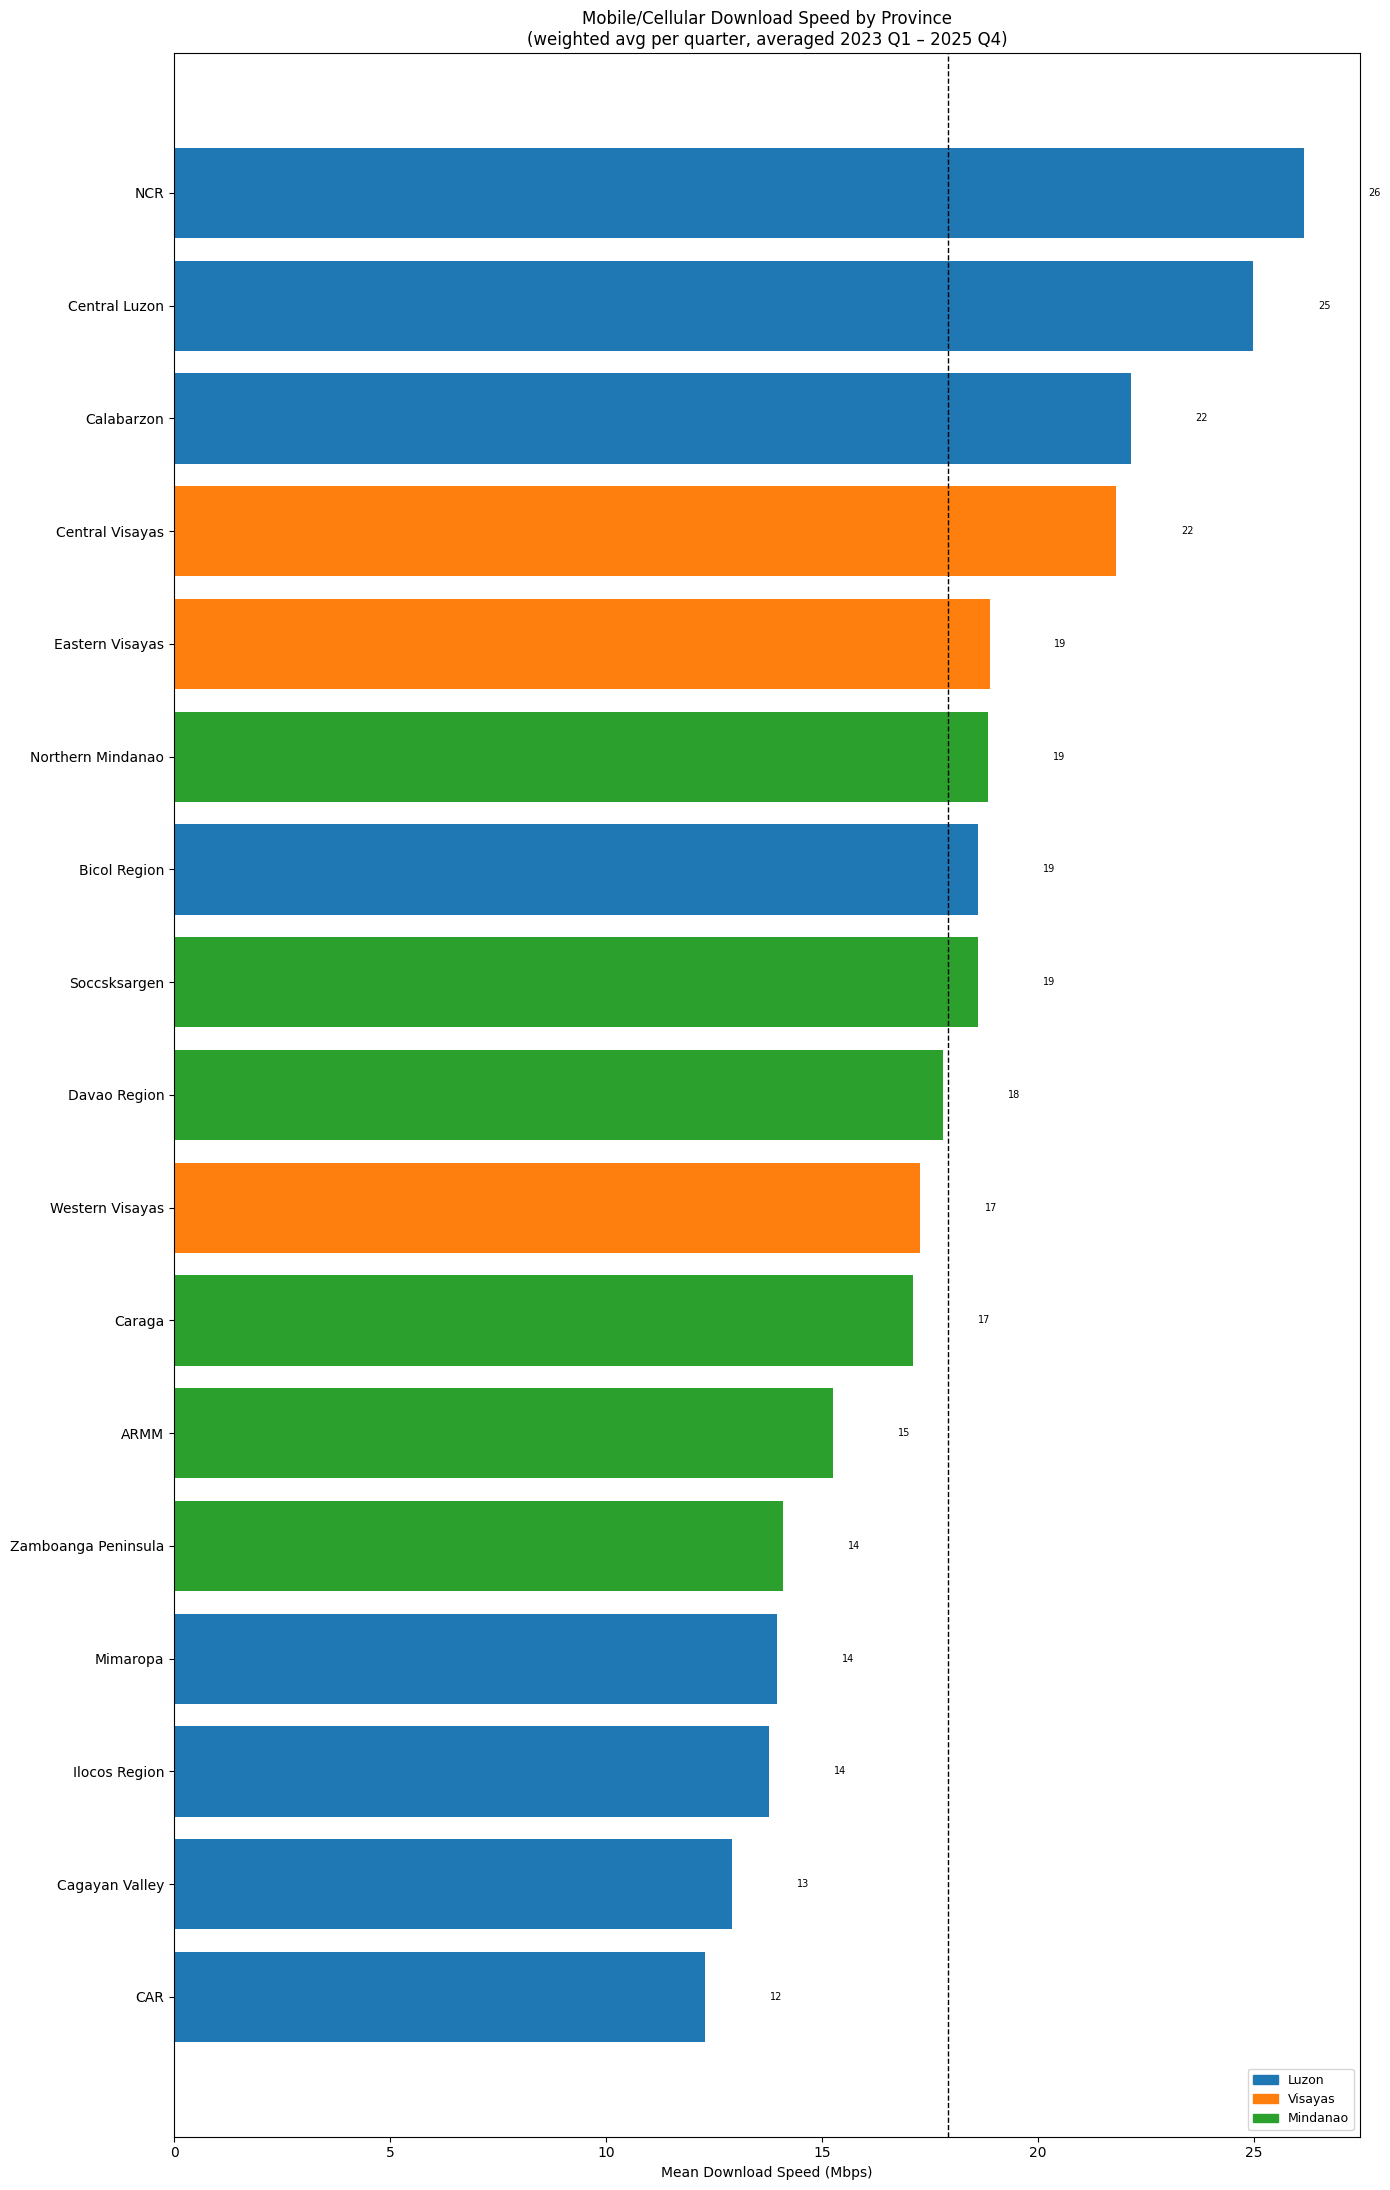

In [34]:
region_colors = {
    'Luzon': '#1f77b4',
    'Visayas': '#ff7f0e',
    'Mindanao': '#2ca02c',
}

if not HAS_RELIABLE_DATA:
    prov_mean = pd.DataFrame(columns=['name','region','mean_dl','mean_ul','mean_lat','mean_tests'])
    print("No reliable data for Mobile/Cellular — skipping province-ranking plot.")
else:
    prov_mean = (
        master.groupby(['name','region'])
        .agg(
            mean_dl=('avg_d_mbps','mean'),
            mean_ul=('avg_u_mbps','mean'),
            mean_lat=('avg_lat_ms_wt','mean'),
            mean_tests=('total_tests','mean'),
        )
        .reset_index()
        .sort_values('mean_dl', ascending=True)
    )

    fig, ax = plt.subplots(figsize=(14, 22))
    colors = [region_colors.get(r,'gray') for r in prov_mean['region']]
    bars = ax.barh(prov_mean['name'], prov_mean['mean_dl'], color=colors, edgecolor='none')
    for bar, val in zip(bars, prov_mean['mean_dl']):
        ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2, f'{val:.0f}', va='center', fontsize=7)
    ax.axvline(prov_mean['mean_dl'].mean(), color='black', ls='--', lw=1, label=f'National mean {prov_mean["mean_dl"].mean():.0f} Mbps')
    patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
    ax.legend(handles=patches, loc='lower right', fontsize=9)
    ax.set_xlabel('Mean Download Speed (Mbps)')
    ax.set_title('Mobile/Cellular Download Speed by Province\n(weighted avg per quarter, averaged 2023 Q1 – 2025 Q4)', fontsize=12)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/philippines/mobile/12_province_ranking_mean.png', dpi=150, bbox_inches='tight')
    plt.show()

### 5. Time Series — Download Speed Heatmap (Province × Quarter)

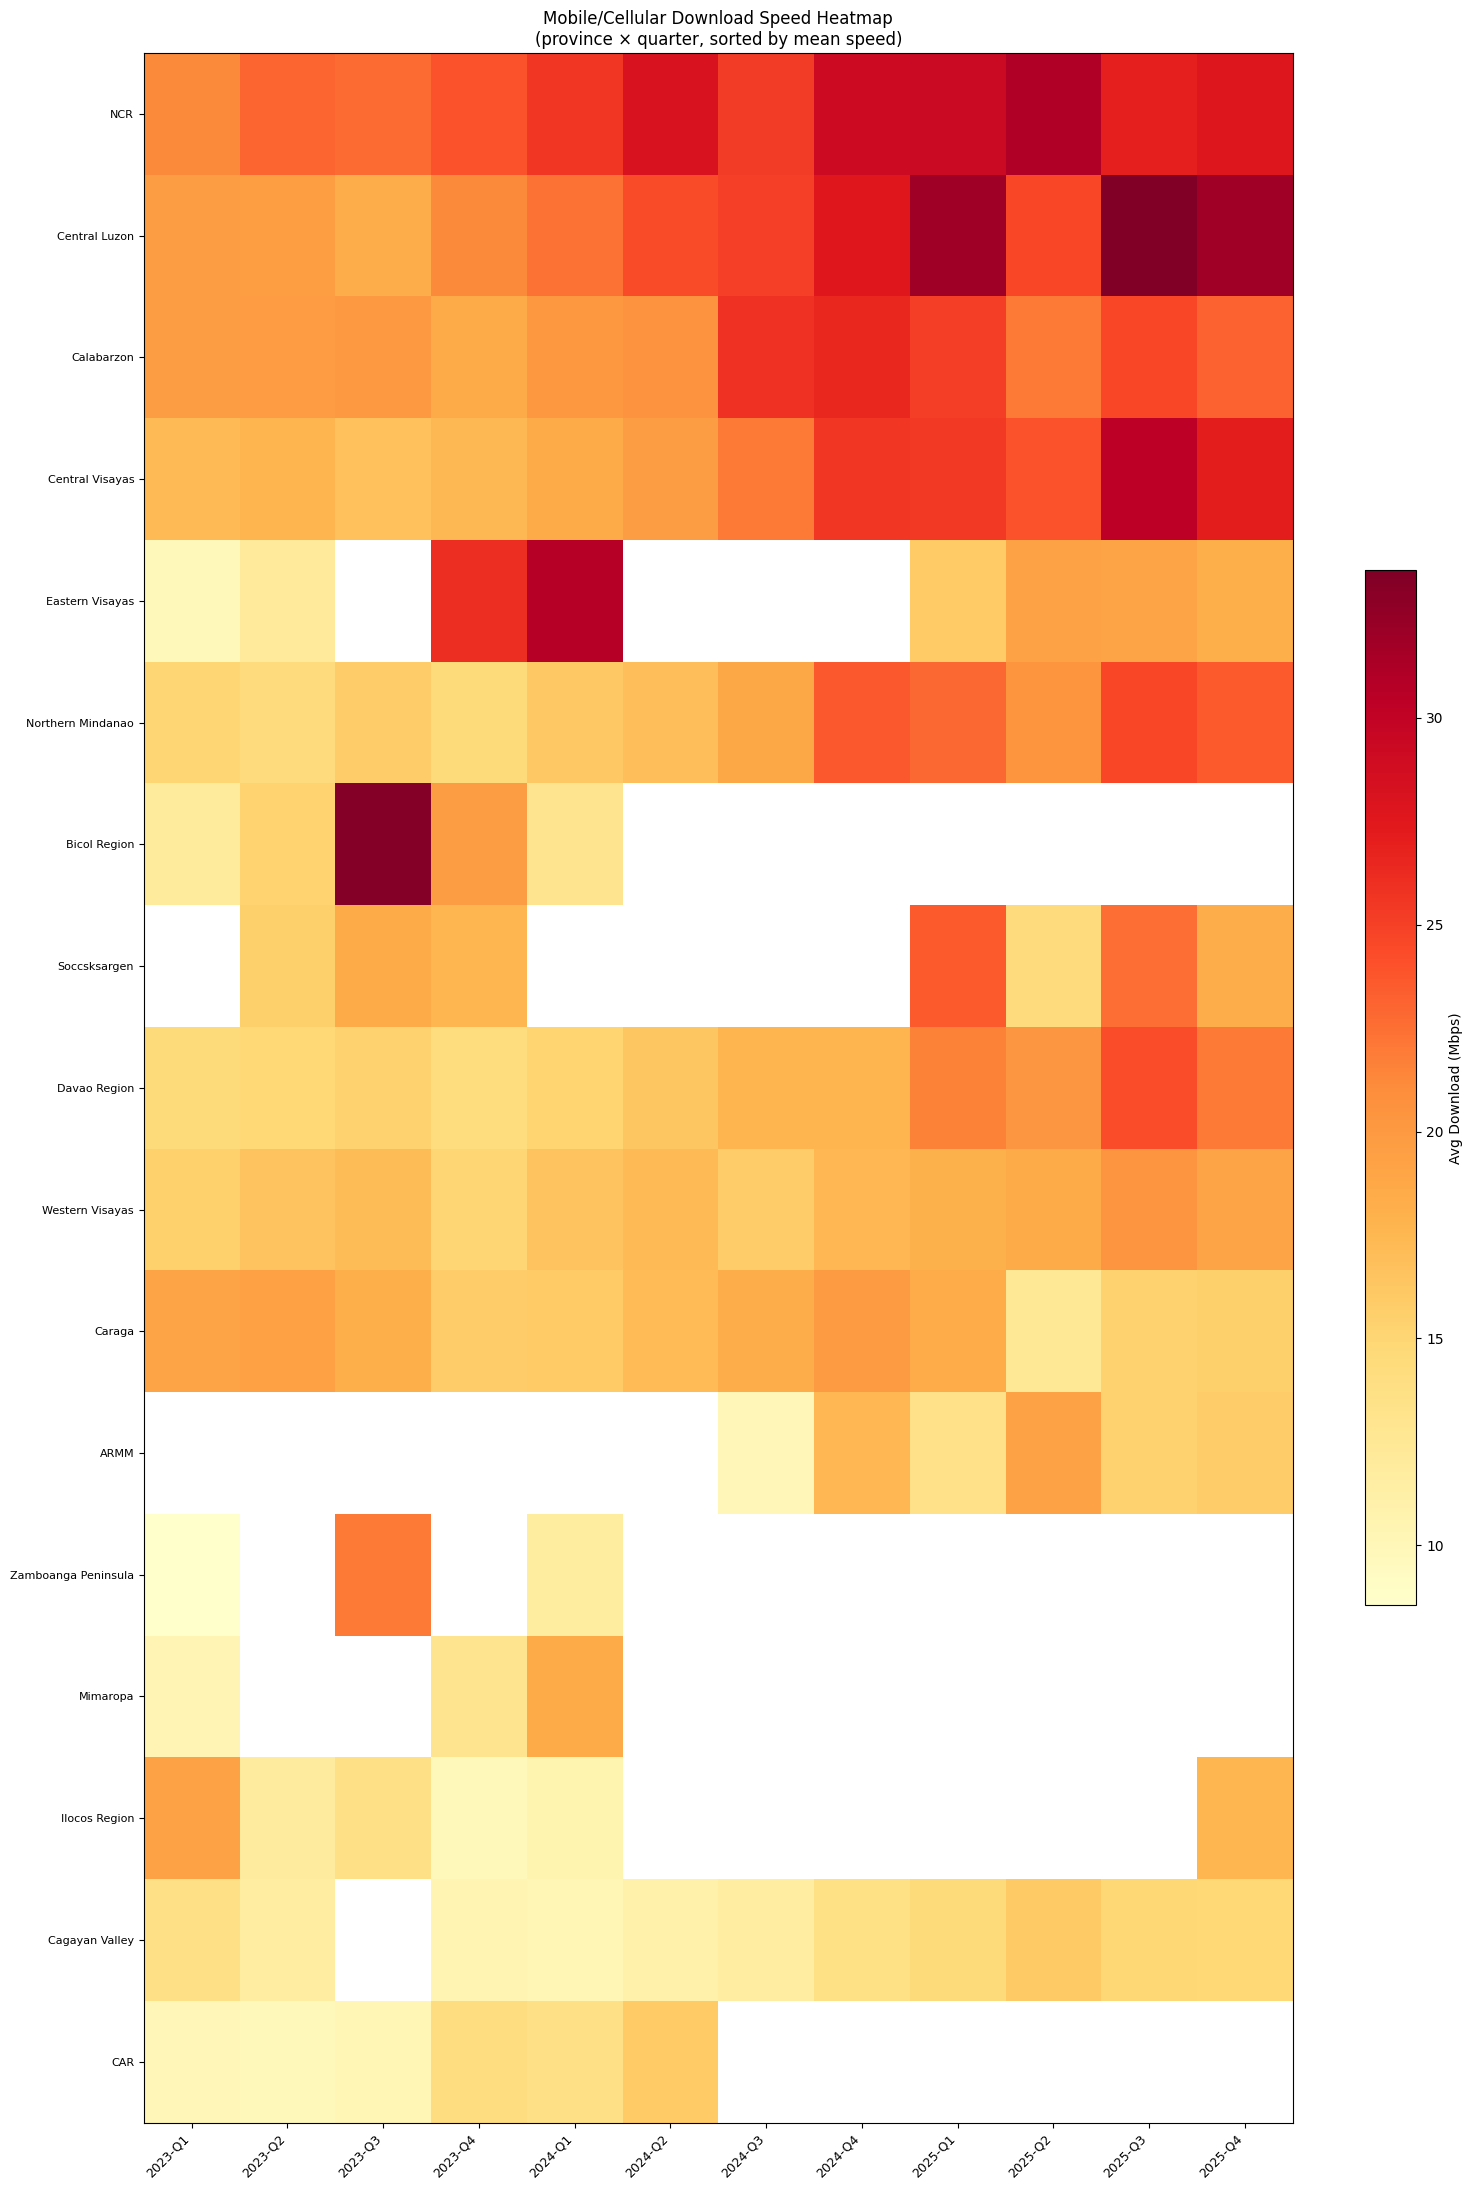

In [35]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Mobile/Cellular — skipping heatmap.")
else:
    pivot_dl = master.pivot_table(index='name', columns='period_start', values='avg_d_mbps')
    pivot_dl.columns = [pd.Timestamp(c).strftime('%Y-Q') + str((pd.Timestamp(c).month-1)//3+1) for c in pivot_dl.columns]
    pivot_dl = pivot_dl.loc[prov_mean.sort_values('mean_dl', ascending=False)['name']]

    fig, ax = plt.subplots(figsize=(16, 22))
    im = ax.imshow(pivot_dl.values, aspect='auto', cmap='YlOrRd', interpolation='nearest')
    plt.colorbar(im, ax=ax, label='Avg Download (Mbps)', shrink=0.5)
    ax.set_xticks(range(len(pivot_dl.columns)))
    ax.set_xticklabels(pivot_dl.columns, rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(len(pivot_dl.index)))
    ax.set_yticklabels(pivot_dl.index, fontsize=8)
    ax.set_title('Mobile/Cellular Download Speed Heatmap\n(province × quarter, sorted by mean speed)', fontsize=12)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/philippines/mobile/13_heatmap_quarterly.png', dpi=150, bbox_inches='tight')
    plt.show()

### 6. Regional Comparison — Download, Upload, Latency

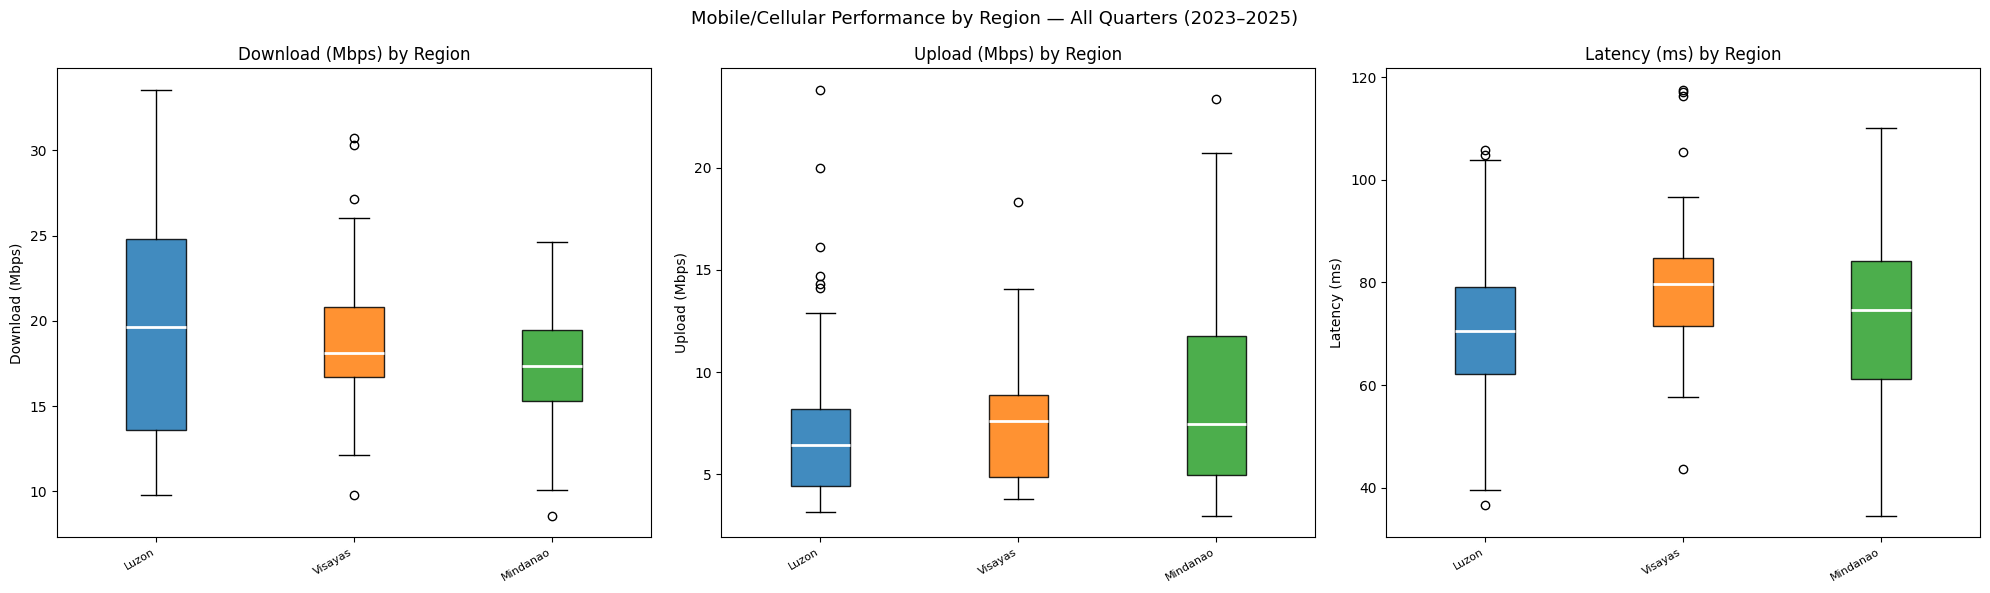

In [36]:
region_order = ['Luzon', 'Visayas', 'Mindanao']

if not HAS_RELIABLE_DATA:
    print("No reliable data for Mobile/Cellular — skipping regional boxplot.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    for ax, metric, label, color_key in [
        (axes[0], 'avg_d_mbps',   'Download (Mbps)', '#457b9d'),
        (axes[1], 'avg_u_mbps',   'Upload (Mbps)',   '#2a9d8f'),
        (axes[2], 'avg_lat_ms_wt','Latency (ms)',    '#e76f51'),
    ]:
        data = [master[master['region']==r][metric].dropna().values for r in region_order]
        bp = ax.boxplot(data, patch_artist=True, notch=False, medianprops=dict(color='white', linewidth=2))
        for patch, region in zip(bp['boxes'], region_order):
            patch.set_facecolor(region_colors[region])
            patch.set_alpha(0.85)
        ax.set_xticklabels(region_order, rotation=30, ha='right', fontsize=8)
        ax.set_ylabel(label)
        ax.set_title(f'{label} by Region')
    plt.suptitle('Mobile/Cellular Performance by Region — All Quarters (2023–2025)', fontsize=13)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/philippines/mobile/14_regional_boxplot.png', dpi=150, bbox_inches='tight')
    plt.show()

### 7. Download Speed Trend — Top, Bottom & Interesting Provinces

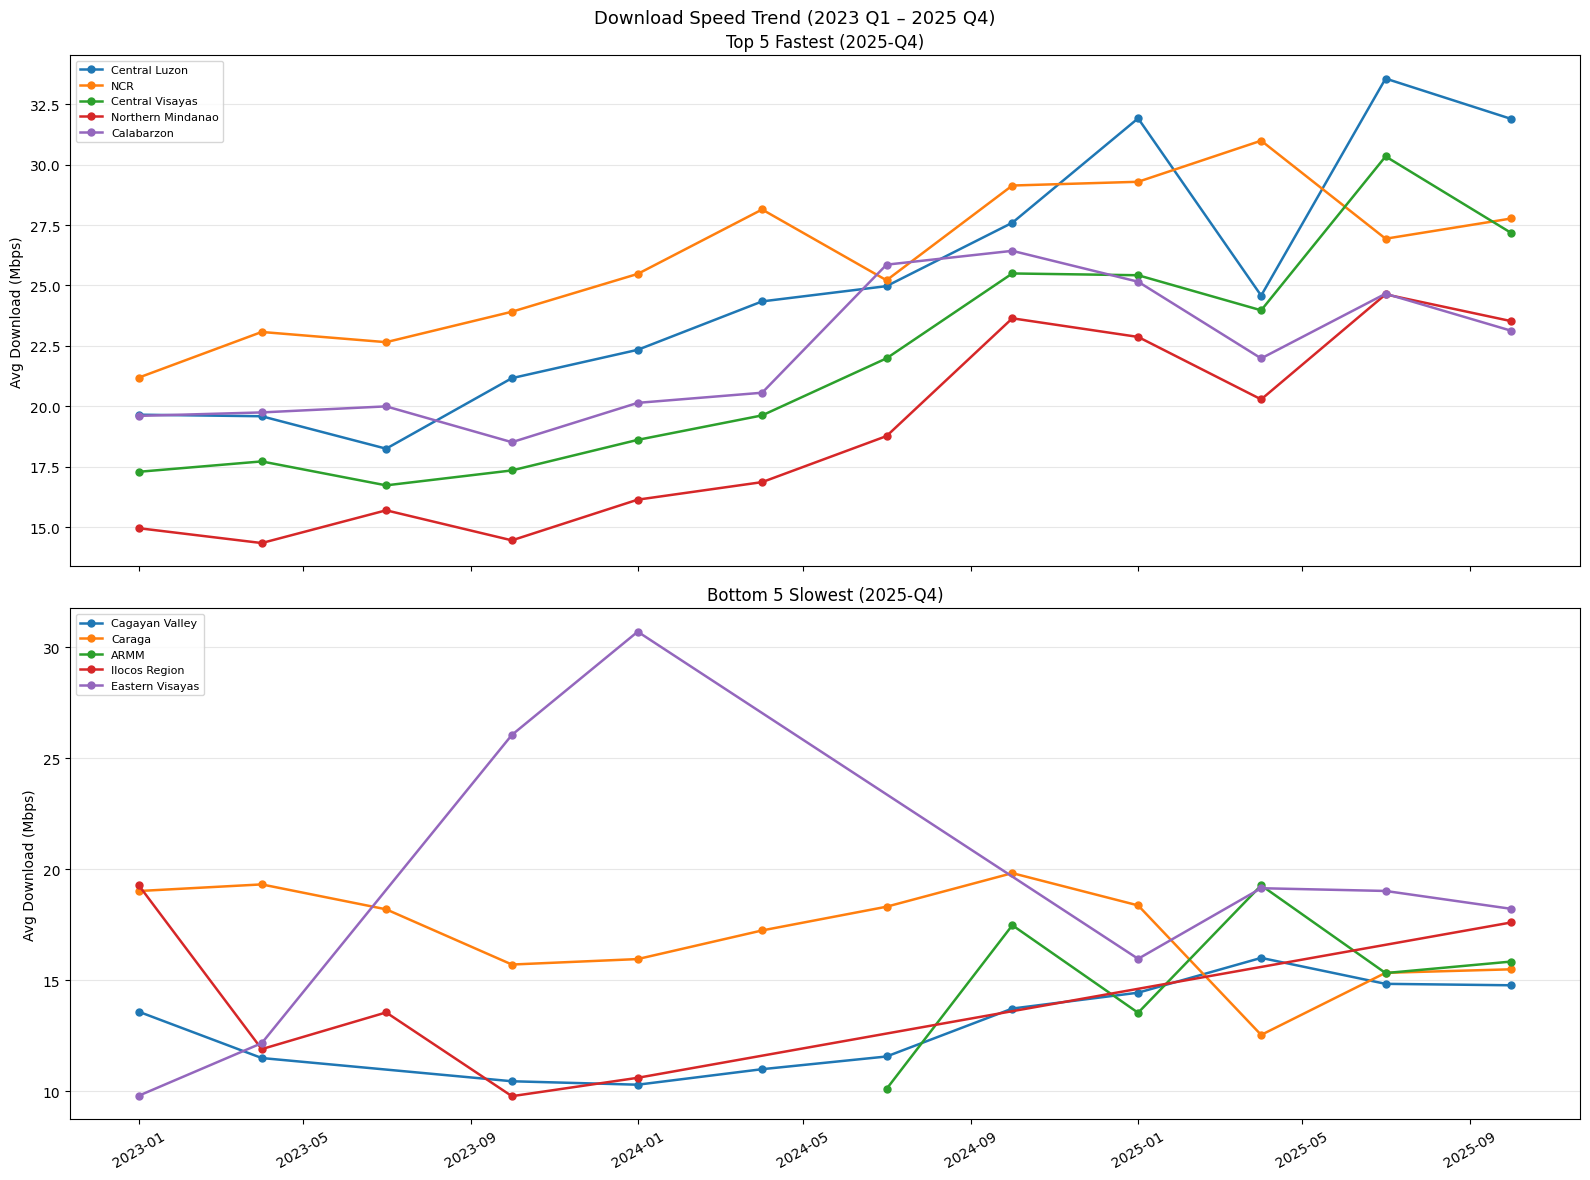

In [37]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Mobile/Cellular — skipping time-series trend plot.")
else:
    latest_q = master['label'].max()
    latest = master[master['label'] == latest_q]
    top5 = latest.nlargest(5, 'avg_d_mbps')['name'].tolist()
    bot5 = latest.nsmallest(5, 'avg_d_mbps')['name'].tolist()

    fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)
    groups = [
        (f'Top 5 Fastest ({latest_q})', top5, '#e63946'),
        (f'Bottom 5 Slowest ({latest_q})', bot5, '#6d6875'),
    ]
    for ax, (title, provinces, base_color) in zip(axes, groups):
        for prov in provinces:
            df_p = master[master['name']==prov].sort_values('label')
            if df_p.empty: continue
            ax.plot(df_p['period_start'], df_p['avg_d_mbps'], marker='o', markersize=5, label=prov, linewidth=1.8)
        ax.set_ylabel('Avg Download (Mbps)')
        ax.set_title(title)
        ax.legend(fontsize=8, loc='upper left')
        ax.grid(axis='y', alpha=0.3)
        ax.tick_params(axis='x', rotation=30)
    plt.suptitle('Download Speed Trend (2023 Q1 – 2025 Q4)', fontsize=13)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/philippines/mobile/15_time_series.png', dpi=150, bbox_inches='tight')
    plt.show()

### 8. GDP per Capita vs Download Speed — Does Money = Speed?

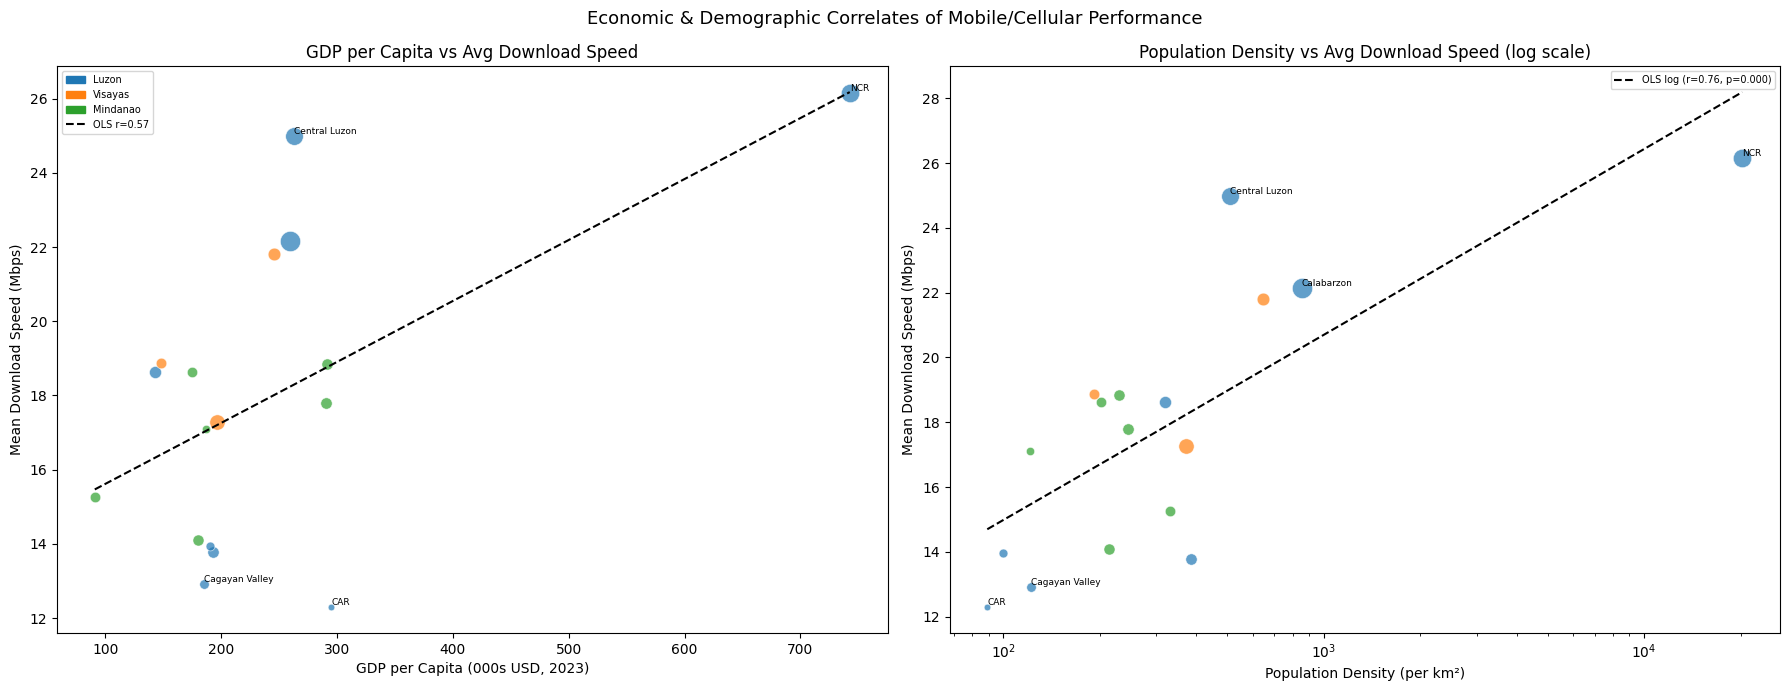

Pearson r (GDP vs download):     0.572  p=0.0164
Pearson r (log density vs download): 0.757  p=0.0004


In [38]:
if not HAS_RELIABLE_DATA:
    corr_df = pd.DataFrame(columns=['name','region','mean_dl','gdp_per_capita_thb_2021','internet_tier','pop_2024','density_per_km2'])
    r, p, r2, p2 = float('nan'), float('nan'), float('nan'), float('nan')
    print("No reliable data for Mobile/Cellular — skipping GDP/density correlation plot.")
else:
    corr_df = prov_mean.merge(
        prov_ref[['province_en','gdp_per_capita_thb_2021','internet_tier','pop_2024','density_per_km2']].rename(columns={'province_en':'name'}),
        on='name', how='left'
    )

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    for _, row in corr_df.iterrows():
        c = region_colors.get(row['region'], 'gray')
        axes[0].scatter(row['gdp_per_capita_thb_2021']/1000, row['mean_dl'],
                        color=c, s=row['pop_2024']/80000, alpha=0.7, edgecolors='white', lw=0.5)
        if row['gdp_per_capita_thb_2021'] > corr_df['gdp_per_capita_thb_2021'].quantile(0.9) or row['mean_dl'] > corr_df['mean_dl'].quantile(0.9) or row['mean_dl'] < corr_df['mean_dl'].quantile(0.1):
            axes[0].annotate(row['name'], (row['gdp_per_capita_thb_2021']/1000, row['mean_dl']), fontsize=6.5, ha='left', va='bottom')

    x = corr_df['gdp_per_capita_thb_2021'].dropna()/1000
    y = corr_df.loc[x.index,'mean_dl']
    if x.nunique() > 1:
        slope, intercept, r, p, _ = stats.linregress(x, y)
        xline = np.linspace(x.min(), x.max(), 100)
        axes[0].plot(xline, slope*xline+intercept, 'k--', lw=1.5, label=f'OLS (r={r:.2f}, p={p:.3f})')
        ols_handle = [plt.Line2D([0],[0],color='k',ls='--',label=f'OLS r={r:.2f}')]
    else:
        r, p = float('nan'), float('nan')
        axes[0].text(0.5, 0.05, 'GDP per capita uniform across regions — no regression', transform=axes[0].transAxes, ha='center', fontsize=8, style='italic')
        ols_handle = []
    axes[0].set_xlabel('GDP per Capita (000s USD, 2023)')
    axes[0].set_ylabel('Mean Download Speed (Mbps)')
    axes[0].set_title('GDP per Capita vs Avg Download Speed')
    patches = [mpatches.Patch(color=v, label=k) for k,v in region_colors.items()]
    axes[0].legend(handles=patches+ols_handle, fontsize=7)

    for _, row in corr_df.iterrows():
        c = region_colors.get(row['region'],'gray')
        axes[1].scatter(row['density_per_km2'], row['mean_dl'], color=c, s=row['pop_2024']/80000, alpha=0.7, edgecolors='white', lw=0.5)
        if row['density_per_km2'] > corr_df['density_per_km2'].quantile(0.9) or row['mean_dl'] > corr_df['mean_dl'].quantile(0.9) or row['mean_dl'] < corr_df['mean_dl'].quantile(0.1):
            axes[1].annotate(row['name'], (row['density_per_km2'], row['mean_dl']), fontsize=6.5, ha='left', va='bottom')

    x2 = corr_df['density_per_km2'].dropna()
    y2 = corr_df.loc[x2.index,'mean_dl']
    if x2.nunique() > 1:
        s2,i2,r2,p2,_ = stats.linregress(np.log1p(x2), y2)
        xline2 = np.linspace(x2.min(), x2.max(), 200)
        axes[1].plot(xline2, s2*np.log1p(xline2)+i2, 'k--', lw=1.5, label=f'OLS log (r={r2:.2f}, p={p2:.3f})')
    else:
        r2, p2 = float('nan'), float('nan')
    axes[1].set_xlabel('Population Density (per km²)')
    axes[1].set_xscale('log')
    axes[1].set_ylabel('Mean Download Speed (Mbps)')
    axes[1].set_title('Population Density vs Avg Download Speed (log scale)')
    axes[1].legend(fontsize=7)

    plt.suptitle('Economic & Demographic Correlates of Mobile/Cellular Performance', fontsize=13)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/philippines/mobile/16_gdp_speed_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Pearson r (GDP vs download):     {r:.3f}  p={p:.4f}")
    print(f"Pearson r (log density vs download): {r2:.3f}  p={p2:.4f}")

### 8.5 Multivariate Model — GDP + Density + Tier + Region Together

In [39]:
import statsmodels.formula.api as smf

if not HAS_RELIABLE_DATA or len(corr_df.dropna(subset=['mean_dl'])) < 5:
    print("No reliable data for Mobile/Cellular — skipping multivariate model (need >=5 observations to fit).")
else:
    model_df = corr_df.dropna(subset=['mean_dl', 'gdp_per_capita_thb_2021', 'density_per_km2', 'region', 'internet_tier']).copy()
    model_df['log_gdp'] = np.log(model_df['gdp_per_capita_thb_2021'])
    model_df['log_density'] = np.log1p(model_df['density_per_km2'])

    terms = []
    if model_df['log_gdp'].nunique() > 1:
        terms.append('log_gdp')
    if model_df['log_density'].nunique() > 1:
        terms.append('log_density')
    if model_df['internet_tier'].nunique() > 1:
        terms.append("C(internet_tier)")
    if model_df['region'].nunique() > 1:
        terms.append('C(region)')

    if not terms:
        print("No varying predictors — skipping multivariate model.")
    else:
        formula = 'mean_dl ~ ' + ' + '.join(terms)
        mv_model = smf.ols(formula, data=model_df).fit()
        print(mv_model.summary())
        print(f"\nMultivariate R\u00b2 = {mv_model.rsquared:.3f}  (bivariate GDP-only r\u00b2 = {r**2:.3f})")
        print(f"Adjusted R\u00b2 = {mv_model.rsquared_adj:.3f}")

                            OLS Regression Results                            
Dep. Variable:                mean_dl   R-squared:                       0.753
Model:                            OLS   Adj. R-squared:                  0.561
Method:                 Least Squares   F-statistic:                     3.925
Date:                Wed, 29 Jul 2026   Prob (F-statistic):             0.0305
Time:                        19:41:51   Log-Likelihood:                -35.600
No. Observations:                  17   AIC:                             87.20
Df Residuals:                       9   BIC:                             93.86
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept               -49.61

### 9. Upload/Download Ratio — Symmetry Check

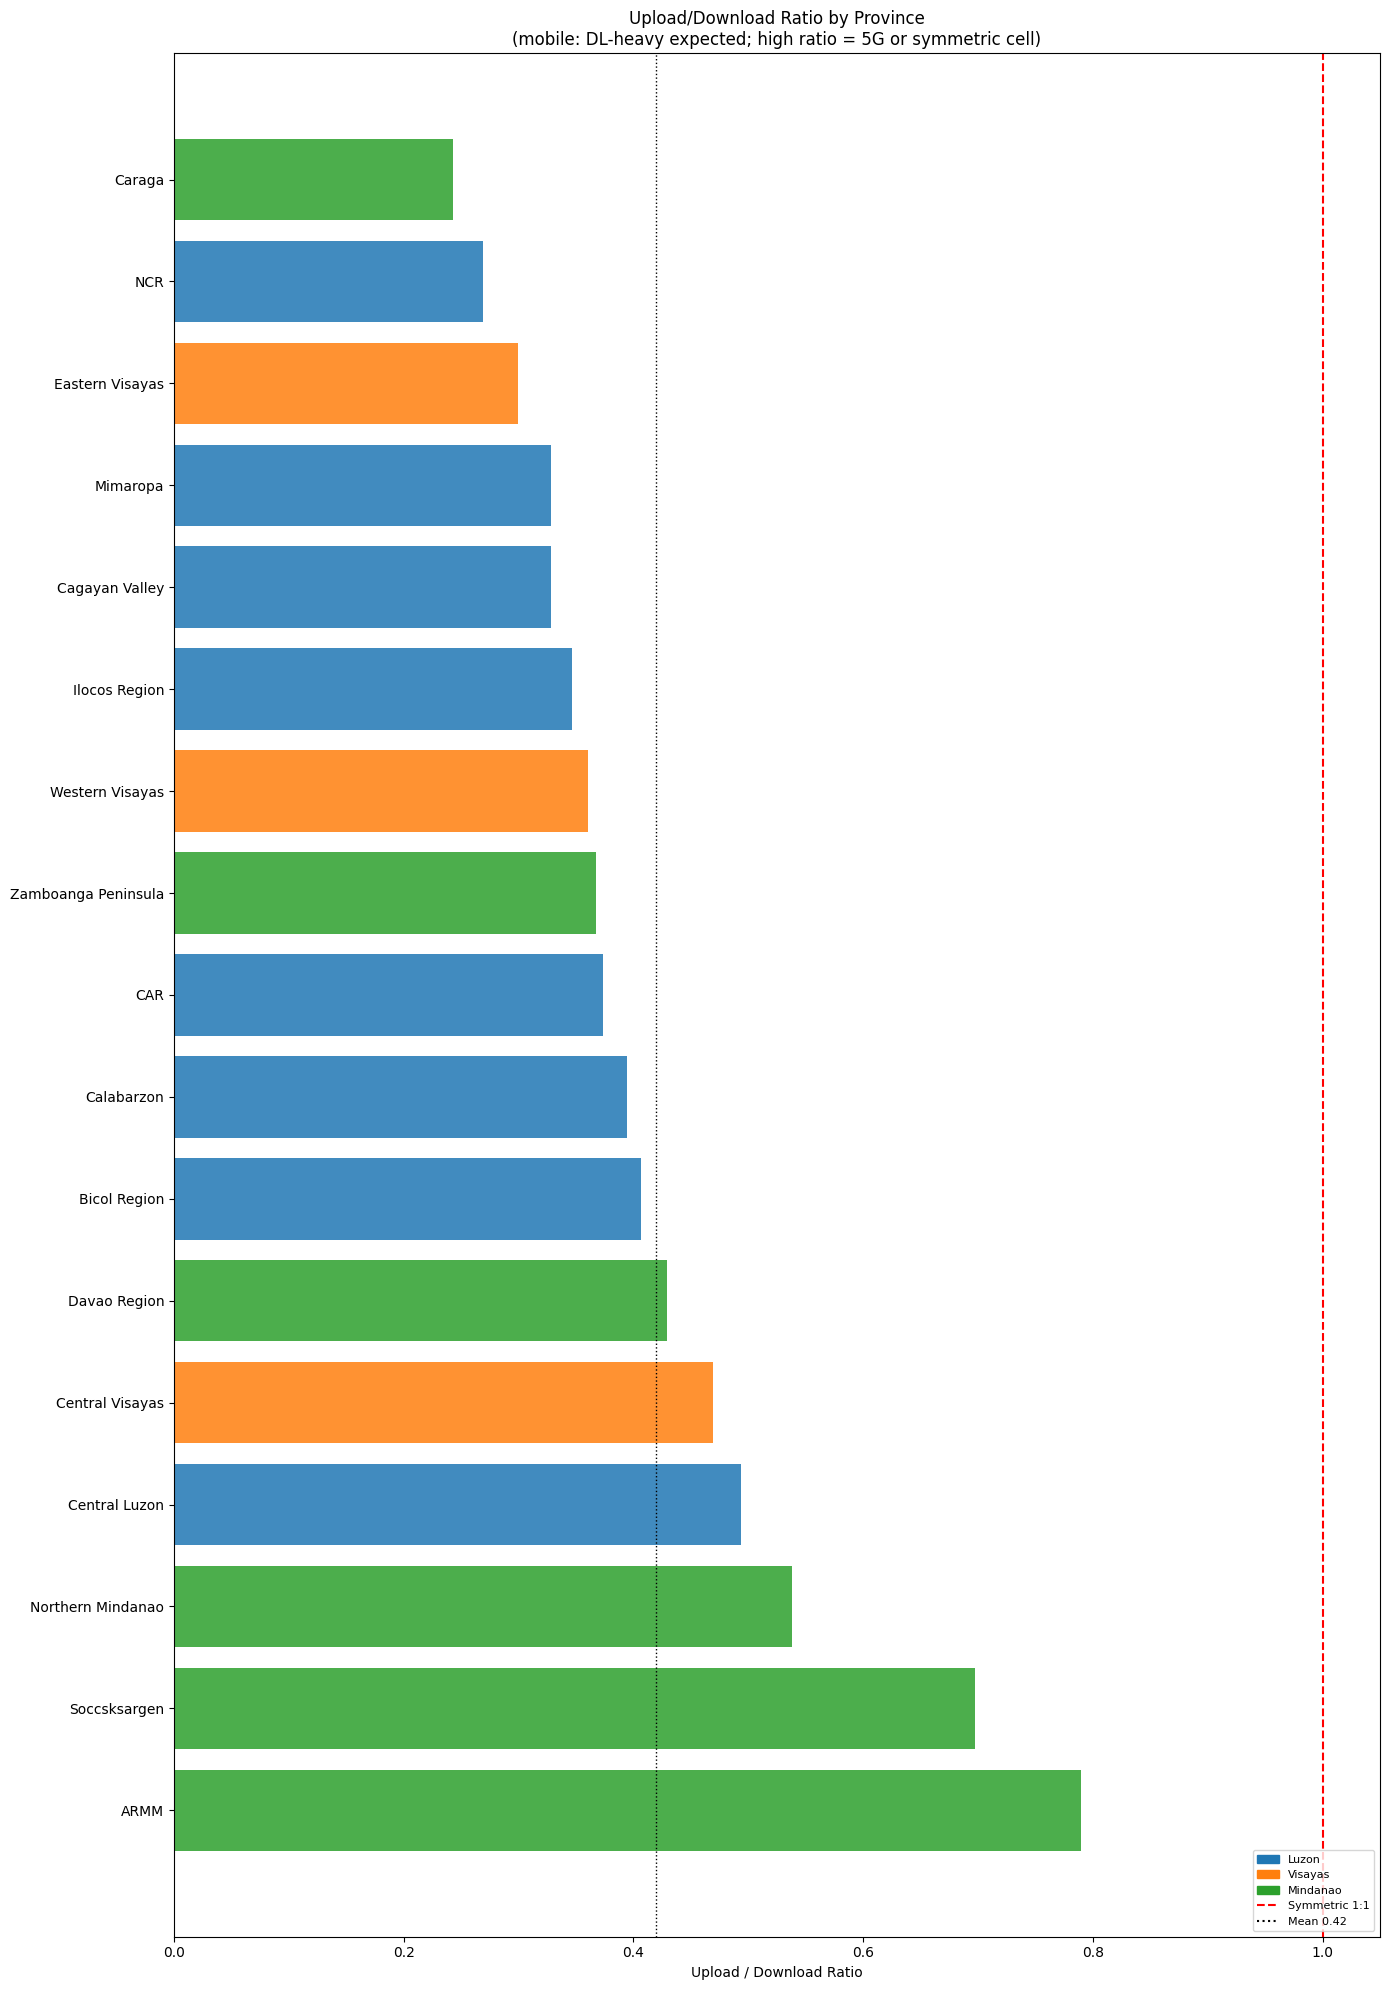

Provinces with UL/DL ratio > 0.5 (3):
             name   region  ul_dl_ratio
             ARMM Mindanao     0.789502
     Soccsksargen Mindanao     0.697398
Northern Mindanao Mindanao     0.538418


In [40]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Mobile/Cellular — skipping UL/DL ratio plot.")
else:
    master['ul_dl_ratio'] = master['avg_u_mbps'] / master['avg_d_mbps']
    ratio_mean = master.groupby('name')['ul_dl_ratio'].mean().sort_values(ascending=False).reset_index()
    ratio_mean = ratio_mean.merge(prov_ref[['province_en','region']].rename(columns={'province_en':'name'}), on='name', how='left')

    fig, ax = plt.subplots(figsize=(14, 20))
    colors = [region_colors.get(r,'gray') for r in ratio_mean['region']]
    ax.barh(ratio_mean['name'], ratio_mean['ul_dl_ratio'], color=colors, alpha=0.85)
    ax.axvline(1.0, color='red', ls='--', lw=1.5, label='Symmetric (1:1)')
    ax.axvline(ratio_mean['ul_dl_ratio'].mean(), color='black', ls=':', lw=1, label=f'Mean ratio {ratio_mean["ul_dl_ratio"].mean():.2f}')
    ax.set_xlabel('Upload / Download Ratio')
    ax.set_title('Upload/Download Ratio by Province\n(mobile: DL-heavy expected; high ratio = 5G or symmetric cell)')
    patches = [mpatches.Patch(color=v, label=k) for k,v in region_colors.items()]
    ax.legend(handles=patches+[
        plt.Line2D([0],[0],color='red',ls='--',label='Symmetric 1:1'),
        plt.Line2D([0],[0],color='black',ls=':',label=f'Mean {ratio_mean["ul_dl_ratio"].mean():.2f}')
    ], fontsize=8, loc='lower right')
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/philippines/mobile/17_uldl_ratio_bar.png', dpi=150, bbox_inches='tight')
    plt.show()

    divergent_ratio = ratio_mean[ratio_mean['ul_dl_ratio'] > 0.5]
    print(f"Provinces with UL/DL ratio > 0.5 ({len(divergent_ratio)}):")
    print(divergent_ratio[['name','region','ul_dl_ratio']].to_string(index=False))

### 10. Province Summary — Tier & UL/DL Ratio

In [41]:
from scipy import stats
import numpy as np

if not HAS_RELIABLE_DATA:
    high_ratio = pd.Series(dtype=float)
    prov_mean = pd.DataFrame(columns=['name','region','mean_dl','mean_ul','mean_lat','mean_tests','mean_ratio','tier'])
    print("No reliable data for Mobile/Cellular — skipping province summary.")
else:
    master['ul_dl_ratio'] = master['avg_u_mbps'] / master['avg_d_mbps']
    high_ratio = master.groupby('name')['ul_dl_ratio'].mean()

    prov_mean = (
        master.groupby(['name','region'])
        .agg(
            mean_dl=('avg_d_mbps','mean'),
            mean_ul=('avg_u_mbps','mean'),
            mean_lat=('avg_lat_ms_wt','mean'),
            mean_tests=('total_tests','mean'),
            mean_ratio=('ul_dl_ratio','mean'),
        )
        .reset_index()
        .sort_values('mean_dl', ascending=False)
    )
    prov_mean['tier'] = prov_mean['name'].map(prov_ref.set_index('province_en')['internet_tier'].to_dict())

### 12. Full Province Summary Table

In [42]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Mobile/Cellular — nothing to summarize.")
else:
    summary = prov_mean.merge(
        prov_ref[['province_en','pop_2024','gdp_per_capita_thb_2021','internet_tier']].rename(columns={'province_en':'name'}),
        on='name', how='left'
    ).copy()
    summary['ul_dl_ratio'] = summary['name'].map(high_ratio).round(3)
    summary = summary.sort_values('mean_dl', ascending=False).round(2)
    print(summary[[
        'name','region','internet_tier','mean_dl','mean_ul','mean_lat','ul_dl_ratio','mean_tests','gdp_per_capita_thb_2021'
    ]].to_string(index=False))

               name   region  internet_tier  mean_dl  mean_ul  mean_lat  ul_dl_ratio  mean_tests  gdp_per_capita_thb_2021
                NCR    Luzon              1    26.15     7.02     69.13         0.27  1530648.42                742614.53
      Central Luzon    Luzon              2    24.99    12.75     54.47         0.49   292385.17                263326.87
         Calabarzon    Luzon              2    22.15     8.85     57.51         0.39   366078.92                259765.51
    Central Visayas  Visayas              2    21.81    10.36     75.61         0.47   324752.08                245591.30
    Eastern Visayas  Visayas              4    18.88     5.15     90.86         0.30    12614.75                147867.62
  Northern Mindanao Mindanao              1    18.85    10.36     77.13         0.54   217387.92                291746.51
       Bicol Region    Luzon              4    18.62     7.72     73.59         0.41    25052.00                142596.80
       Soccsksargen Mind

### 13. UL/DL Symmetry — Fiber Penetration Evidence

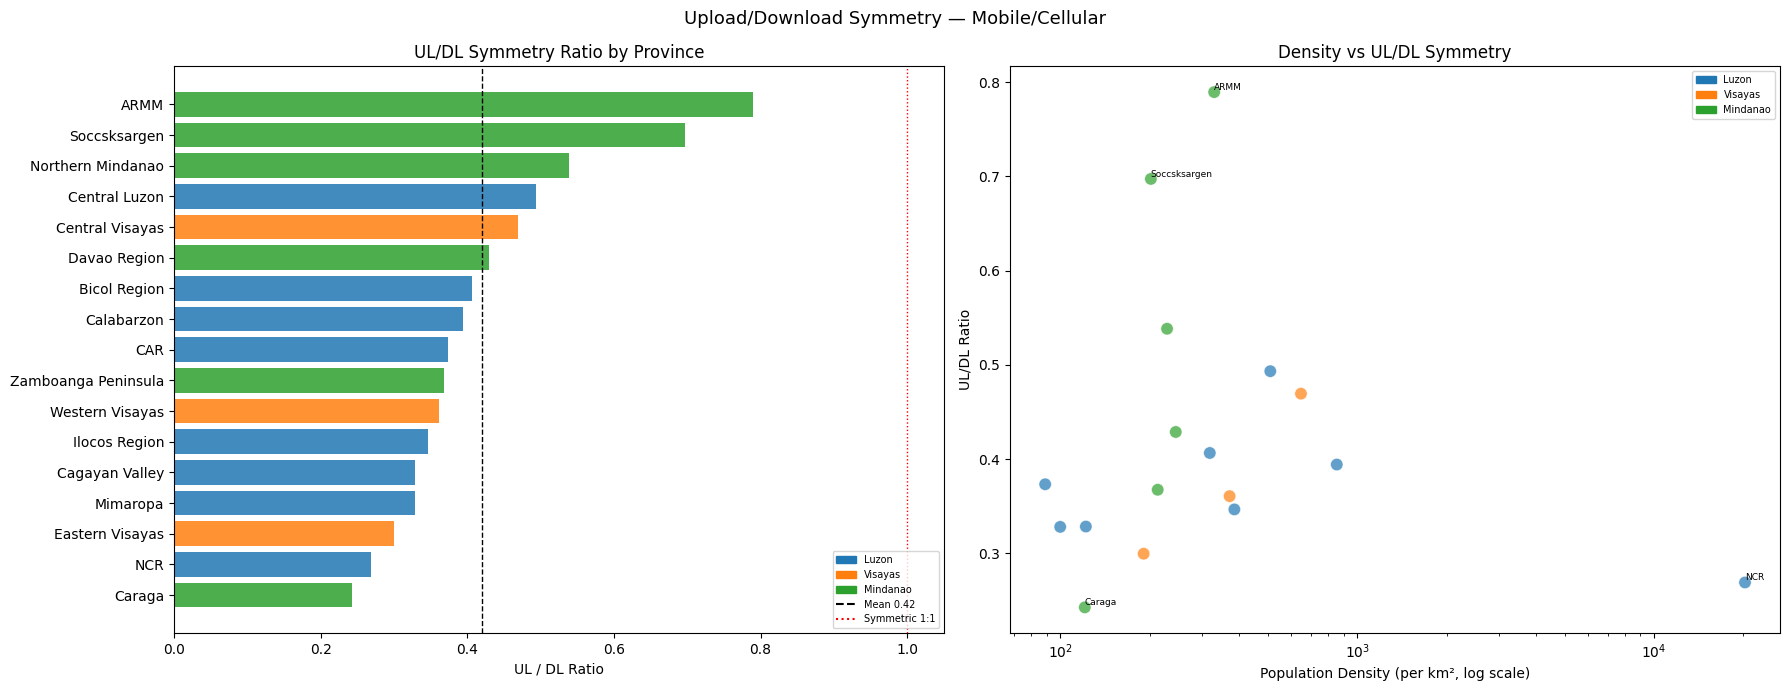

In [43]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Mobile/Cellular — skipping UL/DL symmetry deep-dive.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    ratio_sorted = prov_mean.sort_values('mean_ratio', ascending=True)
    colors = [region_colors.get(r,'gray') for r in ratio_sorted['region']]
    axes[0].barh(ratio_sorted['name'], ratio_sorted['mean_ratio'], color=colors, alpha=0.85)
    axes[0].axvline(prov_mean['mean_ratio'].mean(), color='black', ls='--', lw=1, label=f"National mean {prov_mean['mean_ratio'].mean():.2f}")
    axes[0].axvline(1.0, color='red', ls=':', lw=1, label='Symmetric 1:1')
    axes[0].set_xlabel('UL / DL Ratio')
    axes[0].set_title('UL/DL Symmetry Ratio by Province')
    patches = [mpatches.Patch(color=v,label=k) for k,v in region_colors.items()]
    axes[0].legend(handles=patches + [
        plt.Line2D([0],[0],color='black',ls='--',label=f"Mean {prov_mean['mean_ratio'].mean():.2f}"),
        plt.Line2D([0],[0],color='red',ls=':',label='Symmetric 1:1'),
    ], fontsize=7, loc='lower right')

    axes[1].scatter(prov_ref.set_index('province_en').loc[prov_mean['name'],'density_per_km2'].values,
                    prov_mean['mean_ratio'].values,
                    c=[region_colors.get(r,'gray') for r in prov_mean['region']],
                    s=80, alpha=0.7, edgecolors='white', lw=0.5)
    for _, row in prov_mean.iterrows():
        if row['mean_ratio'] > prov_mean['mean_ratio'].quantile(0.9) or row['mean_ratio'] < prov_mean['mean_ratio'].quantile(0.1):
            density = prov_ref.loc[prov_ref['province_en']==row['name'],'density_per_km2'].values
            if len(density):
                axes[1].annotate(row['name'], (density[0], row['mean_ratio']), fontsize=6.5, ha='left', va='bottom')
    axes[1].set_xscale('log')
    axes[1].set_xlabel('Population Density (per km², log scale)')
    axes[1].set_ylabel('UL/DL Ratio')
    axes[1].set_title('Density vs UL/DL Symmetry')
    axes[1].legend(handles=patches, fontsize=7)

    plt.suptitle('Upload/Download Symmetry — Mobile/Cellular', fontsize=13)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/philippines/mobile/19_uldl_symmetry_ratio.png', dpi=150, bbox_inches='tight')
    plt.show()

### 14. Temporal: Speed Growth 2023 Q1 → 2025 Q4

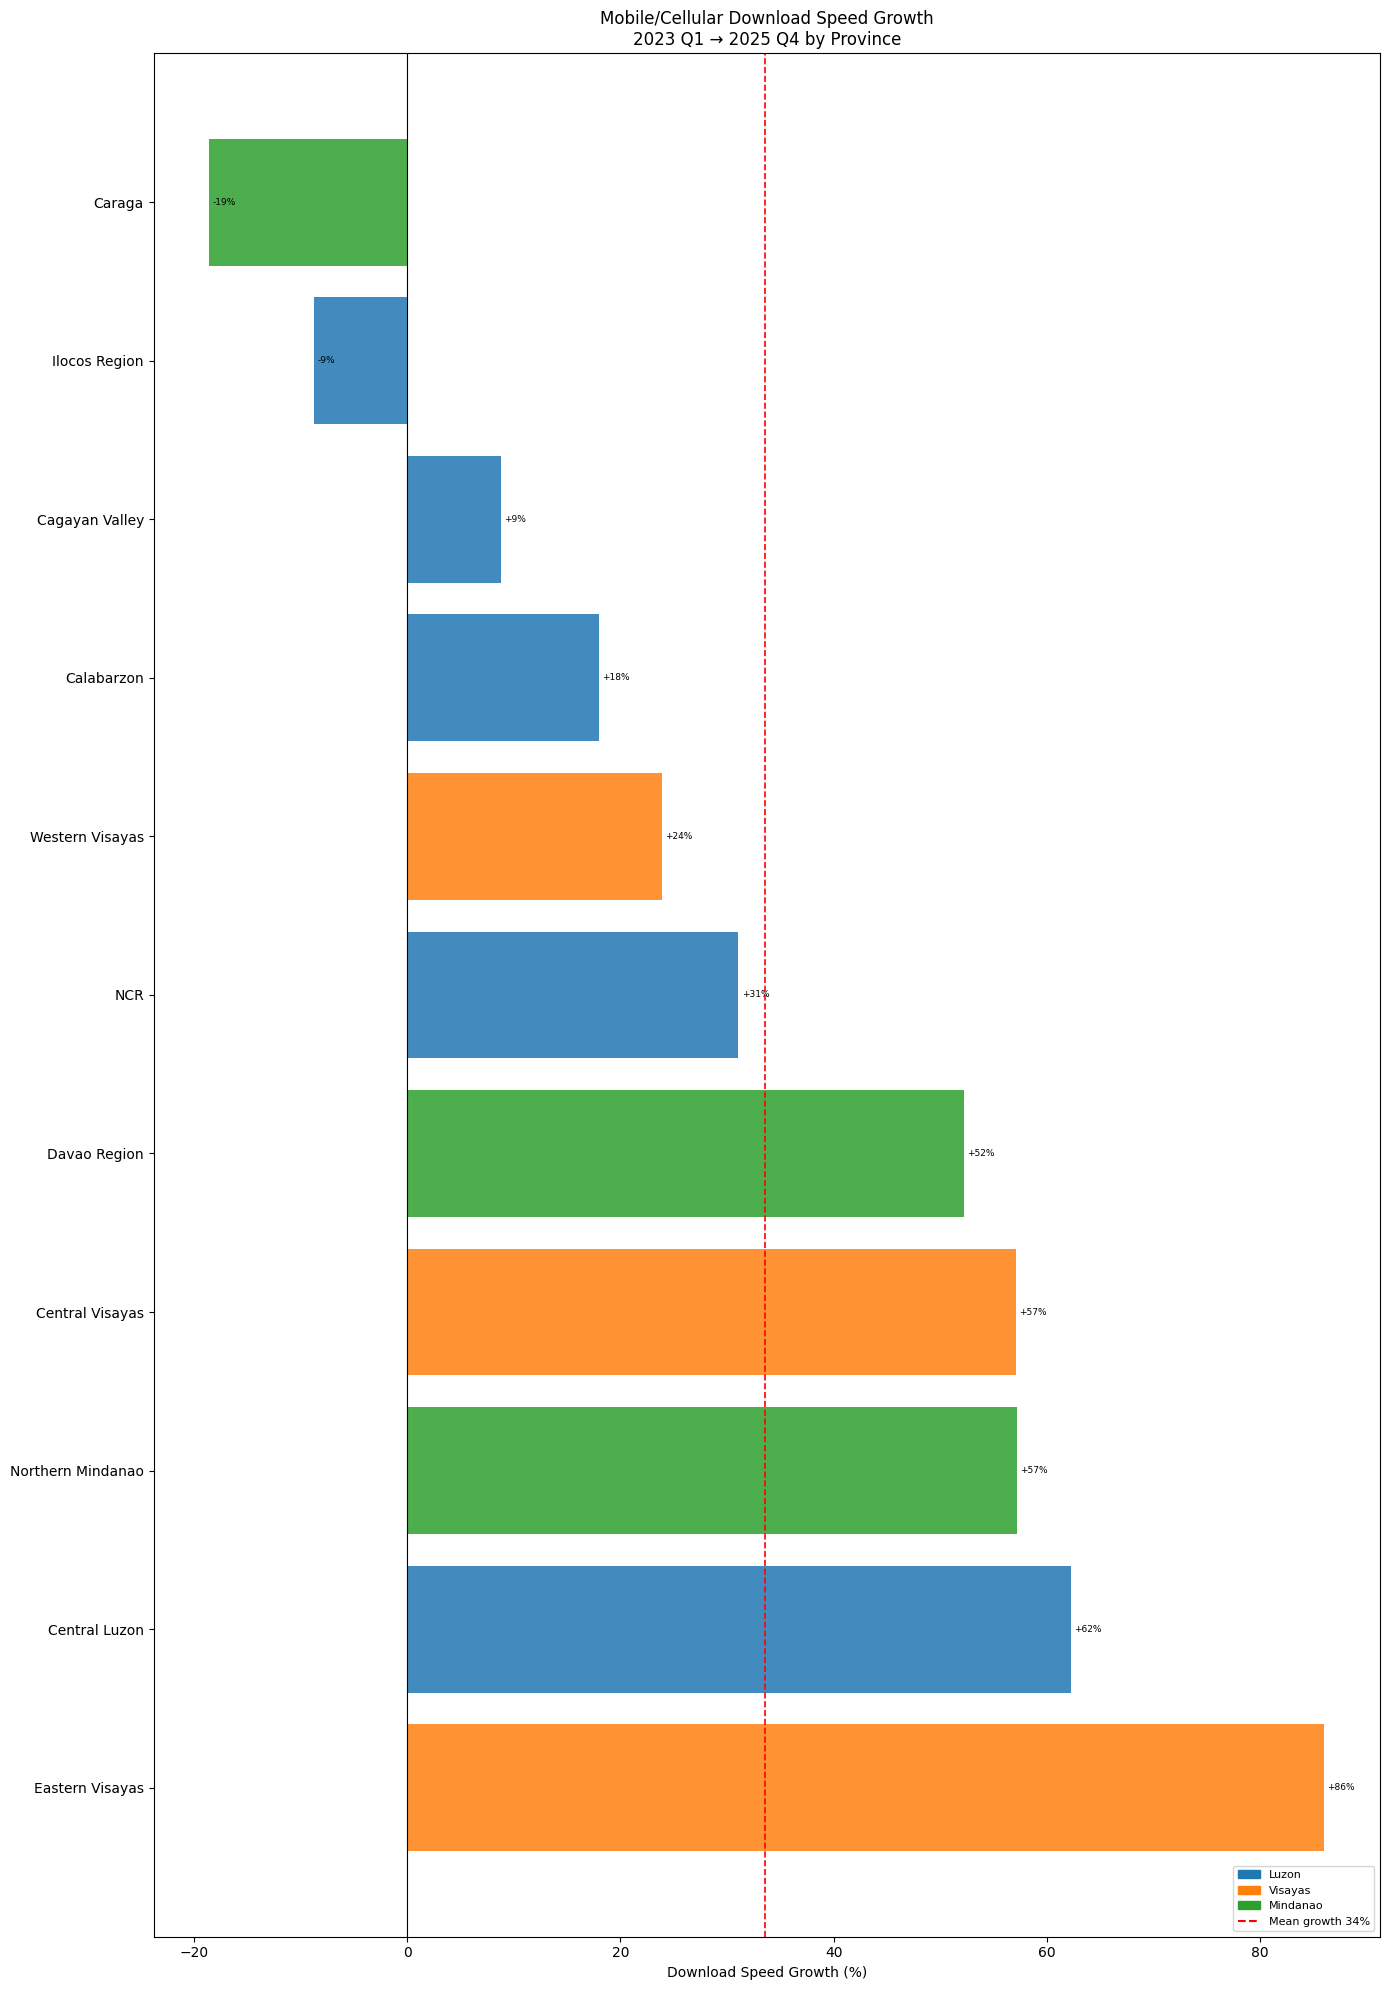

In [44]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Mobile/Cellular — skipping temporal growth plot.")
else:
    first = master[master['label']=='2023-Q1'].set_index('name')['avg_d_mbps']
    last  = master[master['label']=='2025-Q4'].set_index('name')['avg_d_mbps']
    growth = ((last - first) / first * 100).dropna().sort_values(ascending=False)

    if growth.empty:
        print("No province has both a 2023-Q1 and 2025-Q4 reliable observation — skipping growth plot.")
    else:
        growth_df = growth.reset_index()
        growth_df.columns = ['name','pct_growth']
        growth_df = growth_df.merge(prov_ref[['province_en','region','internet_tier']].rename(columns={'province_en':'name'}), on='name', how='left')

        fig, ax = plt.subplots(figsize=(14, 20))
        colors = [region_colors.get(r,'gray') for r in growth_df['region']]
        bars = ax.barh(growth_df['name'], growth_df['pct_growth'], color=colors, alpha=0.85)
        ax.axvline(0, color='black', lw=0.8)
        ax.axvline(growth_df['pct_growth'].mean(), color='red', ls='--', lw=1.2, label=f"Mean growth {growth_df['pct_growth'].mean():.0f}%")
        for bar, val in zip(bars, growth_df['pct_growth']):
            ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, f'{val:+.0f}%', va='center', fontsize=6.5)
        patches = [mpatches.Patch(color=v,label=k) for k,v in region_colors.items()]
        ax.legend(handles=patches+[plt.Line2D([0],[0],color='red',ls='--',label=f"Mean growth {growth_df['pct_growth'].mean():.0f}%")], fontsize=8, loc='lower right')
        ax.set_xlabel('Download Speed Growth (%)')
        ax.set_title('Mobile/Cellular Download Speed Growth\n2023 Q1 → 2025 Q4 by Province', fontsize=12)
        plt.tight_layout()
        plt.savefig('../../../outputs/ndt7/philippines/mobile/20_growth.png', dpi=150, bbox_inches='tight')
        plt.show()

### 15. Regional Growth Index — Trajectory Shape (Normalized to First Reliable Quarter = 100)
Complements the endpoint-only growth chart above (Q1 &#8594; Q4 % change) by showing the full trajectory per region, each region's own first valid quarter rebased to 100. Regions need at least half the available quarters with reliable data to be plotted, so noisy short-history regions are dropped instead of shown misleadingly. Rolled up from province to region level — adapted from the Myanmar/Laos NDT7 notebooks' growth-index cell, which plots at province level directly since those countries have far fewer top-level admin units than the province counts tracked here.


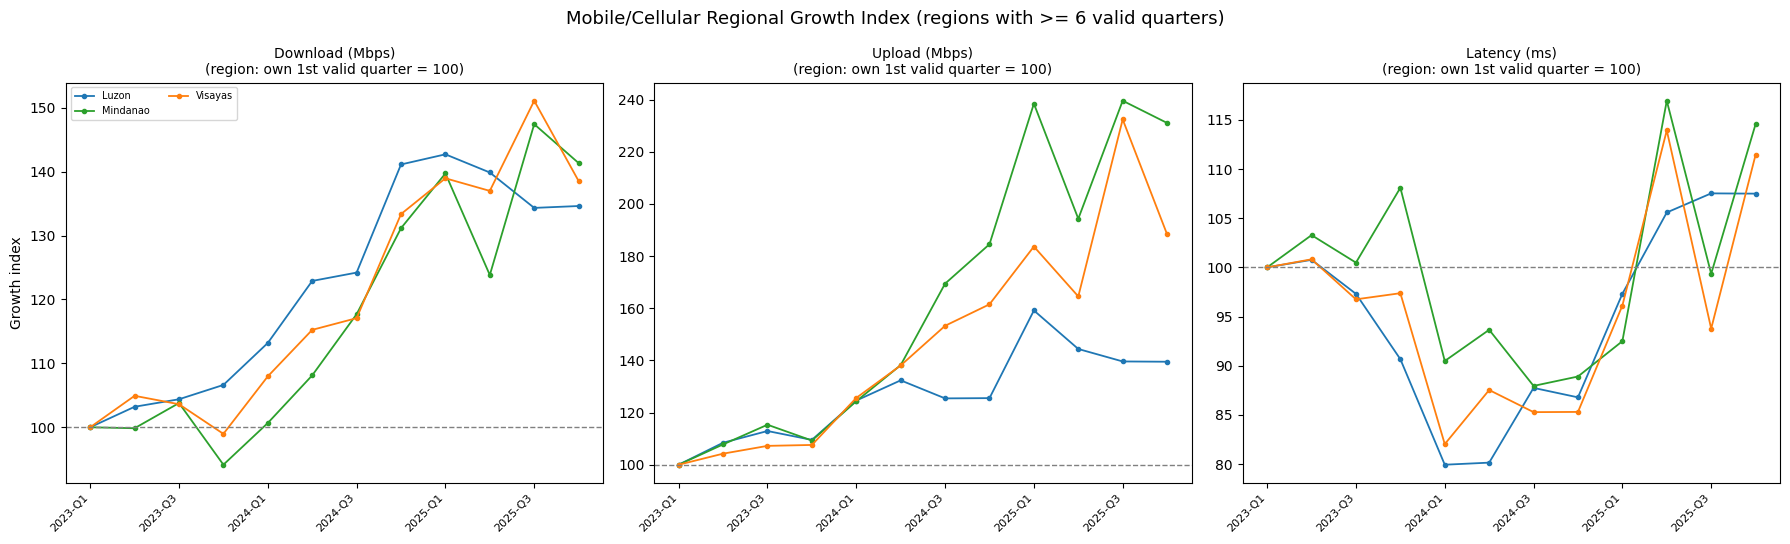

In [45]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Mobile/Cellular — skipping regional growth-index plot.")
else:
    quarter_order = sorted(master['label'].unique())
    MIN_Q = max(3, len(quarter_order) // 2)

    region_q = (
        master.groupby(['region', 'label'])
        .apply(lambda g: pd.Series({
            'avg_d_mbps': np.average(g['avg_d_mbps'], weights=g['total_tests']),
            'avg_u_mbps': np.average(g['avg_u_mbps'], weights=g['total_tests']),
            'avg_lat_ms_wt': np.average(g['avg_lat_ms_wt'], weights=g['total_tests']),
        }), include_groups=False)
        .reset_index()
    )

    metrics = [('avg_d_mbps', 'Download (Mbps)'), ('avg_u_mbps', 'Upload (Mbps)'), ('avg_lat_ms_wt', 'Latency (ms)')]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
    any_plotted = False
    for ax, (col, label) in zip(axes, metrics):
        piv = region_q.pivot(index='region', columns='label', values=col).reindex(columns=quarter_order)
        valid = piv.notna().sum(axis=1)
        keep = valid[valid >= MIN_Q].index.tolist()
        if not keep:
            ax.text(0.5, 0.5, 'not enough data', transform=ax.transAxes, ha='center')
            continue
        for reg in keep:
            s = piv.loc[reg].dropna()
            xs = [quarter_order.index(q) for q in s.index]
            ax.plot(xs, s.values / s.iloc[0] * 100, marker='o', ms=3, lw=1.3,
                    color=region_colors.get(reg, 'gray'), label=reg)
            any_plotted = True
        ax.axhline(100, color='grey', ls='--', lw=1)
        step = max(1, len(quarter_order) // 6)
        ax.set_xticks(range(0, len(quarter_order), step))
        ax.set_xticklabels([quarter_order[i] for i in range(0, len(quarter_order), step)], rotation=45, ha='right', fontsize=8)
        ax.set_title(f'{label}\n(region: own 1st valid quarter = 100)', fontsize=10)
    axes[0].set_ylabel('Growth index')
    if any_plotted:
        axes[0].legend(fontsize=7, ncol=2, loc='upper left')
    plt.suptitle(f'Mobile/Cellular Regional Growth Index (regions with >= {MIN_Q} valid quarters)', fontsize=13)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/philippines/mobile/21_growth_index_regional.png', dpi=150, bbox_inches='tight')
    plt.show()


### 15.5 Measured Speed Choropleth — Actual NDT7 Download Speed by Province
The "Internet Tier" map earlier in this notebook is a GDP-based *expectation*. This map is the actual measured NDT7 average, on the same province geometry, so the two can be compared directly. Adapted from the Myanmar/Laos NDT7 notebooks' choropleth cell (re-based here on `master`'s aggregated province averages instead of a live DuckDB query, since this pipeline works off the pre-aggregated CSV export, not the raw parquet).


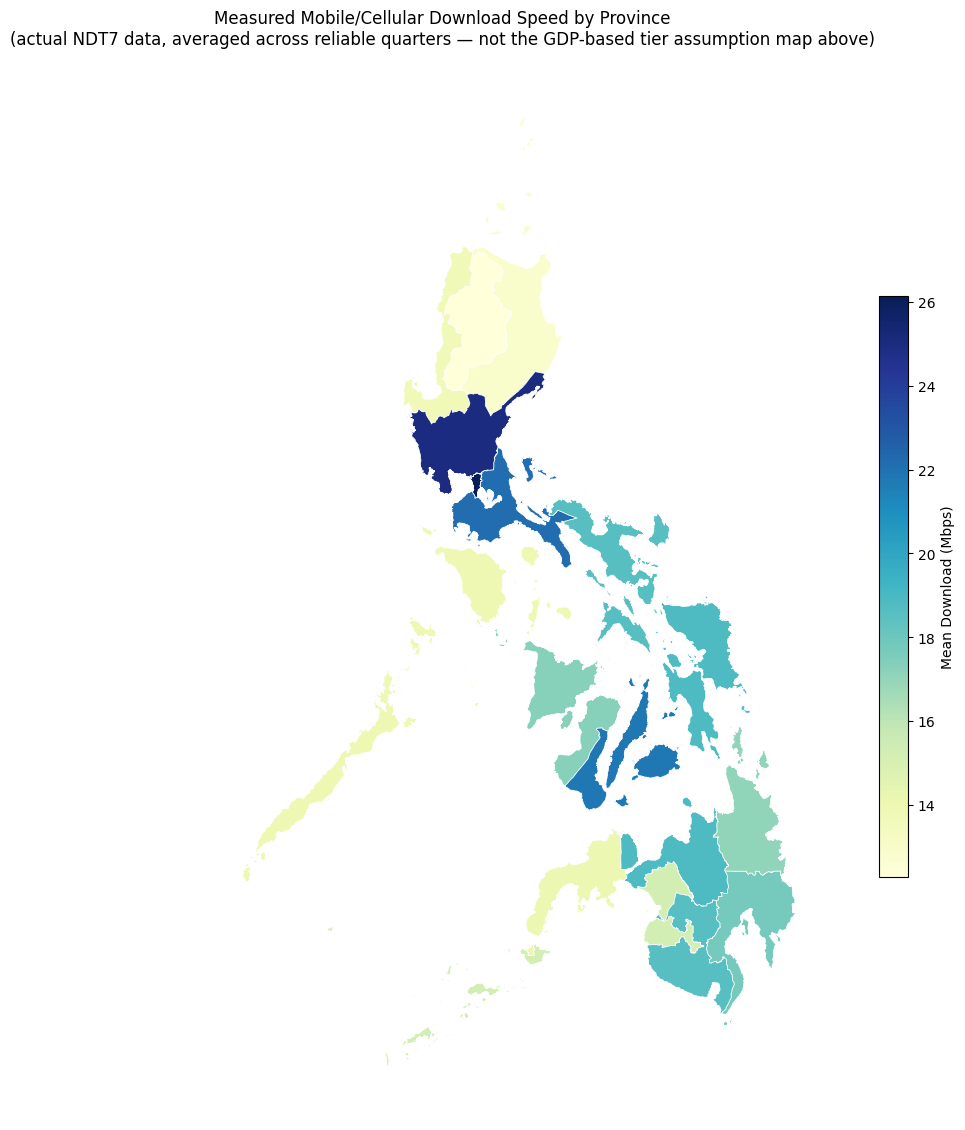

In [46]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Mobile/Cellular — skipping measured-speed choropleth.")
else:
    prov_speed = (
        master.groupby('name')
        .agg(avg_d_mbps=('avg_d_mbps', 'mean'), total_tests=('total_tests', 'sum'))
        .reset_index()
    )
    geo_speed = thailand_gdf.merge(prov_speed, on='name', how='left')

    fig, ax = plt.subplots(figsize=(10, 12))
    geo_speed.plot(
        column='avg_d_mbps', ax=ax, cmap='YlGnBu', legend=True,
        edgecolor='white', linewidth=0.5,
        legend_kwds={'shrink': 0.5, 'label': 'Mean Download (Mbps)'},
        missing_kwds={'color': 'lightgrey', 'label': 'no reliable data'},
    )
    ax.set_title('Measured Mobile/Cellular Download Speed by Province\n(actual NDT7 data, averaged across reliable quarters — not the GDP-based tier assumption map above)', fontsize=12)
    ax.set_axis_off()
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/philippines/mobile/22_speed_choropleth.png', dpi=150, bbox_inches='tight')
    plt.show()


### 16. City Focus — Capital + Top Cities by Test Volume (Mobile/Cellular)
**Skipped for Philippines** — the raw NDT7 parquet has no `city` column (unlike Cambodia/Myanmar/Laos),
so this section cannot be built the same way. The capital-vs-rest-of-country comparison is
covered in much greater depth by the PH-specific **"Manila vs Rest of PH"** section appended at
the end of this notebook (national/regional split, top-10/bottom-10 provinces, mean AND median).


In [47]:
import duckdb
# ต้องมี _con ไว้ให้หัวข้อ 17/18 (ISP ranking + market share) ใช้ต่อ
# เดิมเซลล์นี้ลบบรรทัดสร้าง connection ไปพร้อมกับโค้ด city-focus ทำให้ทั้งเล่มพังที่หัวข้อ 17
_con = duckdb.connect()

print("City Focus skipped for Philippines — no `city` column in the raw NDT7 data. "
      "See the PH-specific \'Manila vs Rest of PH\' section at the end of this notebook instead.")


City Focus skipped for Philippines — no `city` column in the raw NDT7 data. See the PH-specific 'Manila vs Rest of PH' section at the end of this notebook instead.


### 17. Per-ISP Ranking — Top ISPs by Test Volume (Mobile/Cellular)
Top 15 ISPs (min 100 tests) ranked by average download speed, bar length shows speed and
label shows test volume — adapted from the Myanmar/Laos NDT7 notebooks' per-ISP section.

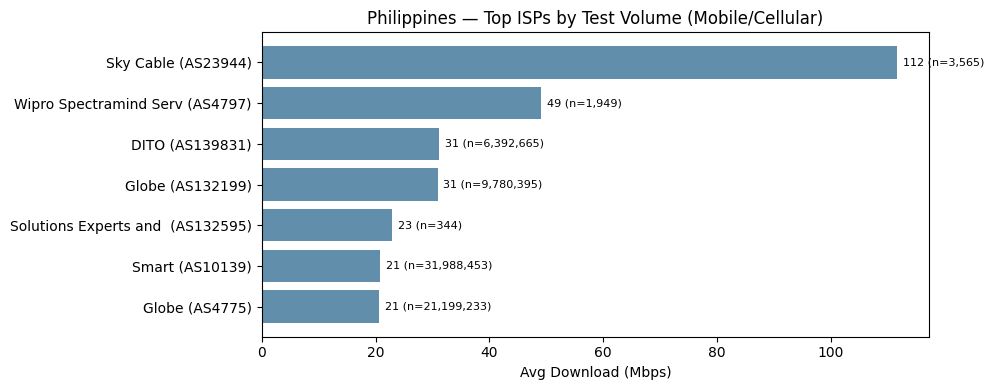

In [48]:
_isp_tbl = _con.execute(f"""
    -- จัดกลุ่มด้วย asn เท่านั้น (HANDOFF ข้อ 1): ip-api คืนชื่อองค์กรลูกค้าสำหรับ leased line
    -- เช่น AS4750 มีชื่อ isp ถึง 420 ชื่อ และชื่อเดียวกันก็กินหลาย ASN (TRUE INTERNET = 9 ASN)
    -- operator/as_name ใช้เป็นป้ายแสดงผลเท่านั้น
    WITH g AS (
        SELECT COALESCE(CAST(asn AS VARCHAR), '(unknown)') AS a,
               mode(operator) FILTER (WHERE operator IS NOT NULL) AS op,
               mode(as_name)  FILTER (WHERE as_name  IS NOT NULL) AS an,
               COUNT(*) AS n,
               AVG(mean_throughput_mbps) FILTER (WHERE type='download') AS avg_d_mbps
        FROM read_parquet('{RAW_ISP_PARQUET}')
        WHERE network_type = 'cellular'
        GROUP BY 1
    )
    -- ต่อรหัส ASN ท้ายป้าย: 1 แบรนด์มีได้หลาย ASN (ไทย True=2, AIS=3, NT=3, 3BB=2)
    -- ถ้าป้ายซ้ำ แกน categorical ของ matplotlib จะยุบแท่งทับกัน
    SELECT CASE WHEN a = '(unknown)' THEN '(unknown ASN)'
                ELSE substr(COALESCE(op, an, 'AS' || a), 1, 22) || ' (AS' || a || ')' END AS isp,
           n, avg_d_mbps
    FROM g
    WHERE n >= 100
    ORDER BY n DESC
    LIMIT 15
""").df()

if _isp_tbl.empty:
    print("No ISP meets the n>=100 test threshold for Mobile/Cellular — skipping per-ISP ranking.")
else:
    _isp_tbl = _isp_tbl.sort_values('avg_d_mbps', ascending=True)
    fig, ax = plt.subplots(figsize=(10, max(4, 0.4*len(_isp_tbl))))
    ax.barh(_isp_tbl['isp'].str.slice(0, 40), _isp_tbl['avg_d_mbps'], color='#457b9d', alpha=0.85)
    for yi, (_, row) in enumerate(_isp_tbl.iterrows()):
        ax.text(row['avg_d_mbps'] + 1, yi, f"{row['avg_d_mbps']:.0f} (n={row['n']:,})", va='center', fontsize=8)
    ax.set_xlabel('Avg Download (Mbps)')
    ax.set_title('Philippines — Top ISPs by Test Volume (Mobile/Cellular)')
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/philippines/mobile/24_per_isp.png', dpi=150, bbox_inches='tight')
    plt.show()

### 18. Market Share / HHI — ISP Concentration (Mobile/Cellular)
Top 8 ISPs + "Others" + "(unknown ISP)" by share of tests. HHI (Herfindahl-Hirschman Index):
<1500 = competitive, 1500-2500 = moderate concentration, >2500 = highly concentrated —
adapted from the Myanmar/Laos NDT7 notebooks' market-share section.

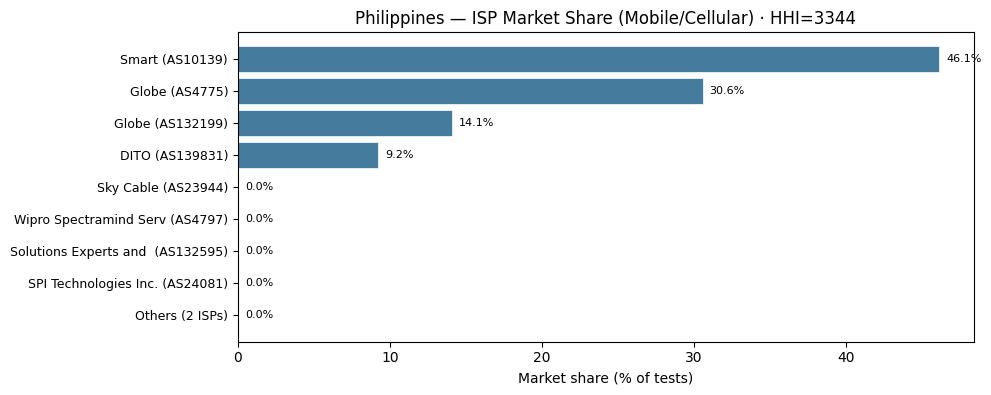

HHI=3344 (highly concentrated) | Top5 share=100.0% | unknown=0.0%


In [49]:
_mkt = _con.execute(f"""
    -- จัดกลุ่มด้วย asn เหมือน §17 (ดูเหตุผลข้างบน) — HHI อ่อนไหวกับการแตกชื่อมาก
    WITH g AS (
        SELECT COALESCE(CAST(asn AS VARCHAR), '(unknown)') AS a,
               mode(operator) FILTER (WHERE operator IS NOT NULL) AS op,
               mode(as_name)  FILTER (WHERE as_name  IS NOT NULL) AS an,
               COUNT(*) AS n
        FROM read_parquet('{RAW_ISP_PARQUET}')
        WHERE network_type = 'cellular'
        GROUP BY 1
    )
    SELECT CASE WHEN a = '(unknown)' THEN '(unknown)'
                ELSE substr(COALESCE(op, an, 'AS' || a), 1, 22) || ' (AS' || a || ')' END AS isp,
           n
    FROM g ORDER BY n DESC
""").df()

if _mkt.empty:
    print("No Mobile/Cellular data — skipping market share.")
else:
    _total = _mkt['n'].sum()
    _mkt['share'] = 100 * _mkt['n'] / _total
    _named = _mkt[_mkt['isp'] != '(unknown)'].reset_index(drop=True)
    _unknown_share = float(_mkt.loc[_mkt['isp'] == '(unknown)', 'share'].sum())
    TOPN = 8
    _top = _named.head(TOPN)
    _others_share = float(_named['share'].iloc[TOPN:].sum())
    # HHI ต้องคิดบนฐานที่มีชื่อเท่านั้น — เดิมหารด้วย _total ที่รวม (unknown) ทำให้ HHI ต่ำกว่าจริง
    _named_share = 100.0 * _named['n'] / _named['n'].sum()
    _hhi = float((_named_share ** 2).sum())

    _rows = list(zip(_top['isp'].str.slice(0, 44), _top['share']))
    if _others_share > 0:
        _rows.append((f"Others ({len(_named) - len(_top)} ISPs)", _others_share))
    if _unknown_share > 0:
        _rows.append(("(unknown ISP)", _unknown_share))
    _labels = [r[0] for r in _rows][::-1]
    _vals = [r[1] for r in _rows][::-1]
    _colors = ['#adb5bd' if l.startswith('Others') else '#ced4da' if l.startswith('(unknown') else '#457b9d' for l in _labels]

    fig, ax = plt.subplots(figsize=(10, max(4, 0.45 * len(_vals))))
    y = list(range(len(_vals)))
    ax.barh(y, _vals, color=_colors, edgecolor='white', linewidth=0.5)
    ax.set_yticks(y)
    ax.set_yticklabels(_labels, fontsize=9)
    for yi, v in zip(y, _vals):
        ax.text(v + max(_vals) * 0.01, yi, f"{v:.1f}%", va='center', fontsize=8)
    ax.set_xlabel('Market share (% of tests)')
    ax.set_title(f"Philippines — ISP Market Share (Mobile/Cellular) \u00b7 HHI={_hhi:.0f}")
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/philippines/mobile/25_market_share.png', dpi=150, bbox_inches='tight')
    plt.show()

    _hhi_note = 'competitive' if _hhi < 1500 else ('moderate' if _hhi < 2500 else 'highly concentrated')
    print(f"HHI={_hhi:.0f} ({_hhi_note}) | Top5 share={_named['share'].head(5).sum():.1f}% | unknown={_unknown_share:.1f}%")

### 19. EDA Key Findings Summary

## Key Findings from EDA

**Pending first execution** — this notebook has not been run against
`data/ndt7/ph/mlab_ph_clean.parquet` yet (not available locally in this repo). Once run, replace this
placeholder with: overall `is_reliable` rate (total_tests>=100 basis, not tile-based), which
regions clear/miss the bar, GDP-vs-speed correlation strength (if enough reliable regions),
top/bottom regions by download speed, and how the region-level picture here compares to the
richer province/island-level findings in the PH-specific sections below.


## Export for Comparison Notebook
*Saves province × quarter data to CSV.*

In [50]:
import os
os.makedirs("../../../data/exports", exist_ok=True)

EXPORT_COLS = [
    "name", "label", "year", "quarter",
    "avg_d_mbps", "avg_u_mbps", "avg_lat_ms_wt",
    "total_tests", "n_tiles", "is_reliable",
    "region", "internet_tier", "pop_2024",
    "gdp_per_capita_thb_2021", "density_per_km2",
]
existing_cols = [c for c in EXPORT_COLS if c in master.columns]
out = master[existing_cols].copy()
out = out.rename(columns={"name": "province", "label": "quarter"})

PATH = "../../../data/exports/ndt7_mobile_philippines_reliable_province_quarterly.csv"
out.to_csv(PATH, index=False)
print(f"Exported {len(out)} rows (reliable-only) -> {PATH}")
if len(out):
    print(out.head(3).to_string())
else:
    print("(0 rows — reliable-only export is empty; use the un-filtered prep-notebook output "
          "'ndt7_mobile_philippines_province_quarterly.csv' for any downstream use that needs raw coverage instead of the reliable subset.)")

Exported 151 rows (reliable-only) -> ../../../data/exports/ndt7_mobile_philippines_reliable_province_quarterly.csv
         province  quarter  year  quarter  avg_d_mbps  avg_u_mbps  avg_lat_ms_wt  total_tests  n_tiles  is_reliable region  internet_tier  pop_2024  gdp_per_capita_thb_2021  density_per_km2
0    Bicol Region  2023-Q1  2023        1   12.013373    5.647914     100.628782        14728        8         True  Luzon              4   6064426                142596.80              319
1             CAR  2023-Q1  2023        1   10.020172    4.549852     105.785467        33705        4         True  Luzon              1   1808985                295236.64               89
2  Cagayan Valley  2023-Q1  2023        1   13.579387    7.603609      98.155295          570        6         True  Luzon              3   3777608                185618.02              122
